<a href="https://colab.research.google.com/github/nazrann233/Bitcoin-and-Gold-prediction-in-MYR/blob/main/FYP_GARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This is my new FYP
### Nazran
- The version that need to use for this part of the analysis is numpy = V1.26.4 and pmdarima = V2.0.4

In [1]:
!pip uninstall numpy pmdarima -y

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [2]:
!pip install "numpy==1.26.4" "pmdarima==2.0.4"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 28.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but yo

In [1]:
# Load Packages
import pandas as pd

In [2]:
# Loading Data
bitcoin = pd.read_csv('/content/drive/MyDrive/Raw Data/Bitcoin.csv')
gold = pd.read_csv('/content/drive/MyDrive/Raw Data/XAU MYR.csv')

In [3]:

merged = pd.merge(bitcoin, gold, on='Date', how='left') ## change to 'inner' to follow XAU/MYR dates
display(merged.head())

merged['Date'] = pd.to_datetime(merged['Date'], format='%m/%d/%Y')
merged = merged.sort_values(by='Date')

merged['Bitcoin'] = pd.to_numeric(merged['Price_x'].str.replace(',', ''))
merged['Gold']    = pd.to_numeric(merged['Price_y'].str.replace(',', ''))

# Forward-fill missing 'Gold' values
merged['Gold'] = merged['Gold'].ffill()

,Date,Price_x,Open_x,High_x,Low_x,Vol._x,Change %_x,Price_y,Open_y,High_y,Low_y,Vol._y,Change %_y
0,12/31/2024,"93,557.20","92,777.20","96,163.40","92,036.20",74.85K,0.84%,"11,723.19","11,637.94","11,750.45","11,612.15",229.20K,0.85%
1,12/30/2024,"92,779.80","93,718.70","94,936.40","91,522.30",112.43K,-1.00%,"11,624.68","11,716.68","11,750.01","11,590.70",206.81K,-0.70%
2,12/29/2024,"93,716.30","95,282.60","95,315.40","93,026.70",47.71K,-1.65%,NaN,NaN,NaN,NaN,NaN,NaN
3,12/28/2024,"95,284.50","94,274.90","95,684.30","94,124.70",32.97K,1.07%,NaN,NaN,NaN,NaN,NaN,NaN
4,12/27/2024,"94,275.90","95,776.40","97,243.30","93,472.80",85.12K,-1.57%,"11,706.16","11,766.88","11,825.55","11,676.43",198.20K,-0.45%


In [4]:
display(merged[['Date', 'Bitcoin', 'Gold']].head(60))

,Date,Bitcoin,Gold
3287,2016-01-01,434.0,4548.43
3286,2016-01-02,433.7,4548.43
3285,2016-01-03,430.7,4548.43
3284,2016-01-04,433.3,4662.44
3283,2016-01-05,431.2,4674.01
3282,2016-01-06,430.8,4799.37
3281,2016-01-07,457.0,4867.63
3280,2016-01-08,452.9,4828.91
3279,2016-01-09,448.3,4828.91
3278,2016-01-10,446.2,4828.91


In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt

# Raw Data Bitcoin and Gold(XAU/MYR) plot


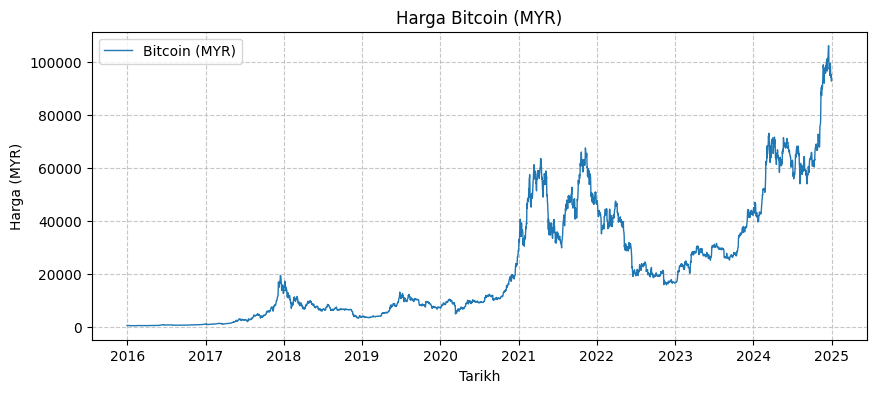

In [7]:
plt.figure(figsize=(10,4))
plt.plot(merged['Date'], merged['Bitcoin'], label='Bitcoin (MYR)', linewidth=1)
plt.title('Harga Bitcoin (MYR)')
plt.xlabel('Tarikh')
plt.ylabel('Harga (MYR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

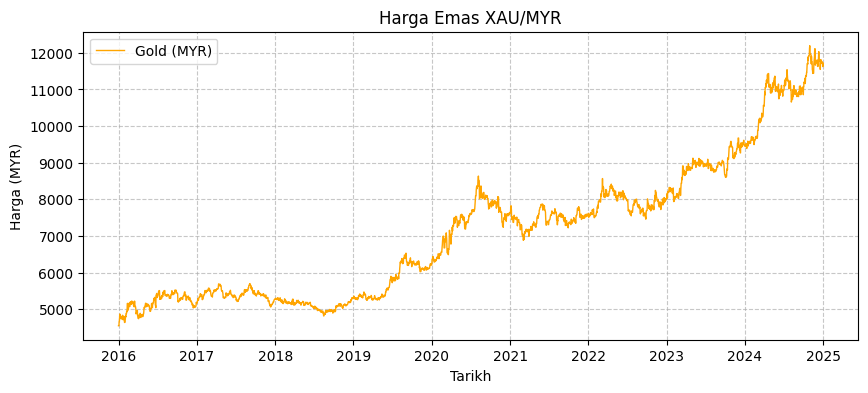

In [8]:
plt.figure(figsize=(10,4))
plt.plot(merged['Date'], merged['Gold'], label='Gold (MYR)', color='orange', linewidth=1)
plt.title('Harga Emas XAU/MYR')
plt.xlabel('Tarikh')
plt.ylabel('Harga (MYR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Raw Bitcoin and Gold ADF

In [9]:
from statsmodels.tsa.stattools import adfuller

In [10]:
# ADF ON RAW DATA
# ========================
from statsmodels.tsa.stattools import adfuller

def adf_print(series, name):
    res = adfuller(series.dropna())
    print(f"\n--- ADF Test: {name} ---")
    print(f"ADF Statistic: {res[0]:.6f}")
    print(f"p-value     : {res[1]:.6f}")
    for k, v in res[4].items():
        print(f"Critical Value ({k}): {v:.4f}")
    print("→ Stationary ✅" if res[1] < 0.05 else "→ Non-stationary ❌")

adf_print(merged['Bitcoin'], 'Raw Bitcoin')
adf_print(merged['Gold'],    'Raw Gold')


--- ADF Test: Raw Bitcoin ---
ADF Statistic: -0.104248
p-value     : 0.949014
Critical Value (1%): -3.4324
Critical Value (5%): -2.8624
Critical Value (10%): -2.5672
→ Non-stationary ❌

--- ADF Test: Raw Gold ---
ADF Statistic: 0.725288
p-value     : 0.990329
Critical Value (1%): -3.4323
Critical Value (5%): -2.8624
Critical Value (10%): -2.5672
→ Non-stationary ❌


# Log Return

In [11]:
# Calculate log returns (natural log difference between consecutive prices)
merged['Bitcoin_logret'] = np.log(merged['Bitcoin'] / merged['Bitcoin'].shift(1))
merged['Gold_logret']    = np.log(merged['Gold'] / merged['Gold'].shift(1))

# Drop any missing values caused by the shift
merged = merged.dropna(subset=['Bitcoin_logret', 'Gold_logret'])

# Display first few rows to check
display(merged[['Date', 'Bitcoin_logret', 'Gold_logret']].head(50))

,Date,Bitcoin_logret,Gold_logret
3286,2016-01-02,-0.000691,0.000000
3285,2016-01-03,-0.006941,0.000000
3284,2016-01-04,0.006019,0.024757
3283,2016-01-05,-0.004858,0.002478
3282,2016-01-06,-0.000928,0.026467
3281,2016-01-07,0.059039,0.014123
3280,2016-01-08,-0.009012,-0.007986
3279,2016-01-09,-0.010209,0.000000
3278,2016-01-10,-0.004695,0.000000
3277,2016-01-11,0.003356,-0.007723


In [12]:
# ADF ON LOG RETURNS
# ========================
from statsmodels.tsa.stattools import adfuller

def adf_print(series, name):
    res = adfuller(series.dropna())
    print(f"\n--- ADF Test: {name} ---")
    print(f"ADF Statistic: {res[0]:.6f}")
    print(f"p-value     : {res[1]:.6f}")
    for k, v in res[4].items():
        print(f"Critical Value ({k}): {v:.4f}")
    print("→ Stationary ✅" if res[1] < 0.05 else "→ Non-stationary ❌")

adf_print(merged['Bitcoin_logret'], 'Bitcoin Log Return')
adf_print(merged['Gold_logret'],    'Gold Log Return')


--- ADF Test: Bitcoin Log Return ---
ADF Statistic: -39.836431
p-value     : 0.000000
Critical Value (1%): -3.4323
Critical Value (5%): -2.8624
Critical Value (10%): -2.5672
→ Stationary ✅

--- ADF Test: Gold Log Return ---
ADF Statistic: -43.300169
p-value     : 0.000000
Critical Value (1%): -3.4323
Critical Value (5%): -2.8624
Critical Value (10%): -2.5672
→ Stationary ✅


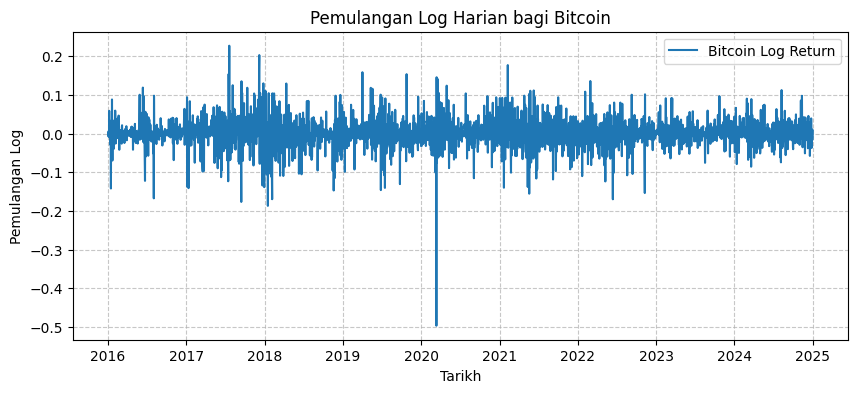

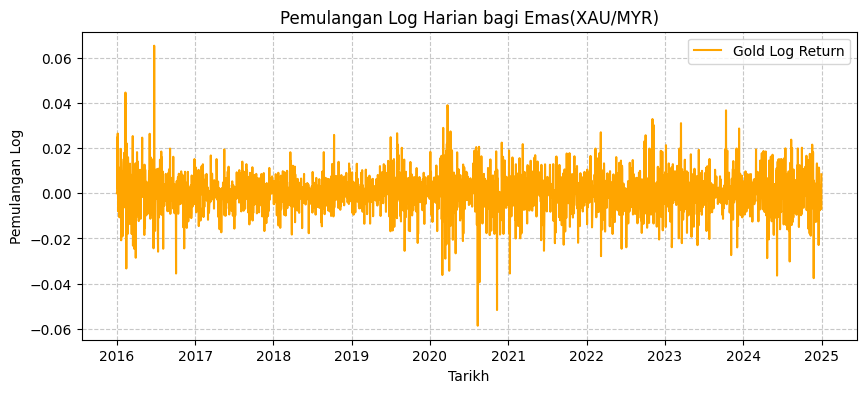

In [13]:
#Plot the log returns ---
plt.figure(figsize=(10,4))
plt.plot(merged['Date'], merged['Bitcoin_logret'], label='Bitcoin Log Return')
plt.title('Pemulangan Log Harian bagi Bitcoin')
plt.xlabel('Tarikh')
plt.ylabel('Pemulangan Log')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(merged['Date'], merged['Gold_logret'], label='Gold Log Return', color='orange')
plt.title('Pemulangan Log Harian bagi Emas(XAU/MYR)')
plt.xlabel('Tarikh')
plt.ylabel('Pemulangan Log')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

#  ACF and PACF of Log Returns( measures "How much did the price change?") (Direction and amount)


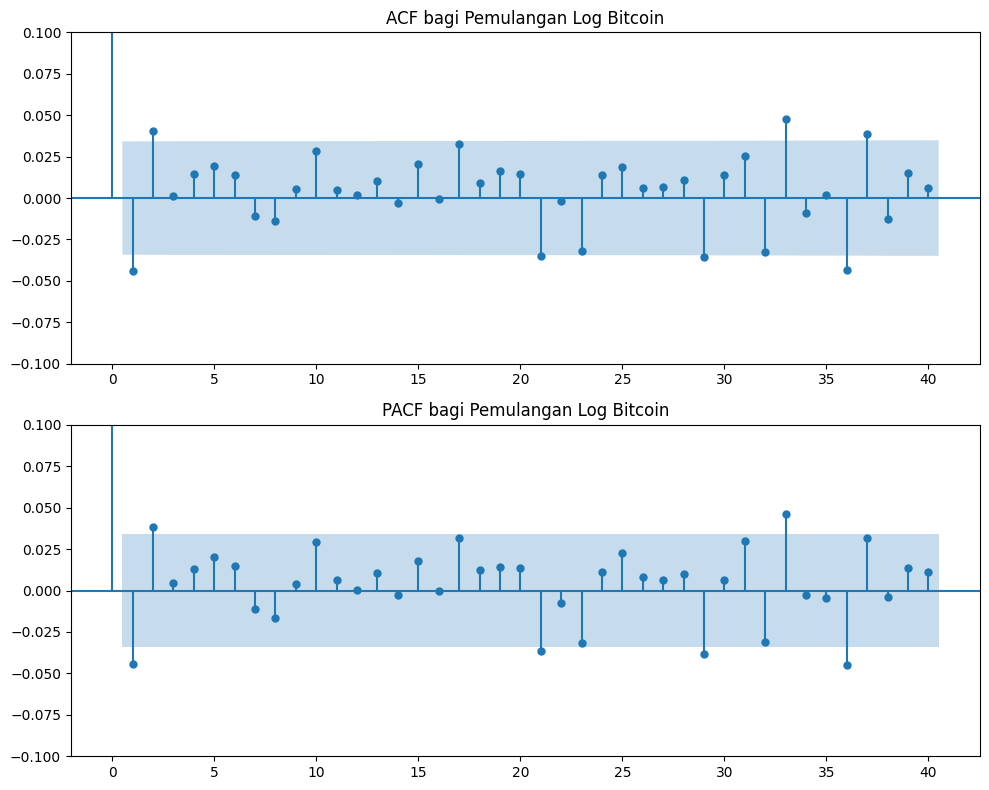

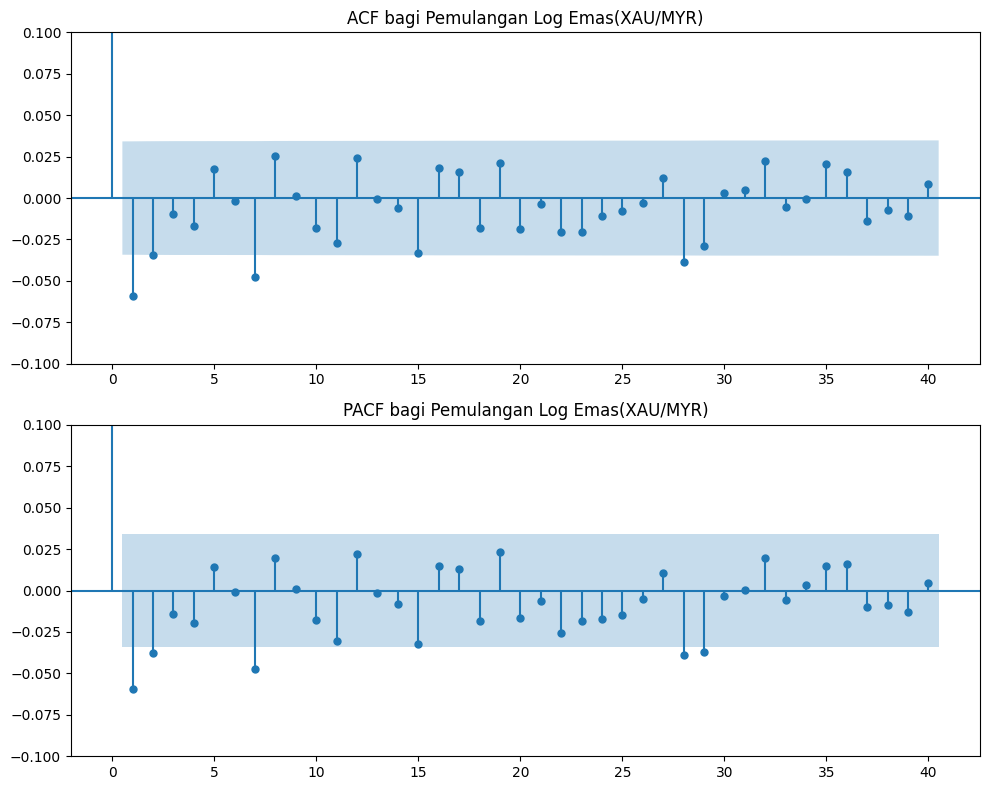

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for Bitcoin Log Returns
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(merged['Bitcoin_logret'].dropna(), ax=axes[0], lags=40)
plot_pacf(merged['Bitcoin_logret'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF bagi Pemulangan Log Bitcoin')
axes[1].set_title('PACF bagi Pemulangan Log Bitcoin')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for Gold Log Returns
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(merged['Gold_logret'].dropna(), ax=axes[0], lags=40)
plot_pacf(merged['Gold_logret'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF bagi Pemulangan Log Emas(XAU/MYR)')
axes[1].set_title('PACF bagi Pemulangan Log Emas(XAU/MYR)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# ACF and PACF Squared Log Returns (This measures "How volatile was the market?") (Magnitude/Risk only, ignoring direction).


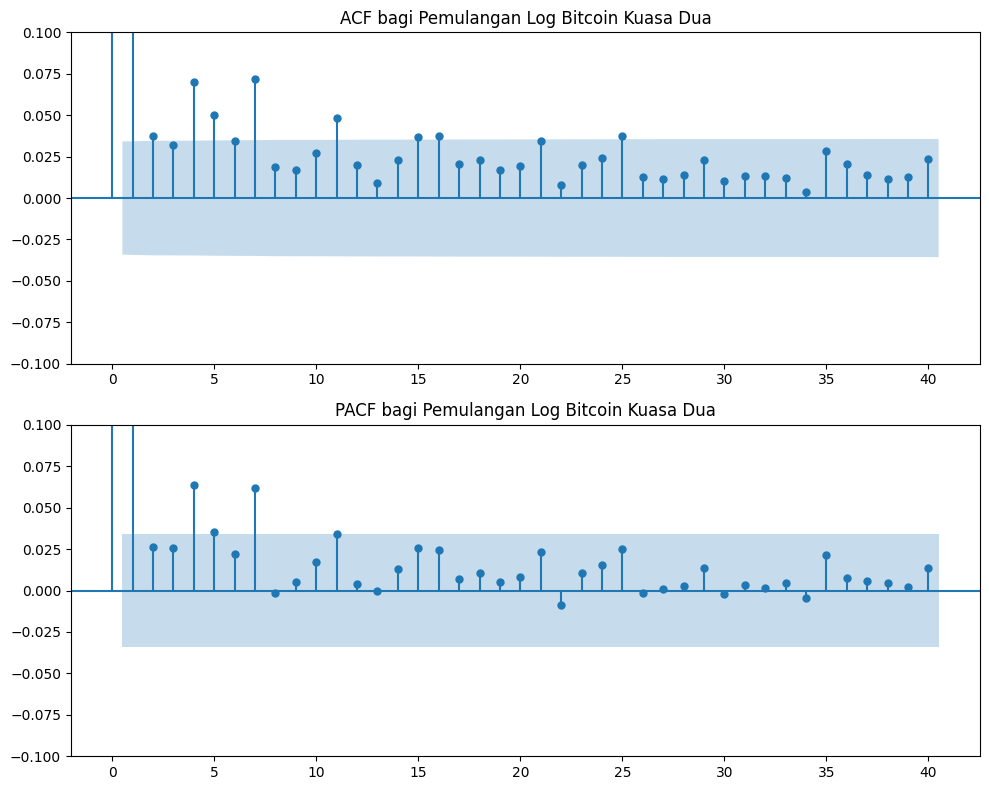

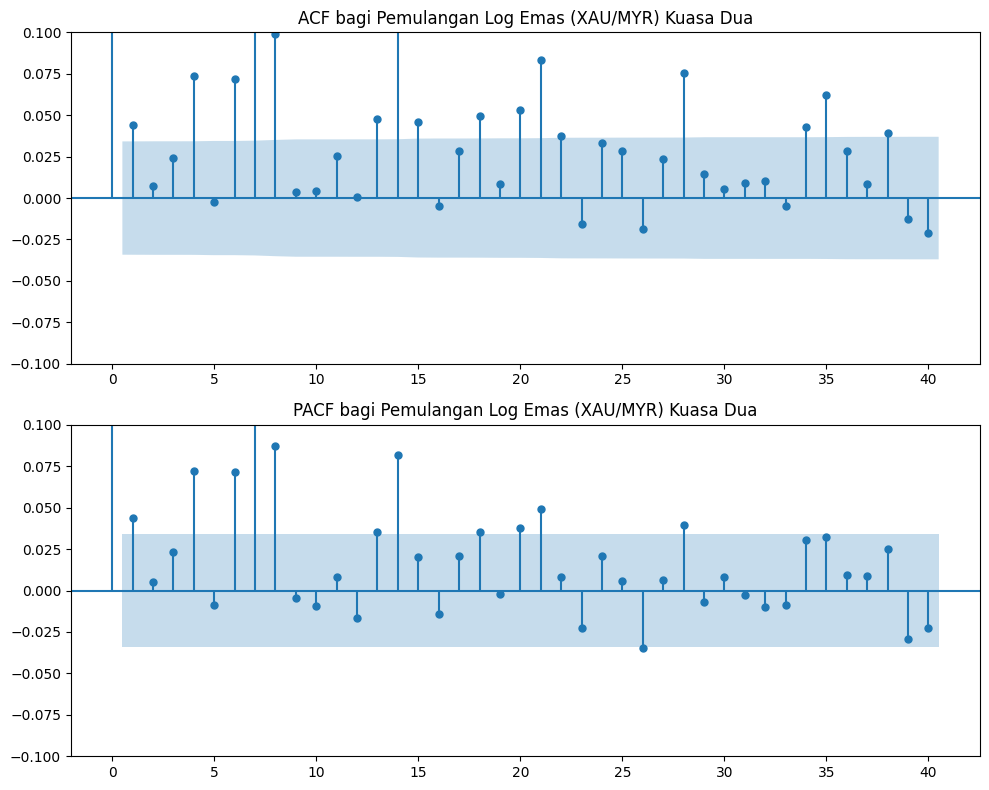

In [15]:
# Calculate squared log returns
merged['Bitcoin_logret_sq'] = merged['Bitcoin_logret']**2
merged['Gold_logret_sq'] = merged['Gold_logret']**2

# Plot ACF and PACF for squared Bitcoin Log Returns
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(merged['Bitcoin_logret_sq'].dropna(), ax=axes[0], lags=40)
plot_pacf(merged['Bitcoin_logret_sq'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF bagi Pemulangan Log Bitcoin Kuasa Dua')
axes[1].set_title('PACF bagi Pemulangan Log Bitcoin Kuasa Dua')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for squared Gold Log Returns
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(merged['Gold_logret_sq'].dropna(), ax=axes[0], lags=40)
plot_pacf(merged['Gold_logret_sq'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF bagi Pemulangan Log Emas (XAU/MYR) Kuasa Dua')
axes[1].set_title('PACF bagi Pemulangan Log Emas (XAU/MYR) Kuasa Dua')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Descriptive Statistic

In [16]:
# Calculate and display descriptive statistics for log returns
print("Descriptive statistics for Bitcoin Log Returns:")
display(merged['Bitcoin_logret'].describe())

print("\nDescriptive statistics for Gold Log Returns:")
display(merged['Gold_logret'].describe())

print("\nSkewness for Bitcoin Log Returns:", merged['Bitcoin_logret'].skew())
print("Kurtosis for Bitcoin Log Returns:", merged['Bitcoin_logret'].kurtosis())

print("\nSkewness for Gold Log Returns:", merged['Gold_logret'].skew())
print("Kurtosis for Gold Log Returns:", merged['Gold_logret'].kurtosis())

Descriptive statistics for Bitcoin Log Returns:


,Bitcoin_logret
count,3287.000000
mean,0.001635
std,0.036918
min,-0.497278
25%,-0.012508
50%,0.001402
75%,0.017001
max,0.227602



Descriptive statistics for Gold Log Returns:


,Gold_logret
count,3287.000000
mean,0.000288
std,0.007686
min,-0.058673
25%,-0.002181
50%,0.000000
75%,0.003132
max,0.065374



Skewness for Bitcoin Log Returns: -0.8086325137374343
Kurtosis for Bitcoin Log Returns: 13.502757094871246

Skewness for Gold Log Returns: -0.14235743872692705
Kurtosis for Gold Log Returns: 6.47255826693234


### Granger

In [ ]:
from statsmodels.tsa.api import VAR

#need to know how many lag is appropriate for Granger
data = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].dropna()

model = VAR(data[['Bitcoin_logret', 'Gold_logret']])
lag_order = model.select_order(maxlags=10)
print(lag_order.summary())

# Print the optimal lag based on AIC
optimal_lag_aic = lag_order.aic
print(f"\nOptimal Lag (AIC): {optimal_lag_aic}")

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -16.35     -16.34*   7.965e-08      -16.34
1       -16.35      -16.34   7.935e-08     -16.35*
2      -16.35*      -16.33  7.929e-08*      -16.34
3       -16.35      -16.32   7.945e-08      -16.34
4       -16.35      -16.31   7.954e-08      -16.34
5       -16.35      -16.31   7.961e-08      -16.33
6       -16.34      -16.30   7.970e-08      -16.33
7       -16.35      -16.29   7.966e-08      -16.33
8       -16.34      -16.28   7.980e-08      -16.32
9       -16.34      -16.27   7.994e-08      -16.32
10      -16.34      -16.26   7.996e-08      -16.31
--------------------------------------------------

Optimal Lag (AIC): 2


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

print("Granger Causality Test: Does Gold log return Granger cause Bitcoin log return?")
granger_test_y_to_x = grangercausalitytests(data[['Bitcoin_logret', 'Gold_logret']], maxlag=2, verbose=True)
print('\n')


print("Granger Causality Test: Does Bitcoin log return Granger cause Gold log return?")
granger_test_x_to_y = grangercausalitytests(data[['Bitcoin_logret', 'Gold_logret']], maxlag=2, verbose=True)

Granger Causality Test: Does Gold log return Granger cause Bitcoin log return?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.5674  , p=0.4513  , df_denom=3283, df_num=1
ssr based chi2 test:   chi2=0.5679  , p=0.4511  , df=1
likelihood ratio test: chi2=0.5679  , p=0.4511  , df=1
parameter F test:         F=0.5674  , p=0.4513  , df_denom=3283, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.4393  , p=0.6445  , df_denom=3280, df_num=2
ssr based chi2 test:   chi2=0.8800  , p=0.6440  , df=2
likelihood ratio test: chi2=0.8799  , p=0.6441  , df=2
parameter F test:         F=0.4393  , p=0.6445  , df_denom=3280, df_num=2


Granger Causality Test: Does Bitcoin log return Granger cause Gold log return?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.5674  , p=0.4513  , df_denom=3283, df_num=1
ssr based chi2 test:   chi2=0.5679  , p=0.4511  , df=1
likelihood ratio test: chi2=0.5679  , p=0.4511  , df=1
pa

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


# Split 70:30


In [17]:
# Split data into training and testing sets (70:30 ratio) using log return data
train_size = int(len(merged) * 0.7)
train_data = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[0:train_size]
test_data = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[train_size:len(merged)]

print("Training data size:", len(train_data))
print("Testing data size:", len(test_data))

Training data size: 2300
Testing data size: 987


In [18]:
from pmdarima import auto_arima

# ARIMA before Scalling


In [19]:
import warnings
warnings.filterwarnings("ignore")

In [20]:
# Fit auto_arima model on Bitcoin log returns
model_bitcoin = auto_arima(train_data['Bitcoin_logret'], seasonal=False, suppress_warnings=True)
print("Bitcoin Auto ARIMA Model Summary:")
print(model_bitcoin.summary())

# Fit auto_arima model on Gold log returns
model_gold = auto_arima(train_data['Gold_logret'], seasonal=False, suppress_warnings=True)
print("\nGold Auto ARIMA Model Summary:")
print(model_gold.summary())

Bitcoin Auto ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2300
Model:               SARIMAX(2, 0, 2)   Log Likelihood                4133.396
Date:                Sun, 30 Nov 2025   AIC                          -8256.791
Time:                        14:33:13   BIC                          -8228.088
Sample:                             0   HQIC                         -8246.326
                               - 2300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4019      0.202      1.987      0.047       0.006       0.798
ar.L2          0.5046      0.207      2.439      0.015       0.099       0.910
ma.L1         -0.4

# Manual ARIMA


In [21]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# ==========================================
#    CONFIGURATION: AUTO GRID SEARCH
# ==========================================

# Define the maximum order you want to test (e.g., 5 means p=0..5, q=0..5)
max_p = 5
max_q = 5
d_value = 0  # Fixed at 0 for Log Returns

# --- AUTOMATICALLY GENERATE CANDIDATE LIST ---
# This list comprehension replaces typing them out manually.
# It creates [(0,0,0), (0,0,1) ... up to (5,0,5)] -> 36 models
grid_search_candidates = [
    (p, d_value, q)
    for p in range(0, max_p + 1)
    for q in range(0, max_q + 1)
]

print(f"Generated {len(grid_search_candidates)} models for grid search.")

# --- MAINTAINING YOUR ORIGINAL VARIABLES ---
# We assign the auto-generated list to your original variable names
bitcoin_candidates = grid_search_candidates
gold_candidates = grid_search_candidates


# --- 2. FUNCTION TO RUN THE LIST ---
def run_model_list(data, model_list, asset_name):
    results = []
    print(f"Running models for {asset_name}...")

    for param in model_list:
        try:
            # Fit ARIMA model (trend='c' adds an intercept)
            model = ARIMA(data, order=param, trend='c')
            model_fit = model.fit()

            # Save results
            results.append({
                'Model': f"ARIMA{param}",
                'AIC': round(model_fit.aic, 2),
                'BIC': round(model_fit.bic, 2)
            })
        except:
            continue

    # Create DataFrame and Sort by AIC
    df = pd.DataFrame(results)
    df = df.sort_values(by='AIC', ascending=True)
    return df


# --- 3. EXECUTE FOR BOTH ASSETS (SCALED DATA) ---

# Run Bitcoin List using 'train_data' and 'bitcoin_candidates'
# Note: We multiply by 100 for scaling
df_bitcoin = run_model_list(train_data['Bitcoin_logret'] * 100, bitcoin_candidates, "Bitcoin")

# Run Gold List using 'train_data' and 'gold_candidates'
df_gold = run_model_list(train_data['Gold_logret'] * 100, gold_candidates, "Gold")


# --- 4. PRINT THE FINAL TABLES ---
print("\n" + "="*40)
print("   BITCOIN MODEL SELECTION RESULTS")
print("="*40)
print(df_bitcoin)

print("\n" + "="*40)
print("    GOLD MODEL SELECTION RESULTS")
print("="*40)
print(df_gold)

Generated 36 models for grid search.
Running models for Bitcoin...
Running models for Gold...

   BITCOIN MODEL SELECTION RESULTS
             Model       AIC       BIC
12  ARIMA(2, 0, 0)  12922.99  12945.95
2   ARIMA(0, 0, 2)  12923.04  12946.01
7   ARIMA(1, 0, 1)  12923.38  12946.35
6   ARIMA(1, 0, 0)  12923.39  12940.61
1   ARIMA(0, 0, 1)  12923.73  12940.95
14  ARIMA(2, 0, 2)  12924.57  12959.01
16  ARIMA(2, 0, 4)  12924.76  12970.69
9   ARIMA(1, 0, 3)  12924.80  12959.24
33  ARIMA(5, 0, 3)  12924.91  12982.32
13  ARIMA(2, 0, 1)  12924.95  12953.66
18  ARIMA(3, 0, 0)  12924.97  12953.67
3   ARIMA(0, 0, 3)  12925.04  12953.75
8   ARIMA(1, 0, 2)  12925.04  12953.75
21  ARIMA(3, 0, 3)  12926.21  12972.14
20  ARIMA(3, 0, 2)  12926.29  12966.48
15  ARIMA(2, 0, 3)  12926.34  12966.53
4   ARIMA(0, 0, 4)  12926.51  12960.95
24  ARIMA(4, 0, 0)  12926.53  12960.98
25  ARIMA(4, 0, 1)  12926.60  12966.78
10  ARIMA(1, 0, 4)  12926.62  12966.80
23  ARIMA(3, 0, 5)  12926.67  12984.08
0   ARIMA(0,

# Scaled ARIMA


In [22]:
from statsmodels.tsa.arima.model import ARIMA
# Fit auto_arima model on Bitcoin log returns
model_bitcoin = ARIMA(train_data['Bitcoin_logret']*100, order=(2, 0, 0), trend='c').fit()
print("Bitcoin ARIMA(2, 0, 0) Model Summary:")
print(model_bitcoin.summary())

# Fit auto_arima model on Gold log returns
model_gold = auto_arima(train_data['Gold_logret']*100, seasonal=False, suppress_warnings=True)
print("\nGold Auto ARIMA Model Summary:")
print(model_gold.summary())

Bitcoin ARIMA(2, 0, 0) Model Summary:
                               SARIMAX Results                                
Dep. Variable:         Bitcoin_logret   No. Observations:                 2300
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -6457.495
Date:                Sun, 30 Nov 2025   AIC                          12922.991
Time:                        14:42:28   BIC                          12945.953
Sample:                             0   HQIC                         12931.362
                               - 2300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1983      0.085      2.326      0.020       0.031       0.365
ar.L1         -0.0468      0.014     -3.279      0.001      -0.075      -0.019
ar.L2         

# ARCH Then Garch

In [23]:
%pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 23.2 MB/s eta 0:00:00


# GARCH (with normal distribution)


In [25]:
from arch import arch_model

In [27]:
# 1. Get residuals from your auto_arima models (which are already fitted)
btc_residuals = model_bitcoin.resid
gold_residuals = model_gold.resid()

# 2.
btc_resid_scaled = btc_residuals
gold_resid_scaled = gold_residuals

# 3. Fit GARCH(1,1) on the SCALED RESIDUALS
# We use mean='Zero' because the residuals should already have a mean of zero.
garch_btc = arch_model(btc_resid_scaled,
                       mean='Zero',
                       vol='Garch', p=1, q=1,
                       dist='Normal')

res_garch_btc = garch_btc.fit(disp='off')
print("Bitcoin GARCH(1,1) on ARMA(2,2) Residuals:")
print(res_garch_btc.summary())

# 4. Fit GARCH(1,1) on the SCALED RESIDUALS for Gold
garch_gold = arch_model(gold_resid_scaled,
                        mean='Zero',
                        vol='Garch', p=1, q=1,
                        dist='Normal')

res_garch_gold = garch_gold.fit(disp='off')
print("\nGold GARCH(1,1) on MA(1) Residuals:")
print(res_garch_gold.summary())



Bitcoin GARCH(1,1) on ARMA(2,2) Residuals:
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6296.42
Distribution:                  Normal   AIC:                           12598.8
Method:            Maximum Likelihood   BIC:                           12616.1
                                        No. Observations:                 2300
Date:                Sun, Nov 30 2025   Df Residuals:                     2300
Time:                        15:04:17   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.7332

# GARCH with t distribution


In [28]:
from arch import arch_model
import pandas as pd

# 1. Get residuals from your auto_arima models (which are already fitted)
btc_residuals = model_bitcoin.resid
gold_residuals = model_gold.resid()

# 2. Rescale the residuals to fix the DataScaleWarning
btc_resid_scaled = btc_residuals
gold_resid_scaled = gold_residuals

# 3. Fit GARCH(1,1) on the SCALED RESIDUALS
garch_btc = arch_model(btc_resid_scaled,
                       mean='Zero',
                       vol='Garch', p=1, q=1,
                       dist='t')

res_garch_btc = garch_btc.fit(disp='off')
print("Bitcoin GARCH(1,1) on ARMA(2,2) Residuals (t-distribution):")
print(res_garch_btc.summary())

# 4. Fit GARCH(1,1) on the SCALED RESIDUALS for Gold
garch_gold = arch_model(gold_resid_scaled,
                        mean='Zero',
                        vol='Garch', p=1, q=1,
                        dist='t')

res_garch_gold = garch_gold.fit(disp='off')
print("\nGold GARCH(1,1) on MA(1) Residuals (t-distribution):")
print(res_garch_gold.summary())

# 5. Fit EGARCH(1,1) on the SCALED RESIDUALS for Gold
egarch11_gold = arch_model(gold_resid_scaled,
                         mean='Zero',
                         vol='EGARCH', p=1, q=1,
                         dist='t')

res11_egarch_gold = egarch11_gold.fit(disp='off')
print("\nGold EGARCH(1,1) on MA(1) Residuals (t-distribution):")
print(res11_egarch_gold.summary())



# 5. Fit EGARCH(2,2) on the SCALED RESIDUALS for Gold
egarch22_gold = arch_model(gold_resid_scaled,
                         mean='Zero',
                         vol='EGARCH', p=2, q=2,
                         dist='t')

res_egarch22_gold = egarch22_gold.fit(disp='off')
print("\nGold EGARCH(2,2) on MA(1) Residuals (t-distribution):")
print(res_egarch22_gold.summary())

Bitcoin GARCH(1,1) on ARMA(2,2) Residuals (t-distribution):
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5965.54
Distribution:      Standardized Student's t   AIC:                           11939.1
Method:                  Maximum Likelihood   BIC:                           11962.1
                                              No. Observations:                 2300
Date:                      Sun, Nov 30 2025   Df Residuals:                     2300
Time:                              15:04:20   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
-----------------------

In [37]:
# @title
from statsmodels.stats.stattools import jarque_bera

# Perform Jarque-Bera test on standardized Bitcoin residuals
jb_btc = jarque_bera(btc_std_resid.dropna())

print("--- Jarque-Bera Test: Standardized Bitcoin Residuals ---")
print(f"JB Statistic: {jb_btc[0]:.6f}")
print(f"p-value     : {jb_btc[1]:.6f}")
print(f"Skewness    : {jb_btc[2]:.6f}")
print(f"Kurtosis    : {jb_btc[3]:.6f}")
print("→ Normal Distribution ✅" if jb_btc[1] > 0.05 else "→ Non-normal Distribution ❌")


# Perform Jarque-Bera test on standardized Gold residuals
jb_gold = jarque_bera(gold_std_resid.dropna())

print("\n--- Jarque-Bera Test: Standardized Gold Residuals ---")
print(f"JB Statistic: {jb_gold[0]:.6f}")
print(f"p-value     : {jb_gold[1]:.6f}")
print(f"Skewness    : {jb_gold[2]:.6f}")
print(f"Kurtosis    : {jb_gold[3]:.6f}")
print("→ Normal Distribution ✅" if jb_gold[1] > 0.05 else "→ Non-normal Distribution ❌")

--- Jarque-Bera Test: Standardized Bitcoin Residuals ---
JB Statistic: 28136.300999
p-value     : 0.000000
Skewness    : -0.779434
Kurtosis    : 20.063590
→ Non-normal Distribution ❌

--- Jarque-Bera Test: Standardized Gold Residuals ---
JB Statistic: 3842.191467
p-value     : 0.000000
Skewness    : -0.294237
Kurtosis    : 9.304453
→ Non-normal Distribution ❌


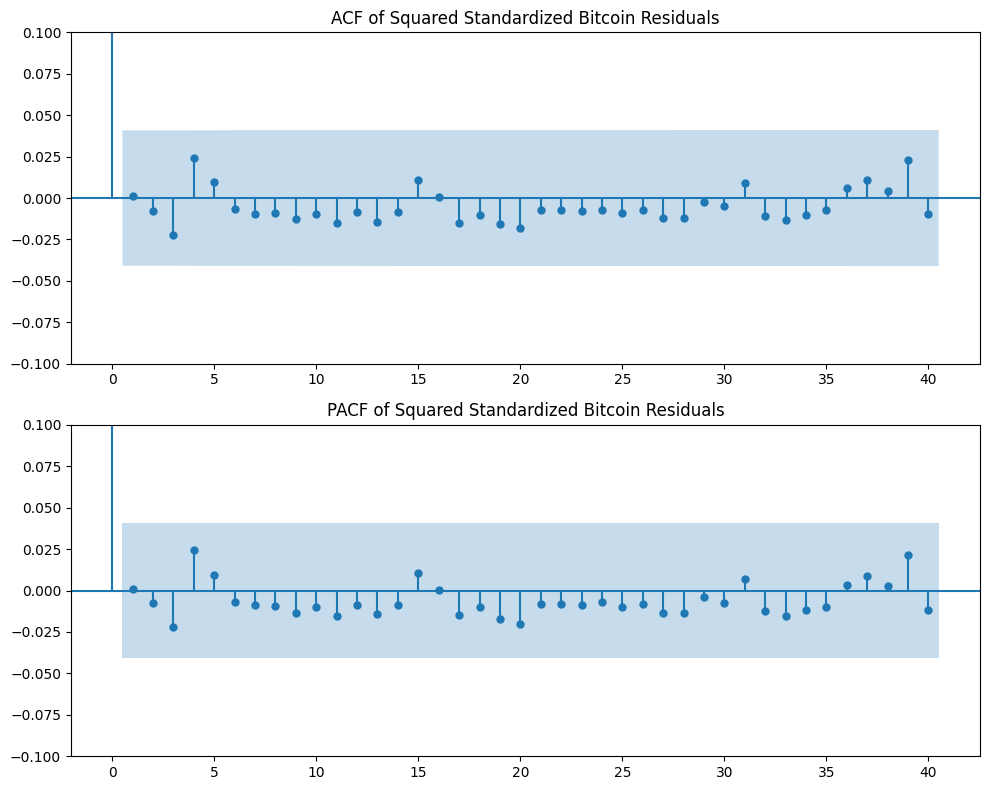

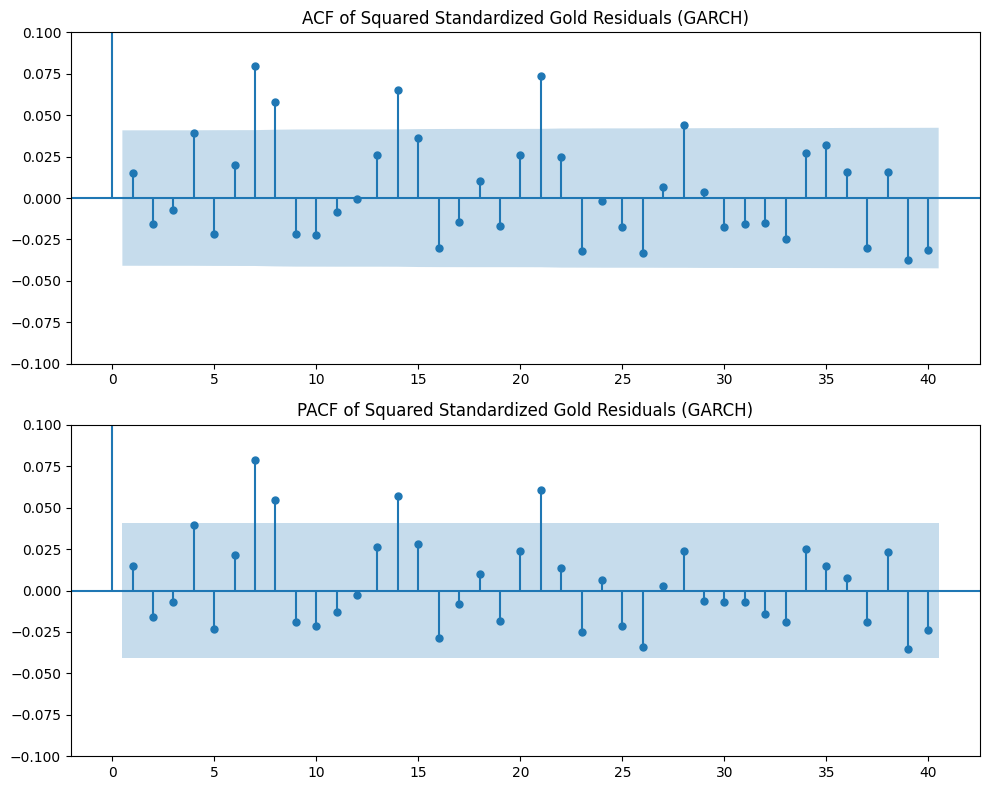

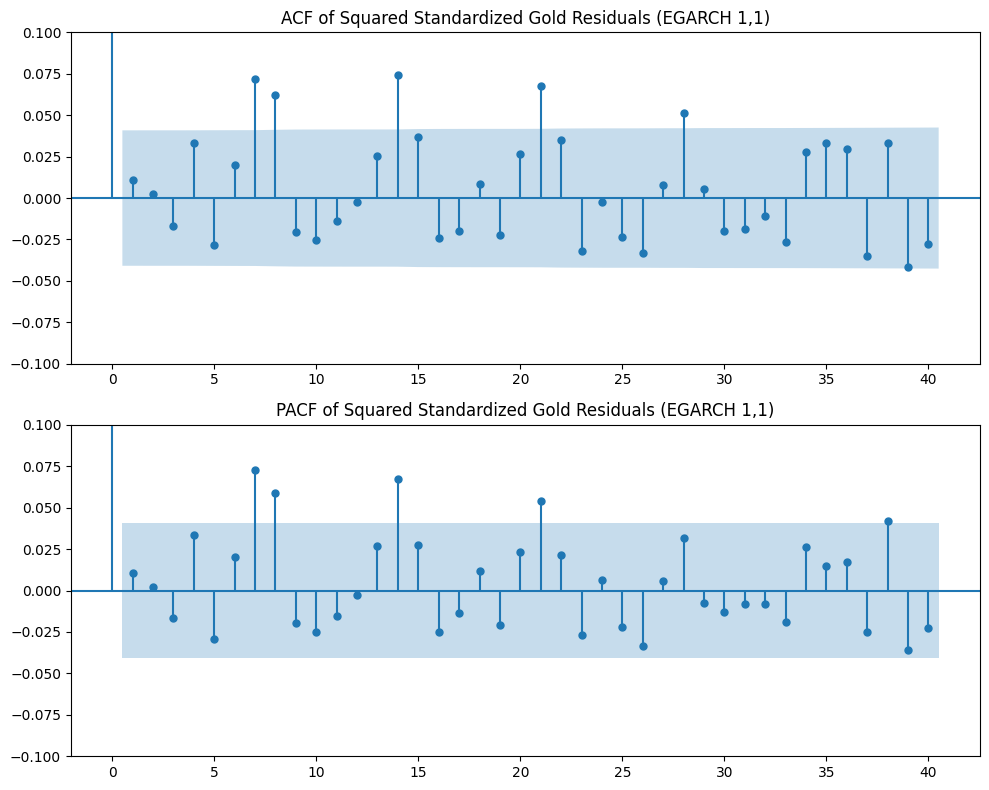

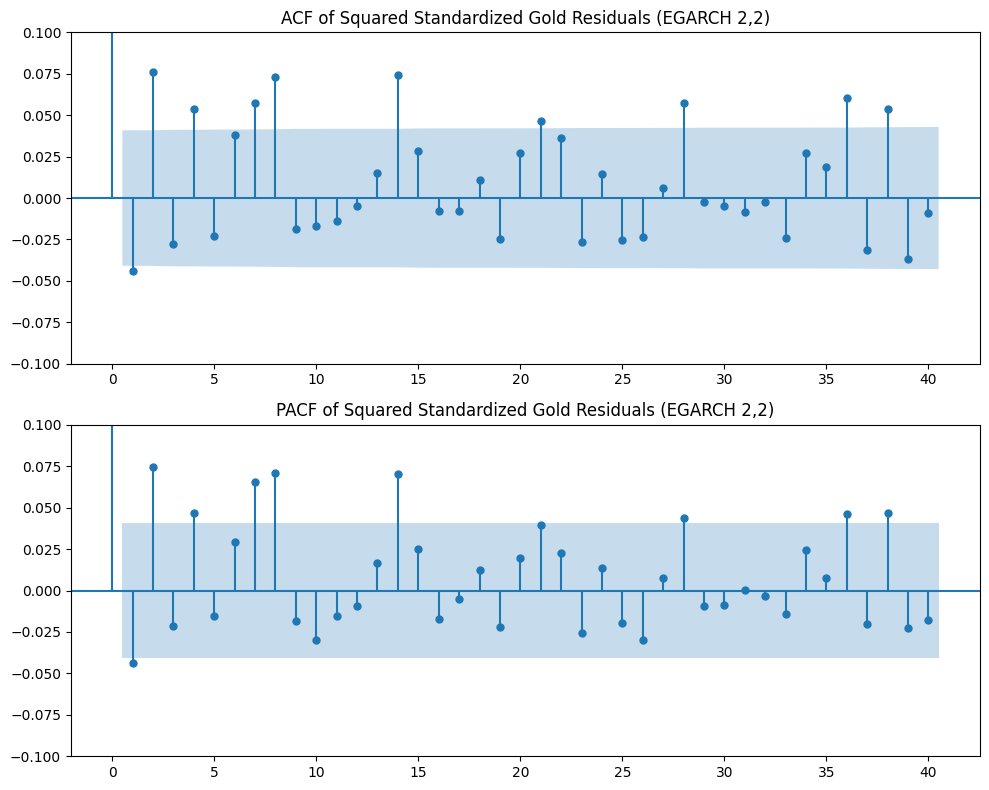

In [31]:
# Get the standardized residuals
btc_std_resid = res_garch_btc.std_resid
gold_std_resid = res_garch_gold.std_resid

# Square the standardized residuals
btc_std_resid_sq = btc_std_resid**2
gold_std_resid_sq = gold_std_resid**2

# Plot ACF and PACF for squared standardized Bitcoin residuals
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(btc_std_resid_sq.dropna(), ax=axes[0], lags=40)
plot_pacf(btc_std_resid_sq.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Bitcoin Residuals')
axes[1].set_title('PACF of Squared Standardized Bitcoin Residuals')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for squared standardized Gold residuals (GARCH)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (GARCH)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (GARCH)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Get standardized residuals for EGARCH
gold_std_resid_egarch11 = res11_egarch_gold.std_resid


# Square the standardized residuals for EGARCH
gold_std_resid_sq_egarch11 = gold_std_resid_egarch11**2


# Plot ACF and PACF for squared standardized Gold residuals (EGARCH)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq_egarch11.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq_egarch11.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (EGARCH 1,1)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (EGARCH 1,1)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Get standardized residuals for EGARCH(2,2)
gold_std_resid_egarch22 = res_egarch22_gold.std_resid

# Square the standardized residuals
gold_std_resid_sq_egarch22 = gold_std_resid_egarch22**2

# Plot ACF and PACF for squared standardized Gold residuals (EGARCH 2,2)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(gold_std_resid_sq_egarch22.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq_egarch22.dropna(), ax=axes[1], lags=40)

axes[0].set_title('ACF of Squared Standardized Gold Residuals (EGARCH 2,2)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (EGARCH 2,2)')

# Same y-limits as your other plots
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])

plt.tight_layout()
plt.show()

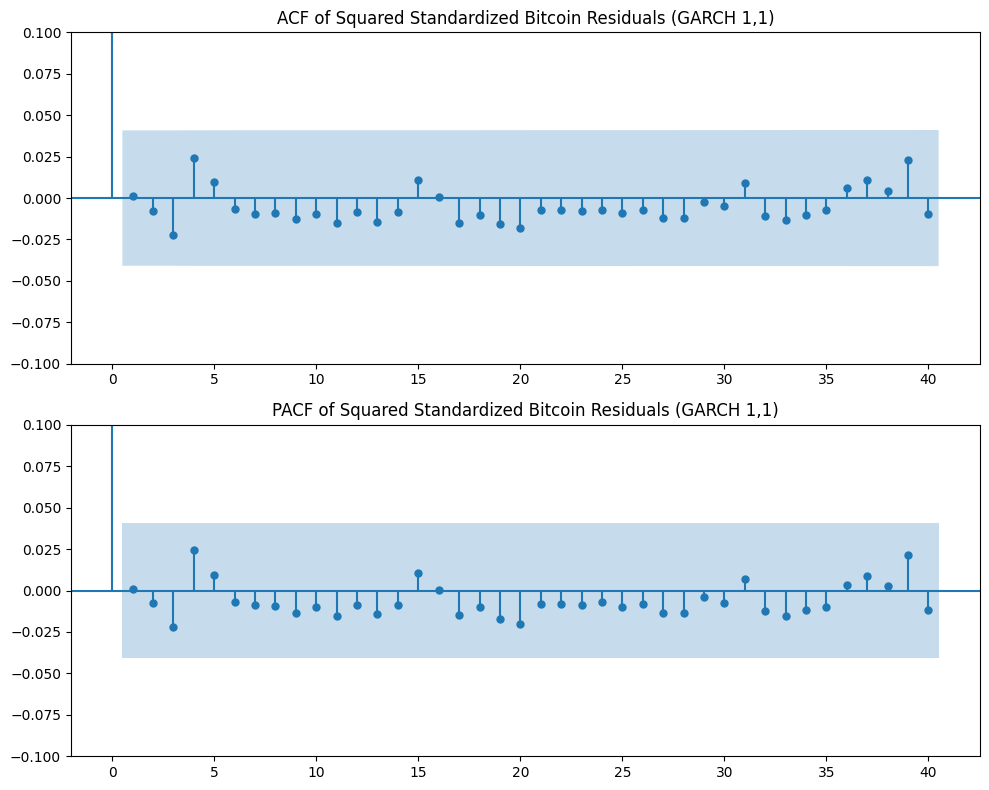

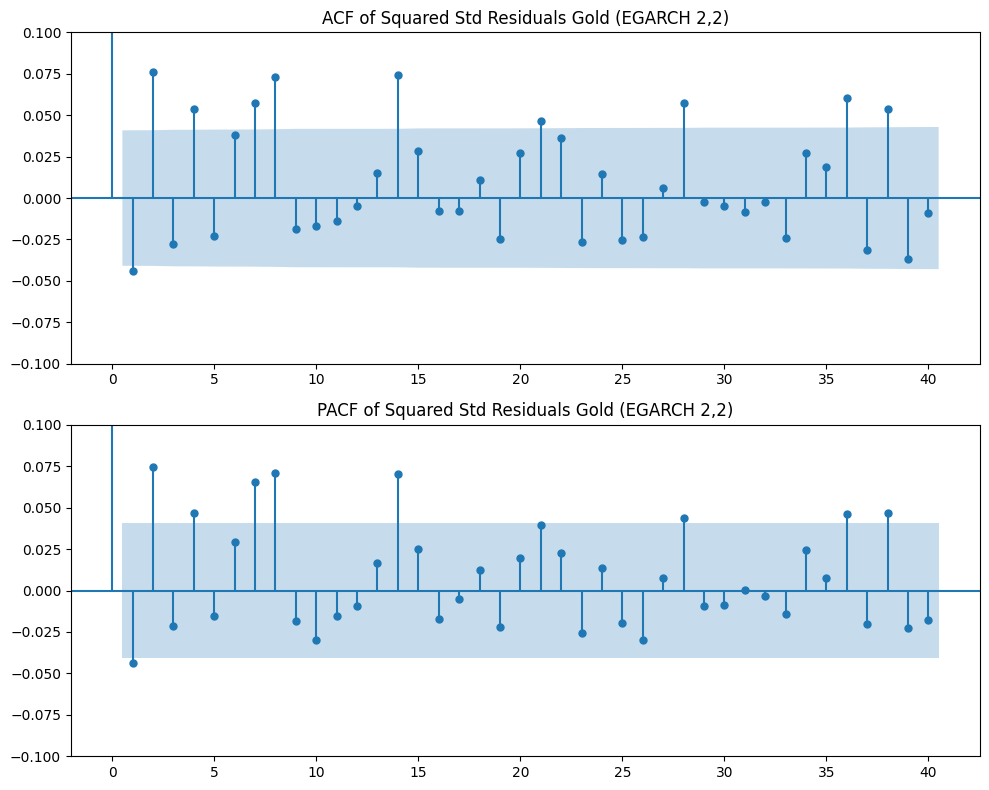

In [32]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==========================================
# 1. BITCOIN DIAGNOSTICS (Model: GARCH 1,1)
# ==========================================

# Get standardized residuals from your GARCH(1,1)
btc_std_resid = res_garch_btc.std_resid

# Square them (to check for remaining volatility clustering)
btc_std_resid_sq = btc_std_resid**2

# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(btc_std_resid_sq.dropna(), ax=axes[0], lags=40)
plot_pacf(btc_std_resid_sq.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Bitcoin Residuals (GARCH 1,1)')
axes[1].set_title('PACF of Squared Standardized Bitcoin Residuals (GARCH 1,1)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()


# ==========================================
# 2. GOLD DIAGNOSTICS (Model: EGARCH 2,2)
# ==========================================
# We use 'res_egarch22_gold' because that was your AIC winner!

# Get standardized residuals
gold_std_resid = res_egarch22_gold.std_resid

# Square them
gold_std_resid_sq = gold_std_resid**2

# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Std Residuals Gold (EGARCH 2,2)')
axes[1].set_title('PACF of Squared Std Residuals Gold (EGARCH 2,2)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# --- 0. SETUP: Define Forecast Horizon ---
# Assuming 'test_data' is your 30% split dataframe
n_forecast = len(test_data)

# ======================================================
#      STEP 1: GENERATE FORECASTS (SCALED)
# ======================================================

# --- A. BITCOIN (Using Statsmodels ARIMA) ---
# We use .forecast() because it's a statsmodels object
# This predicts the RETURN (Mean)
btc_return_forecast_scaled = model_bitcoin.forecast(steps=n_forecast)

# --- B. GOLD (Using Pmdarima Auto_Arima) ---
# We use .predict() because it's a pmdarima object
# This predicts the RETURN (Mean)
gold_return_forecast_scaled = model_gold.predict(n_periods=n_forecast)


# ======================================================
#      STEP 2: RESCALE BACK TO ORIGINAL UNITS
# ======================================================
# You trained on (Log Return * 100), so we must divide by 100
# to get back to normal "Log Returns" for comparison.

final_btc_pred = btc_return_forecast_scaled / 100
final_gold_pred = gold_return_forecast_scaled / 100


# ======================================================
#      STEP 3: EVALUATE (RMSE comparison for Thesis)
# ======================================================
# We compare your ARIMA forecasts against the ACTUAL test data returns

# 1. Get Actual Returns (Unscaled)
actual_btc = test_data['Bitcoin_logret']
actual_gold = test_data['Gold_logret']

# 2. Calculate RMSE
rmse_btc = np.sqrt(mean_squared_error(actual_btc, final_btc_pred))
rmse_gold = np.sqrt(mean_squared_error(actual_gold, final_gold_pred))

print("--- ARIMA-GARCH/EGARCH FORECAST RESULTS ---")
print(f"Bitcoin RMSE (Return Prediction): {rmse_btc:.6f}")
print(f"Gold RMSE (Return Prediction):    {rmse_gold:.6f}")

# (You will compare these two numbers against your LSTM RMSE numbers)

--- ARIMA-GARCH/EGARCH FORECAST RESULTS ---
Bitcoin RMSE (Return Prediction): 0.027914
Gold RMSE (Return Prediction):    0.007942


# forecast

In [39]:
# 1. Set the forecast horizon (if not already set)
horizon_len = len(test_data)

# 2. Run the simulations for Bitcoin
fc_btc = res_garch_btc.forecast(horizon=horizon_len, method='simulation', simulations=1000)

# 3. Get the *average* variance across all 1000 simulations
btc_volatility_forecast = fc_btc.variance.mean(axis=1)

# 4. Rescale
btc_volatility_forecast = btc_volatility_forecast * (1/100)**2

print("Bitcoin Volatility Forecast (GARCH):")
display(btc_volatility_forecast)

Bitcoin Volatility Forecast (GARCH):


,0
987,0.002677


In [40]:
# 1. Set the forecast horizon (if not already set)
horizon_len = len(test_data)

# 2. Run the simulations for Gold using the EGARCH(2,2) model
# CHANGE: Use 'res_egarch22_gold' instead of 'res_gjr_garch_gold'
fc_gold_egarch = res_egarch22_gold.forecast(horizon=horizon_len, method='simulation', simulations=1000)

# 3. Get the *average* variance across all 1000 simulations
gold_vol_forecast_egarch = fc_gold_egarch.variance.mean(axis=1)

# 4. Rescale back to original units
# Since we trained on data * 100, we divide variance by 100^2
gold_vol_forecast_egarch = gold_vol_forecast_egarch * (1/100)**2

print("Gold Volatility Forecast (EGARCH 2,2):")
display(gold_vol_forecast_egarch)

Gold Volatility Forecast (EGARCH 2,2):


,0
987,1.420054e+49


In [42]:
import matplotlib.pyplot as plt

In [43]:
import numpy as np

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SET FORECAST HORIZON ---
horizon_len = len(test_data)

# --- 2. RUN BITCOIN FORECAST (GARCH) ---
# We use axis=0 to average across the 1000 simulations
fc_btc = res_garch_btc.forecast(horizon=horizon_len, method='simulation', simulations=1000)
btc_vol_forecast_series = fc_btc.variance.mean(axis=0)

# --- 3. RUN GOLD FORECAST (GJR-GARCH) ---
# We use axis=0 to average across the 1000 simulations
fc_gold_gjr = res_gjr_garch_gold.forecast(horizon=horizon_len, method='simulation', simulations=1000)
gold_vol_forecast_series = fc_gold_gjr.variance.mean(axis=0)

# --- 4. RESCALE AND CONVERT TO % VOLATILITY ---
# Rescale the variance from (return*100)^2 back to return^2
btc_variance_rescaled = btc_vol_forecast_series * (1/100)**2
gold_variance_rescaled = gold_vol_forecast_series * (1/100)**2

# Convert variance to % volatility (sqrt * 100)
btc_vol_pct = np.sqrt(btc_variance_rescaled) * 100
gold_vol_pct = np.sqrt(gold_variance_rescaled) * 100

# --- 5. CREATE THE FINAL 30-DAY PLOT ---
days_to_plot = 30

plt.figure(figsize=(12, 7))

# Plot the first 30 days
# We use .values to plot against a 0-29 index
plt.plot(btc_vol_pct.values[:days_to_plot], label='Bitcoin Forecasted Volatility (GARCH)', color='blue', marker='.')
plt.plot(gold_vol_pct.values[:days_to_plot], label='Gold Forecasted Volatility (GJR-GARCH)', color='orange', marker='.')

# Add Labels and Title
plt.title('30-Day Volatility Forecast (Bitcoin vs. Gold)', fontsize=16)
plt.xlabel('Forecast Horizon (Days into the future)', fontsize=12)
plt.ylabel('Forecasted Daily Volatility (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(0, days_to_plot, 5)) # Make the x-axis labels cleaner

plt.show()

In [ ]:
# Set the number of days you want to display
days_to_display = 30

# --- Display the first 30 data points ---

print("--- Bitcoin Forecasted Daily Volatility (%) [First 30 Days] ---")
# We use .iloc[:days_to_display] to get the first 30
# We convert to a DataFrame for nicer printing
display(pd.DataFrame(btc_vol_pct.iloc[:days_to_display], columns=['Forecasted Volatility (%)']))

print("\n--- Gold Forecasted Daily Volatility (%) [First 30 Days] ---")
display(pd.DataFrame(gold_vol_pct.iloc[:days_to_display], columns=['Forecasted Volatility (%)']))

--- Bitcoin Forecasted Daily Volatility (%) [First 30 Days] ---


,Forecasted Volatility (%)
h.001,2.806796
h.002,2.818328
h.003,2.853127
h.004,2.866046
h.005,2.870611
h.006,2.900381
h.007,2.905603
h.008,2.918944
h.009,2.955477
h.010,2.943793



--- Gold Forecasted Daily Volatility (%) [First 30 Days] ---


,Forecasted Volatility (%)
h.001,1.008002
h.002,1.005375
h.003,1.003701
h.004,1.009662
h.005,1.010267
h.006,1.010208
h.007,1.009401
h.008,1.010158
h.009,1.012423
h.010,1.014353


# LSTM Bitcoin Preparing Data 70:30

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# --- 1. SET PARAMETERS ---

# Use the 'Bitcoin_logret' column from your 'merged' DataFrame
# Ensure 'merged' DataFrame is available
data_to_use = merged['Bitcoin_logret'].values.reshape(-1, 1)

# Set the "look-back" period
window_size = 30

# --- 2. SCALE THE DATA ---
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_to_use)

# --- 3. CREATE SEQUENCES (X, y) ---
X = []
y = []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0]) # The past 30 days
    y.append(scaled_data[i, 0])               # The 31st day

X, y = np.array(X), np.array(y)

# --- 4. SPLIT INTO TRAINING (70%) AND TESTING (30%) ---
train_size = int(len(X) * 0.7) # Changed to 70%
test_size = len(X) - train_size

X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

# --- 5. RESHAPE FOR LSTM [samples, timesteps, features] ---
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# --- 6. PRINT SHAPES TO CONFIRM ---
print("--- Data Preparation Complete (70:30 Split) ---")
print(f"Window size (timesteps): {window_size}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

--- Data Preparation Complete (70:30 Split) ---
Window size (timesteps): 30
X_train shape: (2279, 30, 1)
y_train shape: (2279,)
X_test shape: (978, 30, 1)
y_test shape: (978,)


#LSTM Bitcoin

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# --- 1. BUILD THE LSTM MODEL ---

model = Sequential()

# Layer 1: LSTM layer
# 50 units is a good starting point.
# return_sequences=True is needed because we're stacking another LSTM layer.
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2)) # Dropout helps prevent overfitting

# Layer 2: Another LSTM layer
model.add(LSTM(units=50, return_sequences=False)) # False because it's the last LSTM layer
model.add(Dropout(0.2))

# Layer 3: The Output Layer
# A Dense layer with 1 unit to predict our single output (the next day's return)
model.add(Dense(units=1))

# --- 2. COMPILE THE MODEL ---

# We tell the model how to learn.
# 'adam' is a popular and effective optimizer.
# 'mean_squared_error' is the best loss function for regression (predicting a number)
model.compile(optimizer='adam', loss='mean_squared_error')

# --- 3. TRAIN THE MODEL ("fit" the data) ---

# This is where the model "learns" from your training data.
# We'll train for 20 "epochs" (passes through the data)
# A batch_size of 32 is standard.
print("\n--- Starting Model Training ---")

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test), # We use the test set to see how it's doing
    verbose=1
)

print("--- Model Training Complete ---")

# --- 4. DISPLAY THE MODEL STRUCTURE ---
model.summary()


--- Starting Model Training ---
Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.0845 - val_loss: 0.0015
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0070 - val_loss: 0.0016
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0067 - val_loss: 0.0017
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0063 - val_loss: 0.0018
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0065 - val_loss: 0.0016
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0055 - val_loss: 0.0017
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0063 - val_loss: 0.0015
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0060 - val_loss: 0.0016
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0060 - val_loss: 0.0019
Epoch 10/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0056 - val_loss: 0.0016
Epoch 11/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0053 - val_loss: 0.0015
Epoch 12/50
72/72 ━━━━━━━━━━━━

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Test RMSE: 0.028195


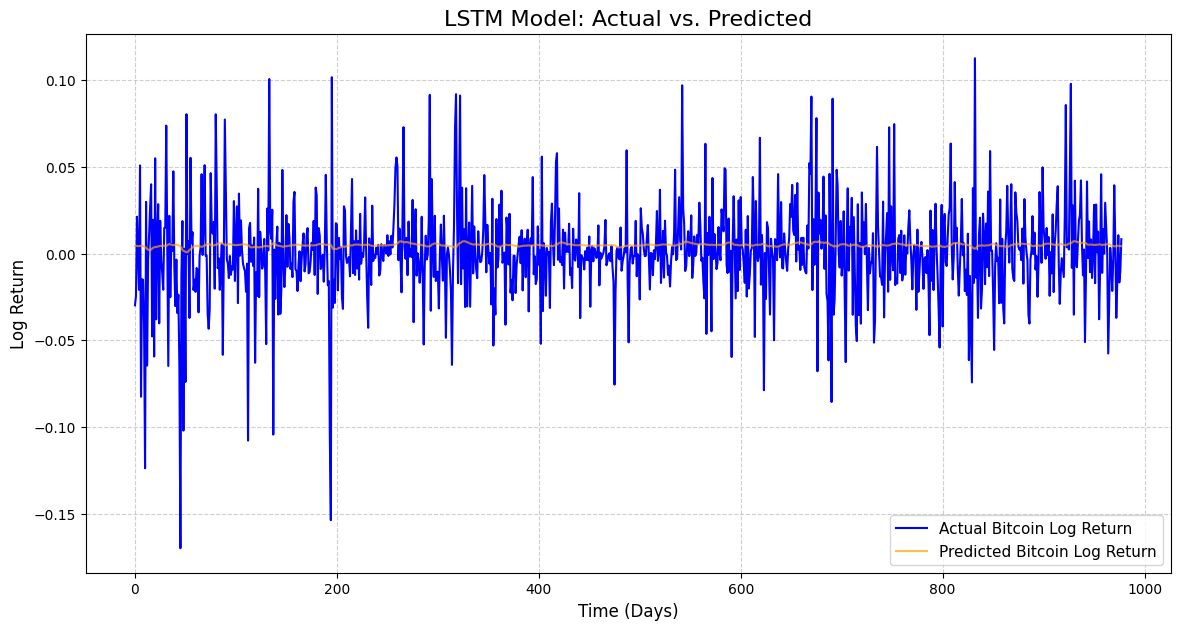

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# --- 1. MAKE PREDICTIONS ---
# Use the trained model to predict on the unseen test data
predicted_scaled = model.predict(X_test)

# --- 2. UN-SCALE THE DATA ---
# We must use the 'scaler' object from your data prep step
# to reverse the 0-to-1 scaling.

# Un-scale the predictions
predictions = scaler.inverse_transform(predicted_scaled)

# Un-scale the *actual* values so we can compare
actual_values = scaler.inverse_transform(y_test.reshape(-1, 1))

# --- 3. CALCULATE ERROR (RMSE) ---
# Root Mean Squared Error (RMSE) is a great metric
rmse = np.sqrt(mean_squared_error(actual_values, predictions))
print(f'Test RMSE: {rmse:.6f}')

# --- 4. PLOT THE RESULTS ---
# This is the most important visual.
plt.figure(figsize=(14, 7))
plt.plot(actual_values, color='blue', label='Actual Bitcoin Log Return')
plt.plot(predictions, color='orange', label='Predicted Bitcoin Log Return', alpha=0.7)
plt.title('LSTM Model: Actual vs. Predicted', fontsize=16)
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Log Return', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━

,Forecasted Log Return
Day,
1,0.004274
2,0.004342
3,0.004442
4,0.004555
5,0.004669
6,0.004779
7,0.004878
8,0.004966
9,0.005042


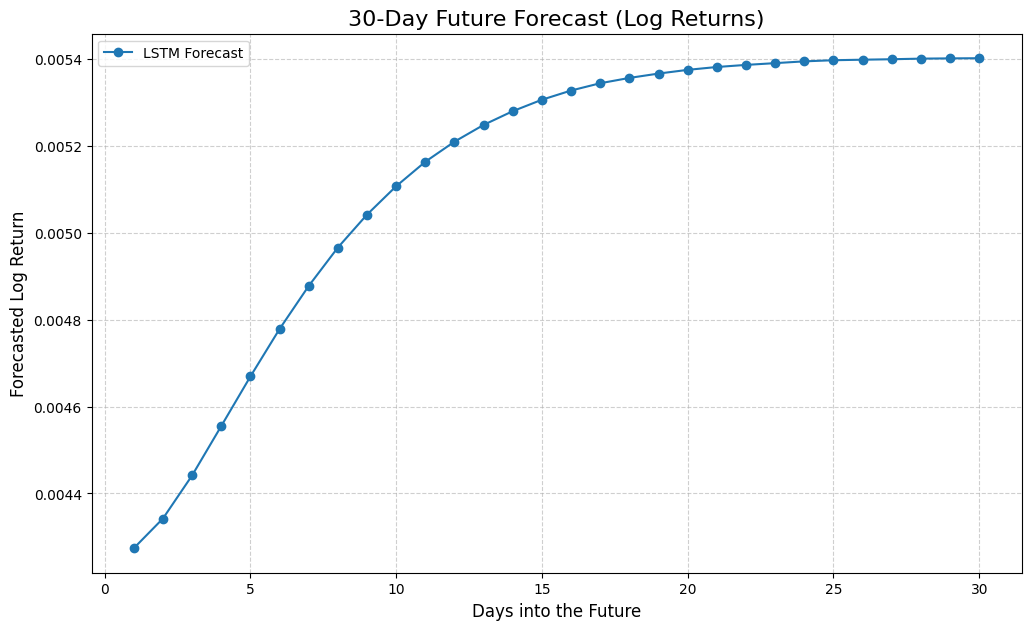

In [ ]:
# --- 1. SET FORECAST PARAMETERS ---
n_future_days = 30
window_size = 30 # This must be the same as your training 'window_size'

# --- 2. GET THE LAST WINDOW OF REAL DATA ---
# We take the last 30 days from your *full* dataset
last_real_window = scaled_data[-window_size:]

# Reshape it to be the input for the model
current_window = last_real_window.reshape(1, window_size, 1)

# --- 3. ITERATIVE FORECASTING (Predict 30 days) ---
# This loop will:
# 1. Predict day 1
# 2. Add day 1's prediction to the window
# 3. Use the new window to predict day 2
# ...and so on, for 30 days.

future_predictions_scaled = [] # Store the scaled predictions

for i in range(n_future_days):
    # 1. Predict the next day
    next_pred_scaled = model.predict(current_window)[0, 0]

    # 2. Store the prediction
    future_predictions_scaled.append(next_pred_scaled)

    # 3. Update the window for the next loop
    # Reshape the prediction to be added to the window
    next_pred_reshaped = np.array([[next_pred_scaled]])

    # Remove the *first* day from the window and add the *new prediction* to the end
    current_window = np.append(current_window[:, 1:, :], next_pred_reshaped.reshape(1, 1, 1), axis=1)

# --- 4. UN-SCALE THE FINAL FORECAST ---
# We now have 30 days of scaled predictions
future_predictions = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

# --- 5. DISPLAY THE 30-DAY DATA (YOUR REQUEST) ---
print(f"--- LSTM 30-Day Future Forecast (Log Returns) ---")

# Create a nice DataFrame to display
forecast_df = pd.DataFrame(future_predictions,
                           columns=['Forecasted Log Return'],
                           index=np.arange(1, n_future_days + 1))
forecast_df.index.name = 'Day'
display(forecast_df)

# --- 6. PLOT THE 30-DAY FORECAST ---
plt.figure(figsize=(12, 7))
plt.plot(forecast_df.index, forecast_df['Forecasted Log Return'], marker='o', label='LSTM Forecast')
plt.title('30-Day Future Forecast (Log Returns)', fontsize=16)
plt.xlabel('Days into the Future', fontsize=12)
plt.ylabel('Forecasted Log Return', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# forecast with raw data bitcoin LSTM

--- Data Shapes (70:30 Split) ---
X_train: (2279, 30, 1)
X_test:  (978, 30, 1)

--- Starting Model Training ---
Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 0.0160 - val_loss: 0.0010
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 9.4460e-04 - val_loss: 0.0015
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 8.8465e-04 - val_loss: 0.0016
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 8.6652e-04 - val_loss: 0.0016
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 7.5412e-04 - val_loss: 0.0012
--- Model Training Complete ---

=== Performance Metrics (Train/Test) ===


,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,1176.70,4821291.59,2195.74,13.71
1,Test,2234.94,11246892.86,3353.64,5.42


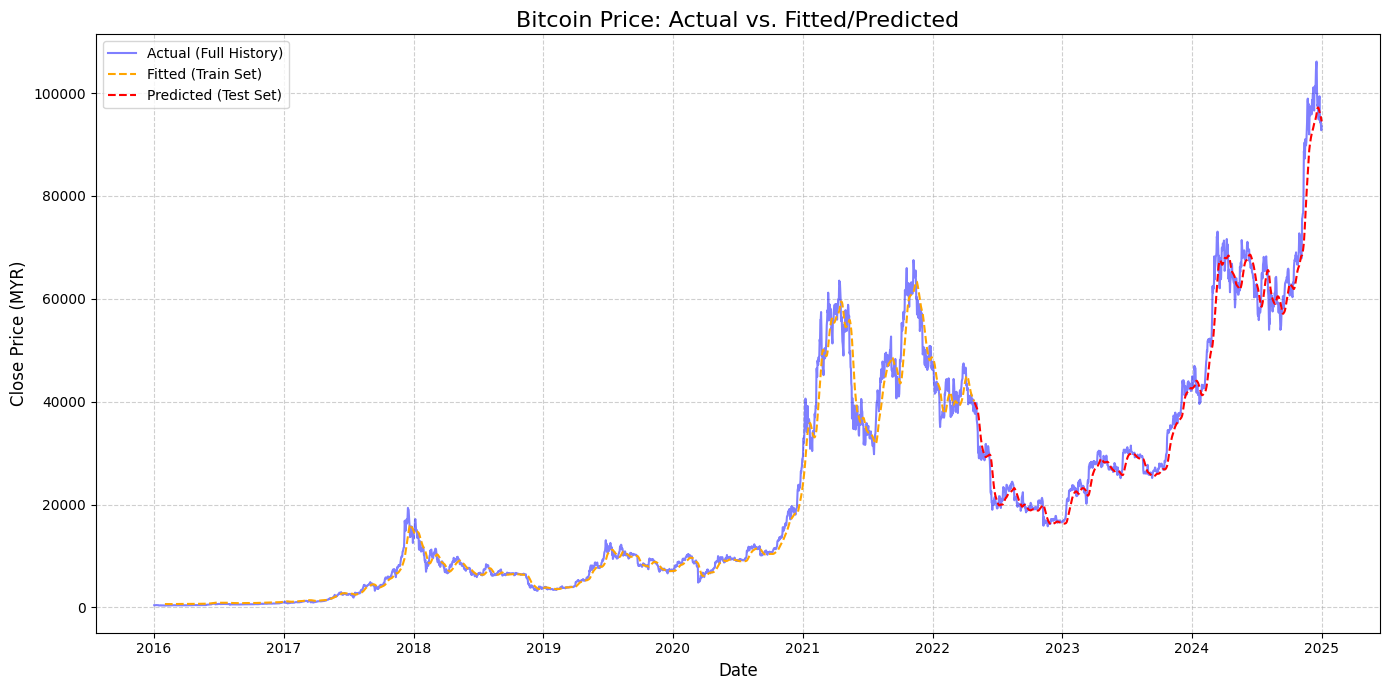

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. SET UP DATA & PARAMETERS ---
df = merged.copy()
close_col = 'Bitcoin' # <-- Changed to use the 'Bitcoin' price column
date_col = 'Date'
window_size = 30 # This is the 'adaptive_lookback'

# Ensure date column is datetime
df[date_col] = pd.to_datetime(df[date_col])

# --- 2. SCALING & DATA PREPARATION ---
data_to_use = df[close_col].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_to_use)

# --- 3. CREATE SEQUENCES ---
def make_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = make_sequences(scaled_data, window_size)

# --- 4. TRAIN / TEST SPLIT (70% Train, 30% Test) ---
# Your requested 70:30 split
train_split_idx = int(len(X) * 0.70)

X_tr, y_tr = X[:train_split_idx], y[:train_split_idx]
X_test, y_test = X[train_split_idx:], y[train_split_idx:]

# --- 5. RESHAPE FOR LSTM [samples, timesteps, features] ---
X_tr = np.reshape(X_tr, (X_tr.shape[0], X_tr.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print("--- Data Shapes (70:30 Split) ---")
print(f"X_train: {X_tr.shape}")
print(f"X_test:  {X_test.shape}")

# --- 6. BUILD & TRAIN MODEL (from your senior's code) ---
tf.random.set_seed(42)
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

# Use EarlyStopping, monitoring the test set loss
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("\n--- Starting Model Training ---")
history = model.fit(
    X_tr, y_tr,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test), # Use test set for validation with 70:30 split
    callbacks=[es],
    verbose=1
)
print("--- Model Training Complete ---")

# --- 7. EVALUATION & METRICS ---
def inverse_and_metrics(y_true_scaled, y_pred_scaled, scaler_obj):
    y_true = scaler_obj.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler_obj.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

# Get predictions (scaled)
y_pred_tr_skala = model.predict(X_tr, verbose=0).flatten()
y_pred_test_skala = model.predict(X_test, verbose=0).flatten()

# Get metrics (un-scaled)
y_true_tr, y_pred_tr, mae_tr, mse_tr, rmse_tr, mape_tr = inverse_and_metrics(y_tr, y_pred_tr_skala, scaler)
y_true_test, y_pred_test, mae_te, mse_te, rmse_te, mape_te = inverse_and_metrics(y_test, y_pred_test_skala, scaler)

# Build metrics table (Train/Test only)
metrics_df = pd.DataFrame({
    "Set": ["Train", "Test"],
    "MAE": [mae_tr, mae_te],
    "MSE": [mse_tr, mse_te],
    "RMSE": [rmse_tr, rmse_te],
    "MAPE(%)": [mape_tr, mape_te]
})

print("\n=== Performance Metrics (Train/Test) ===")
display(metrics_df.round(2))

# --- 8. PLOTTING (Full History Plot) ---

# Get the correct dates for each set
date_index = df[date_col].iloc[window_size:]
train_dates = date_index.iloc[:train_split_idx]
test_dates = date_index.iloc[train_split_idx:]

plt.figure(figsize=(14, 7))

# Plot 1: Full History
plt.plot(df[date_col], df[close_col], label="Actual (Full History)", color='blue', alpha=0.5)

# Plot 2: Fitted (Train Set)
plt.plot(train_dates, y_pred_tr, label="Fitted (Train Set)", color='orange', linestyle='--')

# Plot 3: Predicted (Test Set)
plt.plot(test_dates, y_pred_test, label="Predicted (Test Set)", color='red', linestyle='--')

plt.title(f"{close_col} Price: Actual vs. Fitted/Predicted", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Close Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


--- Data Shapes (Multivariate 70:30 Split) ---
X_train: (2279, 30, 2)
X_test:  (978, 30, 2)

--- Starting Multivariate Model Training ---
Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - loss: 0.0085 - val_loss: 0.0022
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0012 - val_loss: 0.0024
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 8.8229e-04 - val_loss: 0.0011
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 8.4237e-04 - val_loss: 0.0012
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 8.1818e-04 - val_loss: 0.0010
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 7.2020e-04 - val_loss: 0.0017
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 6.6366e-04 - val_loss: 9.7941e-04
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 7.8432e-04 - val_loss: 0.0012
Epoch 10/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 7.0468e-

,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,1096.53,3757532.89,1938.44,9.21
1,Test,2175.83,7703408.72,2775.50,6.33


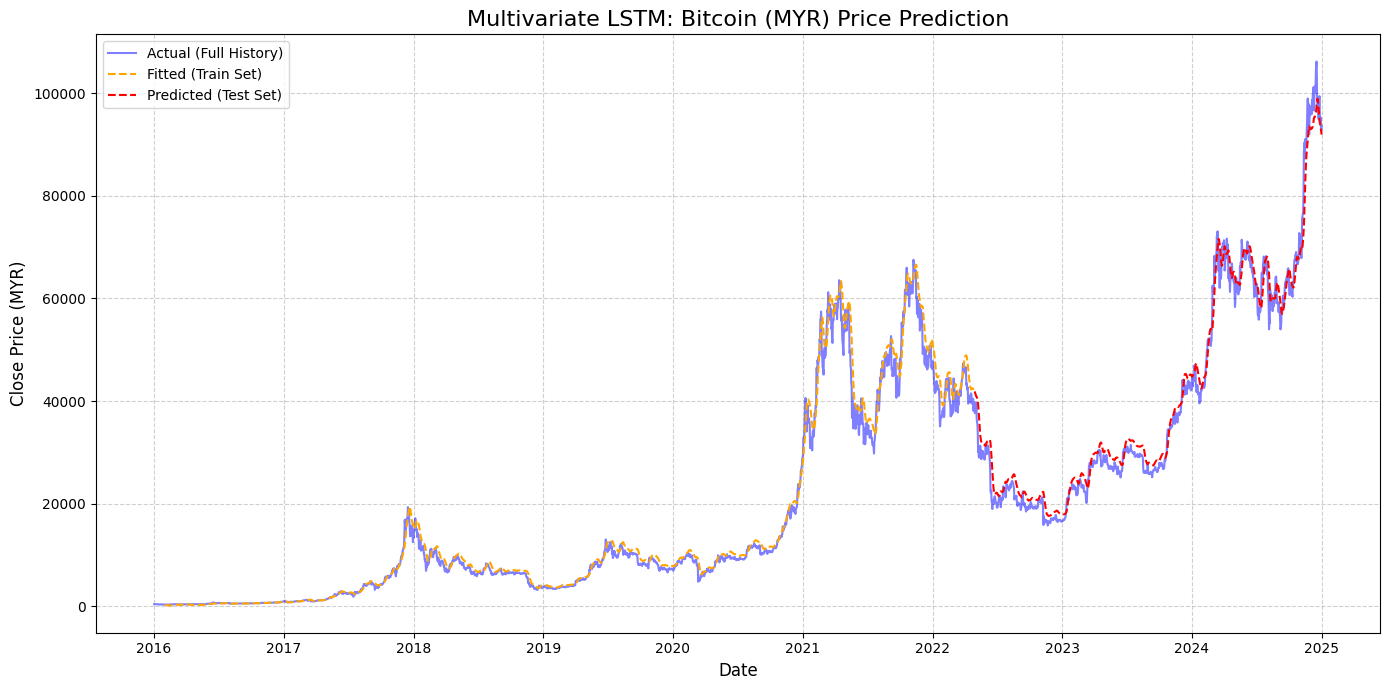

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. SET UP FOR MULTIVARIATE LSTM ---
df = merged.copy()
feature_cols = ['Bitcoin', 'Gold']
target_col = 'Bitcoin'
date_col = 'Date'
window_size = 30

# --- 2. SCALING ---
data_to_use = df[feature_cols].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_to_use)

# --- 3. CREATE SEQUENCES (Multivariate) ---
def make_sequences_multi(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :]) # All features for the window
        y.append(data[i, 0])               # Only the 1st col (Bitcoin) as target
    return np.array(X), np.array(y)

X, y = make_sequences_multi(scaled_data, window_size)

# --- 4. TRAIN / TEST SPLIT (70% Train, 30% Test) ---
train_split_idx = int(len(X) * 0.70)
X_tr, y_tr = X[:train_split_idx], y[:train_split_idx]
X_test, y_test = X[train_split_idx:], y[train_split_idx:]

# --- 5. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features = len(feature_cols)
# X_tr and X_test are already (samples, 30, 2)
print("\n--- Data Shapes (Multivariate 70:30 Split) ---")
print(f"X_train: {X_tr.shape}")
print(f"X_test:  {X_test.shape}")

# --- 7. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1) # Still 1 output (predicting Bitcoin)
])
model.compile(optimizer="adam", loss="mse")
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("\n--- Starting Multivariate Model Training ---")
history = model.fit(
    X_tr, y_tr,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[es],
    verbose=1
)
print("--- Model Training Complete ---")

# --- 8. EVALUATION & METRICS (Multivariate) ---
def inverse_and_metrics_multi(y_true_scaled, y_pred_scaled, scaler_obj):
    n_features = scaler_obj.n_features_in_

    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 0] = y_pred_scaled.flatten()
    y_pred = scaler_obj.inverse_transform(pred_combined)[:, 0]

    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 0] = y_true_scaled.flatten()
    y_true = scaler_obj.inverse_transform(true_combined)[:, 0]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala = model.predict(X_tr, verbose=0).flatten()
y_pred_test_skala = model.predict(X_test, verbose=0).flatten()

y_true_tr, y_pred_tr, mae_tr, mse_tr, rmse_tr, mape_tr = inverse_and_metrics_multi(y_tr, y_pred_tr_skala, scaler)
y_true_test, y_pred_test, mae_te, mse_te, rmse_te, mape_te = inverse_and_metrics_multi(y_test, y_pred_test_skala, scaler)

metrics_df = pd.DataFrame({
    "Set": ["Train", "Test"],
    "MAE": [mae_tr, mae_te],
    "MSE": [mse_tr, mse_te],
    "RMSE": [rmse_tr, rmse_te],
    "MAPE(%)": [mape_tr, mape_te]
})

print("\n=== Ringkasan Metrik (Multivariate Train/Test) ===")
display(metrics_df.round(2))

# --- 9. PLOTTING (Full History Plot) ---
date_index = df[date_col].iloc[window_size:]
train_dates = date_index.iloc[:train_split_idx]
test_dates = date_index.iloc[train_split_idx:]

plt.figure(figsize=(14, 7))
plt.plot(df[date_col], df[target_col], label="Actual (Full History)", color='blue', alpha=0.5)
plt.plot(train_dates, y_pred_tr, label="Fitted (Train Set)", color='orange', linestyle='--')
plt.plot(test_dates, y_pred_test, label="Predicted (Test Set)", color='red', linestyle='--')
plt.title(f"Multivariate LSTM: Bitcoin (MYR) Price Prediction", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Close Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


--- Data Shapes (Multivariate Gold 70:30 Split) ---
X_train: (2279, 30, 2)
X_test:  (978, 30, 2)

--- Starting Multivariate Model Training (Predicting Gold) ---
Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - loss: 0.0153 - val_loss: 0.0013
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 9.7889e-04 - val_loss: 0.0014
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 9.2007e-04 - val_loss: 6.9032e-04
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 9.6301e-04 - val_loss: 0.0024
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 7.4693e-04 - val_loss: 0.0031
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 8.1075e-04 - val_loss: 0.0011
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 6.6668e-04 - val_loss: 7.2420e-04
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 6.2259e-04 - val_loss: 0.0016
--- Model Training Complete ---

===

,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,99.76,16646.39,129.02,1.60
1,Test,146.91,40353.44,200.88,1.51


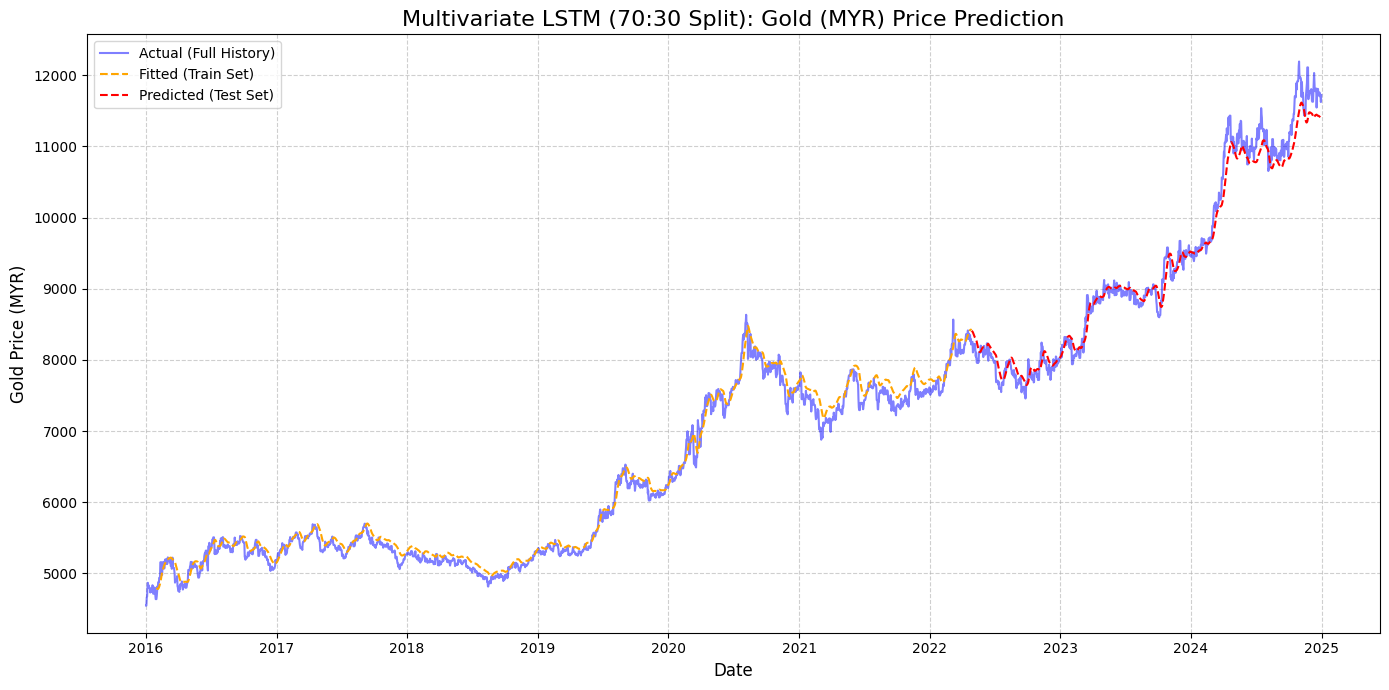

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# --- 3. SET UP FOR MULTIVARIATE LSTM (Predicting Gold) ---
df_gold_70 = merged.copy()
feature_cols_gold_70 = ['Bitcoin', 'Gold'] # <-- Inputs
target_col_gold_70 = 'Gold'               # <-- Output
date_col_gold_70 = 'Date'
window_size_gold_70 = 30

# --- 4. SCALING ---
data_to_use_gold_70 = df_gold_70[feature_cols_gold_70].values
scaler_gold_70 = MinMaxScaler(feature_range=(0, 1)) # New scaler
scaled_data_gold_70 = scaler_gold_70.fit_transform(data_to_use_gold_70)

# --- 5. CREATE SEQUENCES (Multivariate for Gold) ---
def make_sequences_multi_gold_70(data, window_size): # New function
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :]) # All features (BTC & Gold)
        y.append(data[i, 1])               # ⭐ CHANGE: Target is col 1 (Gold)
    return np.array(X), np.array(y)

X_gold_70, y_gold_70 = make_sequences_multi_gold_70(scaled_data_gold_70, window_size_gold_70)

# --- 6. TRAIN / TEST SPLIT (70% Train, 30% Test) ---
train_split_idx_gold_70 = int(len(X_gold_70) * 0.70) # Kept 70:30
X_tr_gold_70, y_tr_gold_70 = X_gold_70[:train_split_idx_gold_70], y_gold_70[:train_split_idx_gold_70]
X_test_gold_70, y_test_gold_70 = X_gold_70[train_split_idx_gold_70:], y_gold_70[train_split_idx_gold_70:]

# --- 7. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features_gold_70 = len(feature_cols_gold_70)
print("\n--- Data Shapes (Multivariate Gold 70:30 Split) ---")
print(f"X_train: {X_tr_gold_70.shape}")
print(f"X_test:  {X_test_gold_70.shape}")

# --- 8. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model_gold_70 = Sequential([ # New model
    LSTM(64, return_sequences=True, input_shape=(window_size_gold_70, n_features_gold_70)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model_gold_70.compile(optimizer="adam", loss="mse")
es_gold_70 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("\n--- Starting Multivariate Model Training (Predicting Gold) ---")
history_gold_70 = model_gold_70.fit(
    X_tr_gold_70, y_tr_gold_70,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_gold_70, y_test_gold_70),
    callbacks=[es_gold_70],
    verbose=1
)
print("--- Model Training Complete ---")

# --- 9. EVALUATION & METRICS (Multivariate for Gold) ---
def inverse_and_metrics_multi_gold_70(y_true_scaled, y_pred_scaled, scaler_obj_gold_70): # New function
    n_features = scaler_obj_gold_70.n_features_in_

    # ⭐ CHANGE: Put prediction in col 1 (Gold)
    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 1] = y_pred_scaled.flatten()
    y_pred = scaler_obj_gold_70.inverse_transform(pred_combined)[:, 1] # Get col 1

    # ⭐ CHANGE: Put actual in col 1 (Gold)
    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 1] = y_true_scaled.flatten()
    y_true = scaler_obj_gold_70.inverse_transform(true_combined)[:, 1] # Get col 1

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala_gold_70 = model_gold_70.predict(X_tr_gold_70, verbose=0).flatten()
y_pred_test_skala_gold_70 = model_gold_70.predict(X_test_gold_70, verbose=0).flatten()

y_true_tr_gold_70, y_pred_tr_gold_70, mae_tr_gold_70, mse_tr_gold_70, rmse_tr_gold_70, mape_tr_gold_70 = inverse_and_metrics_multi_gold_70(y_tr_gold_70, y_pred_tr_skala_gold_70, scaler_gold_70)
y_true_test_gold_70, y_pred_test_gold_70, mae_te_gold_70, mse_te_gold_70, rmse_te_gold_70, mape_te_gold_70 = inverse_and_metrics_multi_gold_70(y_test_gold_70, y_pred_test_skala_gold_70, scaler_gold_70)

metrics_df_gold_70 = pd.DataFrame({
    "Set": ["Train", "Test"],
    "MAE": [mae_tr_gold_70, mae_te_gold_70],
    "MSE": [mse_tr_gold_70, mse_te_gold_70],
    "RMSE": [rmse_tr_gold_70, rmse_te_gold_70],
    "MAPE(%)": [mape_tr_gold_70, mape_te_gold_70]
})

print("\n=== Ringkasan Metrik (Multivariate Gold 70:30 Split) ===")
display(metrics_df_gold_70.round(2))

# --- 10. PLOTTING (Full History Plot) ---
date_index_gold_70 = df_gold_70[date_col_gold_70].iloc[window_size_gold_70:]
train_dates_gold_70 = date_index_gold_70.iloc[:train_split_idx_gold_70]
test_dates_gold_70 = date_index_gold_70.iloc[train_split_idx_gold_70:]

plt.figure(figsize=(14, 7))
# ⭐ CHANGE: Plot the 'Gold' column as the actual
plt.plot(df_gold_70[date_col_gold_70], df_gold_70[target_col_gold_70], label="Actual (Full History)", color='blue', alpha=0.5)
plt.plot(train_dates_gold_70, y_pred_tr_gold_70, label="Fitted (Train Set)", color='orange', linestyle='--')
plt.plot(test_dates_gold_70, y_pred_test_gold_70, label="Predicted (Test Set)", color='red', linestyle='--')

# ⭐ CHANGE: Updated titles
plt.title(f"Multivariate LSTM (70:30 Split): Gold (MYR) Price Prediction", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Gold Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Split 75:25


In [ ]:
train75_size = int(len(merged) * 0.75)
train75_data = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[0:train75_size]
test75_data = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[train75_size:len(merged)]

print("Training data size:", len(train75_data))
print("Testing data size:", len(test75_data))

Training data size: 2465
Testing data size: 822


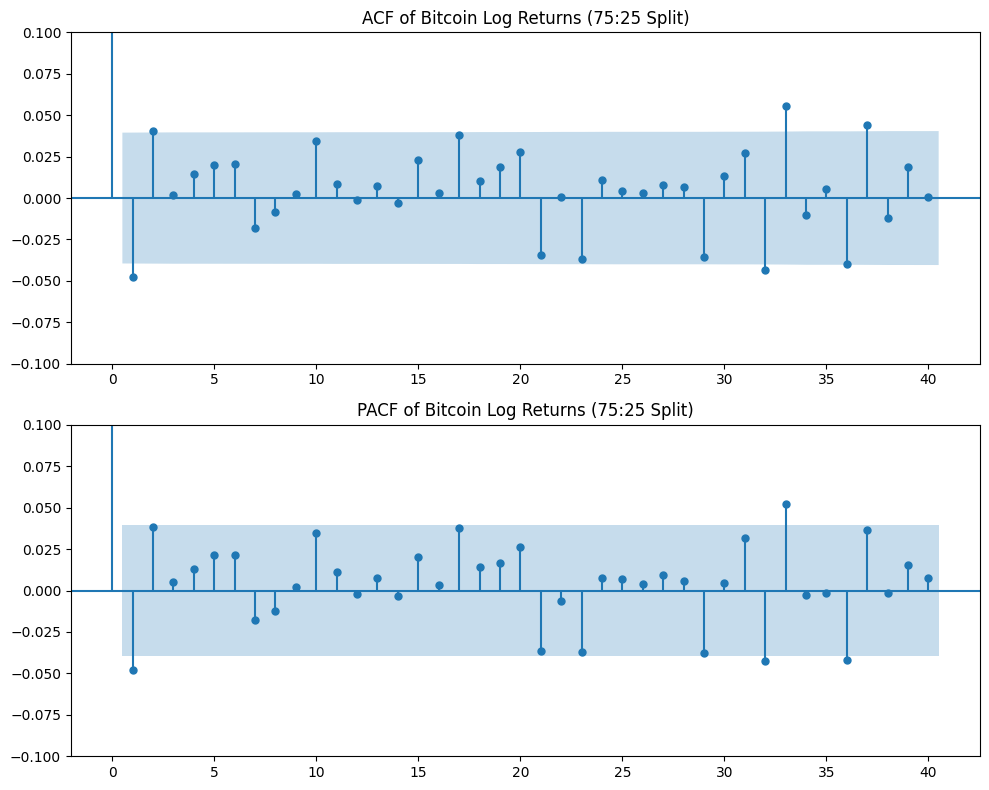

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for Bitcoin Log Returns (75:25 Split)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(train75_data['Bitcoin_logret'].dropna(), ax=axes[0], lags=40)
plot_pacf(train75_data['Bitcoin_logret'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Bitcoin Log Returns (75:25 Split)')
axes[1].set_title('PACF of Bitcoin Log Returns (75:25 Split)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

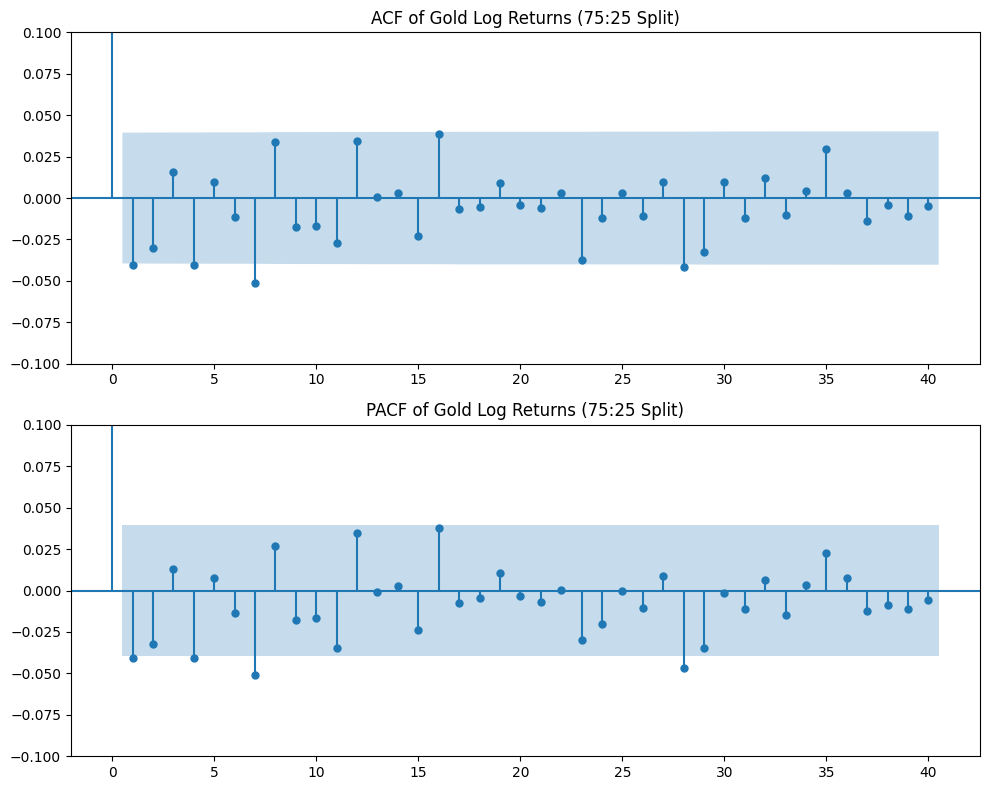

In [ ]:
# Plot ACF and PACF for Gold Log Returns (75:25 Split)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(train75_data['Gold_logret'].dropna(), ax=axes[0], lags=40)
plot_pacf(train75_data['Gold_logret'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Gold Log Returns (75:25 Split)')
axes[1].set_title('PACF of Gold Log Returns (75:25 Split)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

In [ ]:
# Fit auto_arima model on Bitcoin log returns
model75_bitcoin = ARIMA(train75_data['Bitcoin_logret']*100, order=(2, 0, 4), trend='c').fit()
print("Bitcoin ARIMA(2, 0, 4) Model Summary:")
print(model75_bitcoin.summary())

# Fit auto_arima model on Gold log returns
model75_gold = ARIMA(train75_data['Gold_logret']*100, order=(3, 0, 3), trend='c').fit()
print("\nGold ARIMA(3,0,3) Model Summary:")
print(model75_gold.summary())

Bitcoin ARIMA(2, 0, 4) Model Summary:
                               SARIMAX Results                                
Dep. Variable:         Bitcoin_logret   No. Observations:                 2465
Model:                 ARIMA(2, 0, 4)   Log Likelihood               -6904.797
Date:                Wed, 19 Nov 2025   AIC                          13825.595
Time:                        23:14:11   BIC                          13872.074
Sample:                             0   HQIC                         13842.481
                               - 2465                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1511      0.083      1.816      0.069      -0.012       0.314
ar.L1          1.1765      0.009    138.378      0.000       1.160       1.193
ar.L2         

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ==========================================
#    CONFIGURATION: AUTO GRID SEARCH
# ==========================================

# Define the maximum order you want to test (e.g., 3 means p=0,1,2,3)
max_p = 5
max_q = 5
d_value = 0  # Fixed at 0 for Log Returns

# --- AUTOMATICALLY GENERATE CANDIDATE LIST ---
# This list comprehension replaces typing them out manually.
# It creates [(0,0,0), (0,0,1) ... up to (3,0,3)]
grid_search_candidates = [
    (p, d_value, q)
    for p in range(0, max_p + 1)
    for q in range(0, max_q + 1)
]

print(f"Generated {len(grid_search_candidates)} models for grid search.")
# You can use this SAME list for both assets since it covers everything.
bitcoin_candidates_75 = grid_search_candidates
gold_candidates_75 = grid_search_candidates


# --- HELPER FUNCTION ---
def run_model_list(data, model_list, asset_name):
    results = []
    print(f"Running models for {asset_name}...")

    for param in model_list:
        try:
            # Fit ARIMA model (trend='c' adds intercept)
            model = ARIMA(data, order=param, trend='c')
            model_fit = model.fit()

            results.append({
                'Model': f"ARIMA{param}",
                'AIC': round(model_fit.aic, 2),
                'BIC': round(model_fit.bic, 2)
            })
        except:
            continue

    # Sort by AIC
    df = pd.DataFrame(results)
    df = df.sort_values(by='AIC', ascending=True)
    return df

# ==========================================
#        EXECUTION (SCALED DATA)
# ==========================================
# IMPORTANT: Ensure 'train75_data' is defined from your split!

# 1. Run Bitcoin List (Using the auto grid list)
df_btc_75 = run_model_list(train75_data['Bitcoin_logret'] * 100, bitcoin_candidates_75, "Bitcoin (75:25)")

# 2. Run Gold List (Using the auto grid list)
df_gold_75 = run_model_list(train75_data['Gold_logret'] * 100, gold_candidates_75, "Gold (75:25)")


# --- PRINT RESULTS ---
print("\n" + "="*40)
print(" BITCOIN MODEL SELECTION (75:25 SPLIT)")
print("="*40)
print(df_btc_75) # Shows top rows (best models)

print("\n" + "="*40)
print("   GOLD MODEL SELECTION (75:25 SPLIT)")
print("="*40)
print(df_gold_75) # Shows top rows (best models)

Generated 36 models for grid search.
Running models for Bitcoin (75:25)...
Running models for Gold (75:25)...

 BITCOIN MODEL SELECTION (75:25 SPLIT)
             Model       AIC       BIC
16  ARIMA(2, 0, 4)  13825.59  13872.07
12  ARIMA(2, 0, 0)  13825.72  13848.96
2   ARIMA(0, 0, 2)  13825.77  13849.01
13  ARIMA(2, 0, 1)  13826.26  13855.31
9   ARIMA(1, 0, 3)  13826.49  13861.35
14  ARIMA(2, 0, 2)  13826.50  13861.36
7   ARIMA(1, 0, 1)  13826.72  13849.96
8   ARIMA(1, 0, 2)  13826.73  13855.78
6   ARIMA(1, 0, 0)  13827.38  13844.80
18  ARIMA(3, 0, 0)  13827.65  13856.70
33  ARIMA(5, 0, 3)  13827.69  13885.79
3   ARIMA(0, 0, 3)  13827.76  13856.81
1   ARIMA(0, 0, 1)  13827.79  13845.22
21  ARIMA(3, 0, 3)  13828.34  13874.82
15  ARIMA(2, 0, 3)  13828.35  13869.02
20  ARIMA(3, 0, 2)  13828.35  13869.02
25  ARIMA(4, 0, 1)  13828.36  13869.03
10  ARIMA(1, 0, 4)  13828.38  13869.05
4   ARIMA(0, 0, 4)  13829.20  13864.06
24  ARIMA(4, 0, 0)  13829.23  13864.09
19  ARIMA(3, 0, 1)  13829.64  1

In [ ]:
# 1. Get residuals from your auto_arima models (which are already fitted)
btc75_residuals = model75_bitcoin.resid
gold75_residuals = model75_gold.resid

# 2. Rescale the residuals to fix the DataScaleWarning
# (This is still a good practice)
btc75_resid_scaled = btc75_residuals
gold75_resid_scaled = gold75_residuals

# 3. Fit GARCH(1,1) on the SCALED RESIDUALS
# We use mean='Zero' because the residuals should already have a mean of zero.
garch75_btc = arch_model(btc75_resid_scaled,
mean='Zero',
vol='Garch', p=1, q=1,
dist='Normal')

res75_garch_btc = garch75_btc.fit(disp='off')
print("Bitcoin GARCH(1,1) on ARMA(2,2) Residuals:")
print(res75_garch_btc.summary())

# 4. Fit GARCH(1,1) on the SCALED RESIDUALS for Gold
garch75_gold = arch_model(gold75_resid_scaled,
mean='Zero',
vol='Garch', p=1, q=1,
dist='Normal')

res75_garch_gold = garch75_gold.fit(disp='off')
print("\nGold GARCH(1,1) on MA(1) Residuals:")
print(res75_garch_gold.summary())

Bitcoin GARCH(1,1) on ARMA(2,2) Residuals:
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6746.96
Distribution:                  Normal   AIC:                           13499.9
Method:            Maximum Likelihood   BIC:                           13517.4
                                        No. Observations:                 2465
Date:                Wed, Nov 19 2025   Df Residuals:                     2465
Time:                        23:17:23   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.8038

In [ ]:
# 1. Get residuals from your auto_arima models (which are already fitted)
btc75_residuals = model75_bitcoin.resid()
gold75_residuals = model75_gold.resid()

# 2. Rescale the residuals to fix the DataScaleWarning
# (This is still a good practice)
btc75_resid_scaled = btc75_residuals * 100
gold75_resid_scaled = gold75_residuals * 100

# 3. Fit GARCH(1,1) on the SCALED RESIDUALS
# We use mean='Zero' because the residuals should already have a mean of zero.
garch75_btc = arch_model(btc75_resid_scaled,
mean='Zero',
vol='Garch', p=1, q=1,
dist='Normal')

res75_garch_btc = garch75_btc.fit(disp='off')
print("Bitcoin GARCH(1,1) on ARMA(2,2) Residuals:")
print(res75_garch_btc.summary())

# 4. Fit GARCH(1,1) on the SCALED RESIDUALS for Gold
garch75_gold = arch_model(gold75_resid_scaled,
mean='Zero',
vol='Garch', p=1, q=1,
dist='Normal')

res75_garch_gold = garch75_gold.fit(disp='off')
print("\nGold GARCH(1,1) on MA(1) Residuals:")
print(res75_garch_gold.summary())

Bitcoin GARCH(1,1) on ARMA(2,2) Residuals:
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6751.04
Distribution:                  Normal   AIC:                           13508.1
Method:            Maximum Likelihood   BIC:                           13525.5
                                        No. Observations:                 2465
Date:                Wed, Nov 05 2025   Df Residuals:                     2465
Time:                        11:28:55   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.8035

In [ ]:
# 1. Get residuals from your auto_arima models (which are already fitted)
btc75_residuals = model75_bitcoin.resid()
gold75_residuals = model75_gold.resid()

# 2. Rescale the residuals to fix the DataScaleWarning
btc75_resid_scaled = btc75_residuals * 100
gold75_resid_scaled = gold75_residuals * 100

# 3. Fit GARCH(1,1) on the SCALED RESIDUALS
garch75_btc = arch_model(btc75_resid_scaled,
mean='Zero',
vol='Garch', p=1, q=1,
dist='t')

res75_garch_btc = garch75_btc.fit(disp='off')
print("Bitcoin GARCH(1,1) on ARMA(2,2) Residuals (t-distribution):")
print(res75_garch_btc.summary())

# 4. Fit GARCH(1,1) on the SCALED RESIDUALS for Gold
garch75_gold = arch_model(gold75_resid_scaled,
mean='Zero',
vol='Garch', p=1, q=1,
dist='t')

res75_garch_gold = garch75_gold.fit(disp='off')
print("\nGold GARCH(1,1) on MA(1) Residuals (t-distribution):")
print(res75_garch_gold.summary())

# 5. Fit EGARCH(1,1) on the SCALED RESIDUALS for Gold
egarch_gold1 = arch_model(gold75_resid_scaled,
mean='Zero',
vol='EGARCH', p=1, q=1,
dist='t')

res75_egarch_gold1 = egarch_gold1.fit(disp='off')
print("\nGold EGARCH(1,1) on MA(1) Residuals (t-distribution):")
print(res75_egarch_gold1.summary())

# 5. Fit EGARCH(2,2) on the SCALED RESIDUALS for Gold
egarch_gold2 = arch_model(gold75_resid_scaled,
mean='Zero',
vol='EGARCH', p=2, q=2,
dist='t')

res75_egarch_gold2 = egarch_gold2.fit(disp='off')
print("\nGold EGARCH(2,2) on MA(1) Residuals (t-distribution):")
print(res75_egarch_gold2.summary())

# 6. Fit GJR-GARCH(1,1) on the SCALED RESIDUALS for Gold
gjr75_garch_gold = arch_model(gold75_resid_scaled,
mean='Zero',
vol='GARCH', p=1, o=1, q=1, # o=1 for GJR-GARCH
dist='t')

res75_gjr_garch_gold = gjr75_garch_gold.fit(disp='off')
print("\nGold GJR-GARCH(1,1) on MA(1) Residuals (t-distribution):")
print(res75_gjr_garch_gold.summary())

Bitcoin GARCH(1,1) on ARMA(2,2) Residuals (t-distribution):
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -6405.26
Distribution:      Standardized Student's t   AIC:                           12818.5
Method:                  Maximum Likelihood   BIC:                           12841.7
                                              No. Observations:                 2465
Date:                      Wed, Nov 05 2025   Df Residuals:                     2465
Time:                              12:39:19   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
-----------------------

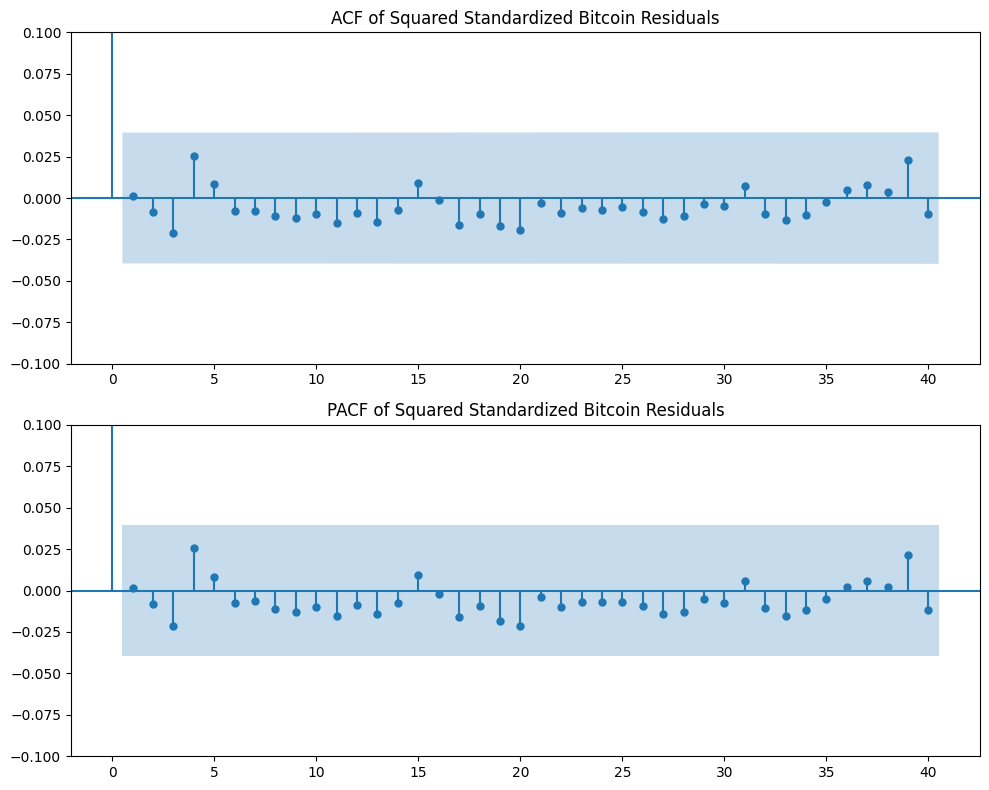

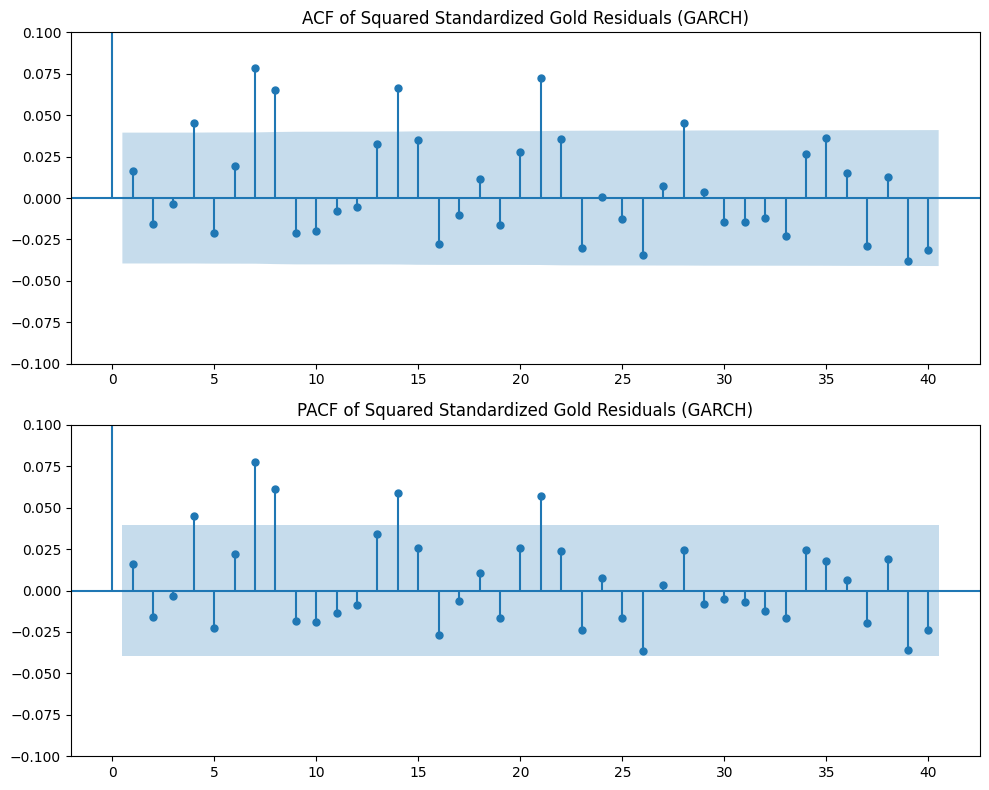

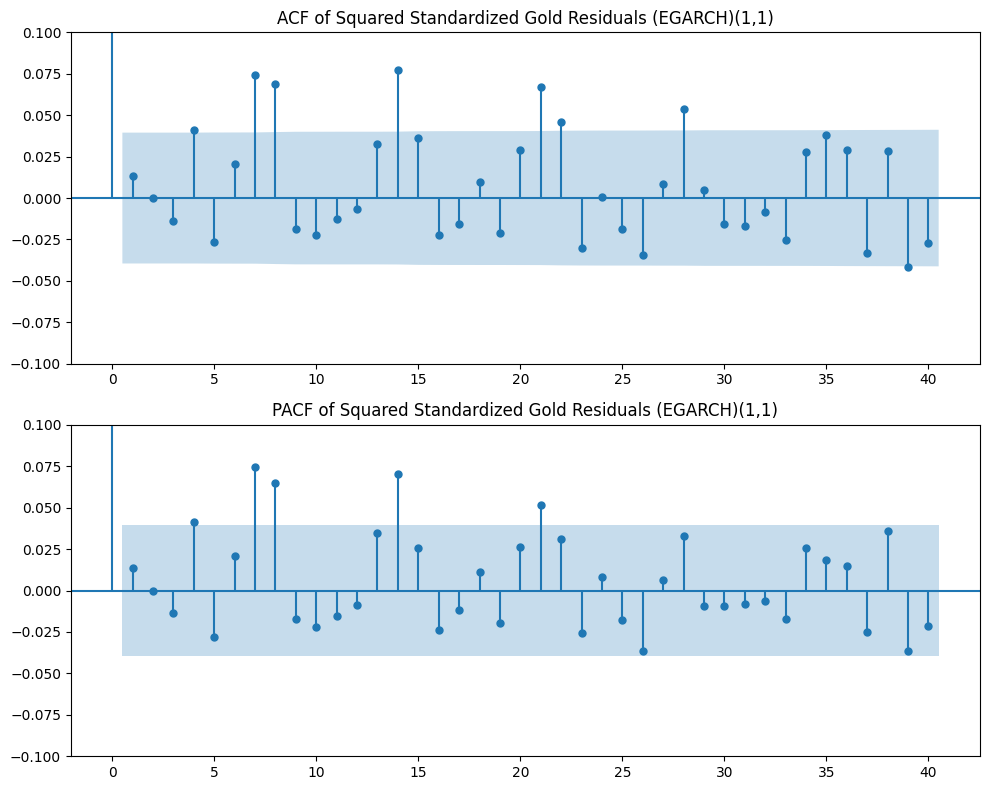

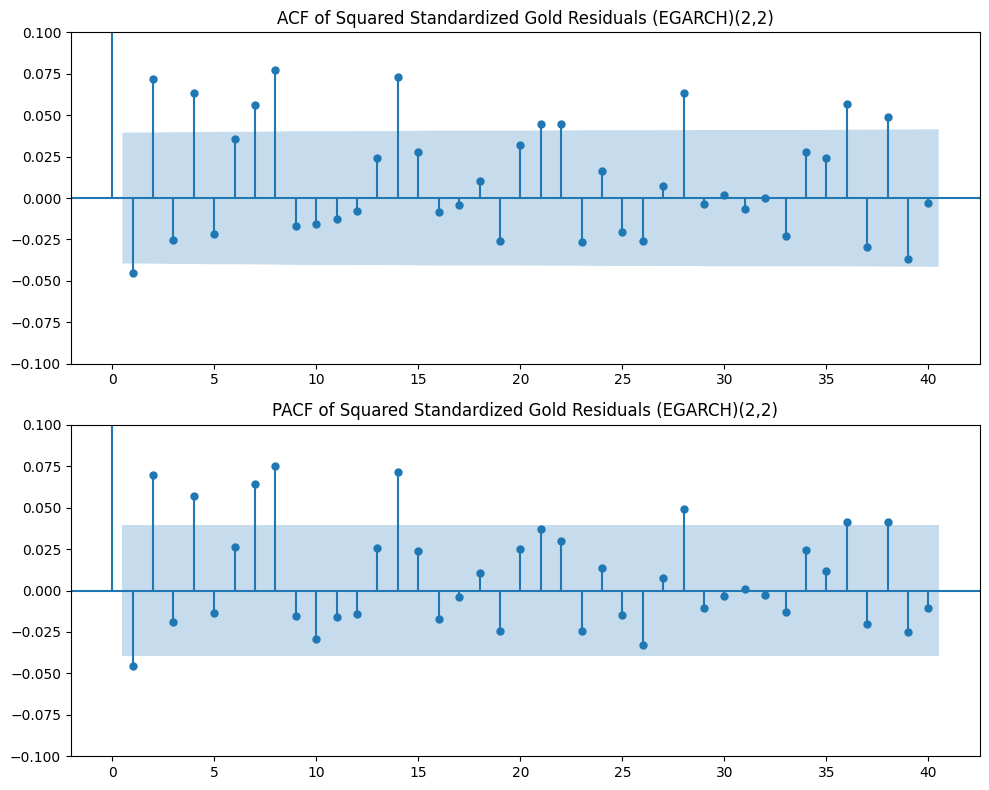

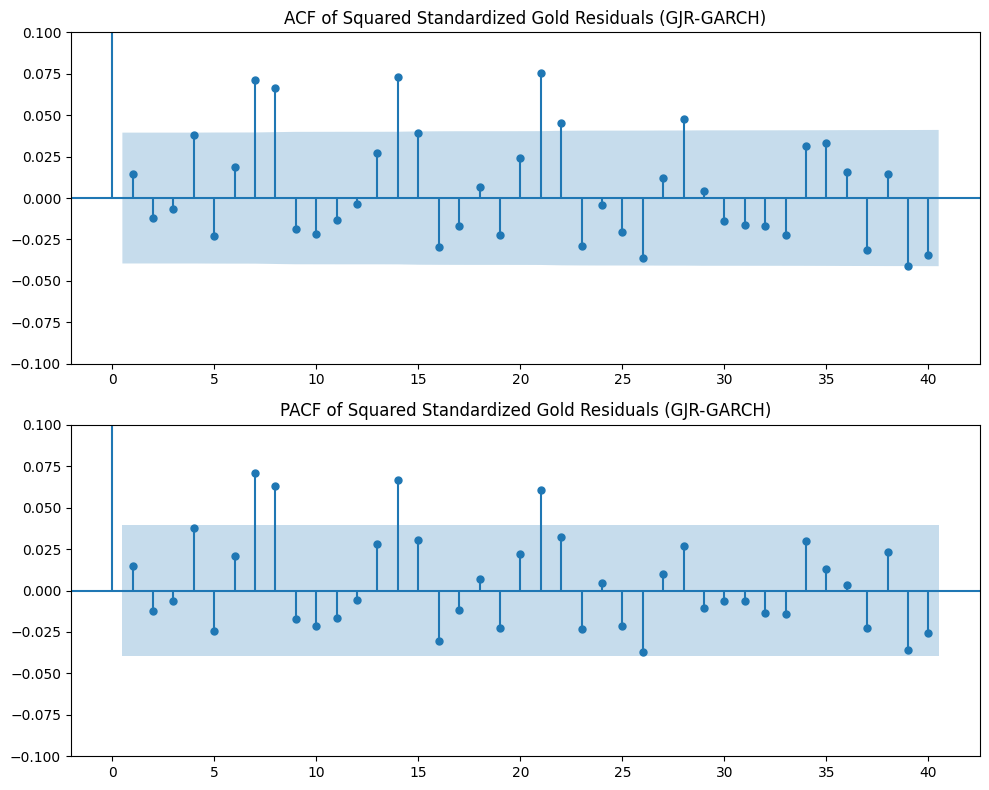

In [ ]:
# Get the standardized residuals
btc75_std_resid = res75_garch_btc.std_resid
gold75_std_resid = res75_garch_gold.std_resid

# Square the standardized residuals
btc75_std_resid_sq = btc75_std_resid**2
gold75_std_resid_sq = gold75_std_resid**2

# Plot ACF and PACF for squared standardized Bitcoin residuals
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(btc75_std_resid_sq.dropna(), ax=axes[0], lags=40)
plot_pacf(btc75_std_resid_sq.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Bitcoin Residuals')
axes[1].set_title('PACF of Squared Standardized Bitcoin Residuals')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for squared standardized Gold residuals (GARCH)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold75_std_resid_sq.dropna(), ax=axes[0], lags=40)
plot_pacf(gold75_std_resid_sq.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (GARCH)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (GARCH)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

#1 - for 1,1 GARCH and 2- for 2,2 GARCH

# Get standardized residuals for EGARCH and GJR-GARCH Gold models
gold75_std_resid_egarch1 = res75_egarch_gold1.std_resid
gold75_std_resid_egarch2 = res75_egarch_gold2.std_resid
gold75_std_resid_gjr_garch = res75_gjr_garch_gold.std_resid

# Square the standardized residuals for EGARCH and GJR-GARCH Gold models
gold75_std_resid_sq_egarch1 = gold75_std_resid_egarch1**2
gold75_std_resid_sq_egarch2 = gold75_std_resid_egarch2**2
gold75_std_resid_sq_gjr_garch = gold75_std_resid_gjr_garch**2

# Plot ACF and PACF for squared standardized Gold residuals (EGARCH)(1,1)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold75_std_resid_sq_egarch1.dropna(), ax=axes[0], lags=40)
plot_pacf(gold75_std_resid_sq_egarch1.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (EGARCH)(1,1)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (EGARCH)(1,1)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for squared standardized Gold residuals (EGARCH)(2,2)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold75_std_resid_sq_egarch2.dropna(), ax=axes[0], lags=40)
plot_pacf(gold75_std_resid_sq_egarch2.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (EGARCH)(2,2)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (EGARCH)(2,2)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for squared standardized Gold residuals (GJR-GARCH)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold75_std_resid_sq_gjr_garch.dropna(), ax=axes[0], lags=40)
plot_pacf(gold75_std_resid_sq_gjr_garch.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (GJR-GARCH)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (GJR-GARCH)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()


In [ ]:
# @title
from statsmodels.stats.stattools import jarque_bera

# Perform Jarque-Bera test on standardized Bitcoin residuals
jb75_btc = jarque_bera(btc75_std_resid.dropna())

print("--- Jarque-Bera Test: Standardized Bitcoin Residuals ---")
print(f"JB Statistic: {jb75_btc[0]:.6f}")
print(f"p-value : {jb75_btc[1]:.6f}")
print(f"Skewness : {jb75_btc[2]:.6f}")
print(f"Kurtosis : {jb75_btc[3]:.6f}")
print("→ Normal Distribution ✅" if jb75_btc[1] > 0.05 else "→ Non-normal Distribution ❌")


# Perform Jarque-Bera test on standardized Gold residuals
jb75_gold = jarque_bera(gold_std_resid.dropna())

print("\n--- Jarque-Bera Test: Standardized Gold Residuals ---")
print(f"JB Statistic: {jb75_gold[0]:.6f}")
print(f"p-value : {jb75_gold[1]:.6f}")
print(f"Skewness : {jb75_gold[2]:.6f}")
print(f"Kurtosis : {jb75_gold[3]:.6f}")
print("→ Normal Distribution ✅" if jb75_gold[1] > 0.05 else "→ Non-normal Distribution ❌")

--- Jarque-Bera Test: Standardized Bitcoin Residuals ---
JB Statistic: 28013.286520
p-value : 0.000000
Skewness : -0.821754
Kurtosis : 19.433042
→ Non-normal Distribution ❌

--- Jarque-Bera Test: Standardized Gold Residuals ---
JB Statistic: 3631.741022
p-value : 0.000000
Skewness : -0.315426
Kurtosis : 9.123598
→ Non-normal Distribution ❌


In [ ]:
# 1. Set the forecast horizon (if not already set)
horizon75_len = len(test75_data)

# 2. Run the simulations for Bitcoin
fc75_btc = res75_garch_btc.forecast(horizon=horizon_len, method='simulation', simulations=1000)

# 3. Get the *average* variance across all 1000 simulations
btc75_volatility_forecast = fc75_btc.variance.mean(axis=1)

# 4. Rescale
btc75_volatility_forecast = btc75_volatility_forecast * (1/100)**2

print("Bitcoin Volatility Forecast (GARCH):")
display(btc75_volatility_forecast)

Bitcoin Volatility Forecast (GARCH):


,0
822,0.002506


In [ ]:

horizon75_len = len(test75_data)

# 2. Run the simulations for Gold using the stable GJR-GARCH model
fc75_gold_gjr = res75_gjr_garch_gold.forecast(horizon=horizon_len, method='simulation', simulations=1000)

# 3. Get the *average* variance across all 1000 simulations
gold75_vol_forecast_gjr = fc75_gold_gjr.variance.mean(axis=1)

# 4. Rescale
gold75_vol_forecast_gjr = gold75_vol_forecast_gjr * (1/100)**2

print("Gold Volatility Forecast (GJR-GARCH):")
display(gold75_vol_forecast_gjr)

Gold Volatility Forecast (GJR-GARCH):


,0
822,0.000186


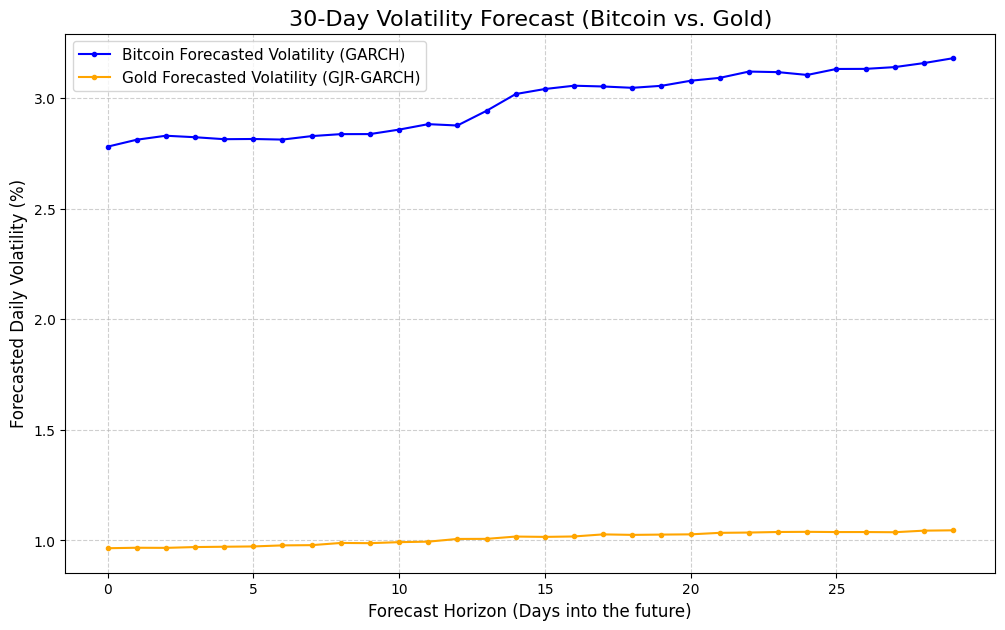

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SET FORECAST HORIZON ---
horizon75_len = len(test75_data)

# --- 2. RUN BITCOIN FORECAST (GARCH) ---
# We use axis=0 to average across the 1000 simulations
fc75_btc = res75_garch_btc.forecast(horizon=horizon75_len, method='simulation', simulations=1000)
btc75_vol_forecast_series = fc75_btc.variance.mean(axis=0)

# --- 3. RUN GOLD FORECAST (GJR-GARCH) ---
# We use axis=0 to average across the 1000 simulations
fc75_gold_gjr = res75_gjr_garch_gold.forecast(horizon=horizon75_len, method='simulation', simulations=1000)
gold75_vol_forecast_series = fc75_gold_gjr.variance.mean(axis=0)

# --- 4. RESCALE AND CONVERT TO % VOLATILITY ---
# Rescale the variance from (return*100)^2 back to return^2
btc75_variance_rescaled = btc75_vol_forecast_series * (1/100)**2
gold75_variance_rescaled = gold75_vol_forecast_series * (1/100)**2

# Convert variance to % volatility (sqrt * 100)
btc75_vol_pct = np.sqrt(btc75_variance_rescaled) * 100
gold75_vol_pct = np.sqrt(gold75_variance_rescaled) * 100

# --- 5. CREATE THE FINAL 30-DAY PLOT ---
days75_to_plot = 30

plt.figure(figsize=(12, 7))

# Plot the first 30 days
# We use .values to plot against a 0-29 index
plt.plot(btc75_vol_pct.values[:days75_to_plot], label='Bitcoin Forecasted Volatility (GARCH)', color='blue', marker='.')
plt.plot(gold75_vol_pct.values[:days75_to_plot], label='Gold Forecasted Volatility (GJR-GARCH)', color='orange', marker='.')

# Add Labels and Title
plt.title('30-Day Volatility Forecast (Bitcoin vs. Gold)', fontsize=16)
plt.xlabel('Forecast Horizon (Days into the future)', fontsize=12)
plt.ylabel('Forecasted Daily Volatility (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(0, days75_to_plot, 5)) # Make the x-axis labels cleaner

plt.show()

In [ ]:
# Set the number of days you want to display
days75_to_display = 30

# --- Display the first 30 data points ---

print("--- Bitcoin Forecasted Daily Volatility (%) [First 30 Days] ---")
# We use .iloc[:days_to_display] to get the first 30
# We convert to a DataFrame for nicer printing
display(pd.DataFrame(btc75_vol_pct.iloc[:days75_to_display], columns=['Forecasted Volatility (%)']))

print("\n--- Gold Forecasted Daily Volatility (%) [First 30 Days] ---")
display(pd.DataFrame(gold75_vol_pct.iloc[:days75_to_display], columns=['Forecasted Volatility (%)']))

--- Bitcoin Forecasted Daily Volatility (%) [First 30 Days] ---


,Forecasted Volatility (%)
h.001,2.779442
h.002,2.810865
h.003,2.828886
h.004,2.822177
h.005,2.813283
h.006,2.814202
h.007,2.811507
h.008,2.827255
h.009,2.836127
h.010,2.836379



--- Gold Forecasted Daily Volatility (%) [First 30 Days] ---


,Forecasted Volatility (%)
h.001,0.964953
h.002,0.967070
h.003,0.966534
h.004,0.970213
h.005,0.971661
h.006,0.973012
h.007,0.977759
h.008,0.978821
h.009,0.988714
h.010,0.987794


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# --- 1. SET PARAMETERS ---
data75_to_use = merged['Bitcoin_logret'].values.reshape(-1, 1)
window_size = 30

# --- 2. SCALE THE DATA ---
# ⭐ FIX: Use scaler75.fit_transform
scaler75 = MinMaxScaler(feature_range=(0, 1))
scaled75_data = scaler75.fit_transform(data75_to_use)

# --- 3. CREATE SEQUENCES (X, y) ---
X = []
y = []

for i in range(window_size, len(scaled75_data)):
    X.append(scaled75_data[i-window_size:i, 0])
    y.append(scaled75_data[i, 0])

X, y = np.array(X), np.array(y)

# --- 4. SPLIT INTO TRAINING (75%) AND TESTING (25%) ---
train75_size = int(len(X) * 0.75)
test75_size = len(X) - train75_size

X75_train, X75_test = X[0:train75_size], X[train75_size:len(X)]
y75_train, y75_test = y[0:train75_size], y[train75_size:len(y)]

# --- 5. RESHAPE FOR LSTM [samples, timesteps, features] ---
# ⭐ FIX: Use window_size (or X75_train.shape[1])
X75_train = np.reshape(X75_train, (X75_train.shape[0], window_size, 1))
X75_test = np.reshape(X75_test, (X75_test.shape[0], window_size, 1))

# --- 6. PRINT SHAPES TO CONFIRM ---
# ⭐ FIX: Print the new 75:25 variables
print("--- Data Preparation Complete (75:25 Split) ---")
print(f"Window size (timesteps): {window_size}")
print(f"X_train shape: {X75_train.shape}")
print(f"y_train shape: {y75_train.shape}")
print(f"X_test shape: {X75_test.shape}")
print(f"y_test shape: {y75_test.shape}")


--- Data Preparation Complete (75:25 Split) ---
Window size (timesteps): 30
X_train shape: (2442, 30, 1)
y_train shape: (2442,)
X_test shape: (815, 30, 1)
y_test shape: (815,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping # Import EarlyStopping

# --- 1. BUILD THE LSTM MODEL ---

model75 = Sequential()

# Layer 1: LSTM layer
# ⭐ FIX: Use window_size (which was 30) for the input shape
model75.add(LSTM(units=50, return_sequences=True, input_shape=(window_size, 1)))
model75.add(Dropout(0.2)) # Dropout helps prevent overfitting

# Layer 2: Another LSTM layer
model75.add(LSTM(units=50, return_sequences=False)) # False because it's the last LSTM layer
model75.add(Dropout(0.2))

# Layer 3: The Output Layer
model75.add(Dense(units=1))

# --- 2. COMPILE THE MODEL ---
model75.compile(optimizer='adam', loss='mean_squared_error')

# --- 3. TRAIN THE MODEL ("fit" the data) ---

# ⭐ FIX: Add EarlyStopping, just like in your senior's code
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("\n--- Starting Model Training (75:25 Split) ---")

history = model75.fit(
    X75_train,  # ⭐ FIX: Use X75_train
    y75_train,  # ⭐ FIX: Use y75_train
    epochs=50,
    batch_size=32,
    validation_data=(X75_test, y75_test), # ⭐ FIX: Use X75_test, y75_test
    callbacks=[es], # Add the callback
    verbose=1
)

print("--- Model Training Complete ---")

# --- 4. DISPLAY THE MODEL STRUCTURE ---
model75.summary()


--- Starting Model Training (75:25 Split) ---
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - loss: 0.0766 - val_loss: 0.0013
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0080 - val_loss: 0.0016
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0077 - val_loss: 0.0013
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0063 - val_loss: 0.0013
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0066 - val_loss: 0.0016
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0058 - val_loss: 0.0013
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0060 - val_loss: 0.0013
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.0055 - val_loss: 0.0015
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0055 - val_loss: 0.0014
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0064 - val_loss: 0.0016
Epoch 11/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0055 - val_loss: 0.0013
Epoch 12/50
77

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step
Test RMSE (75:25 Split): 0.025797


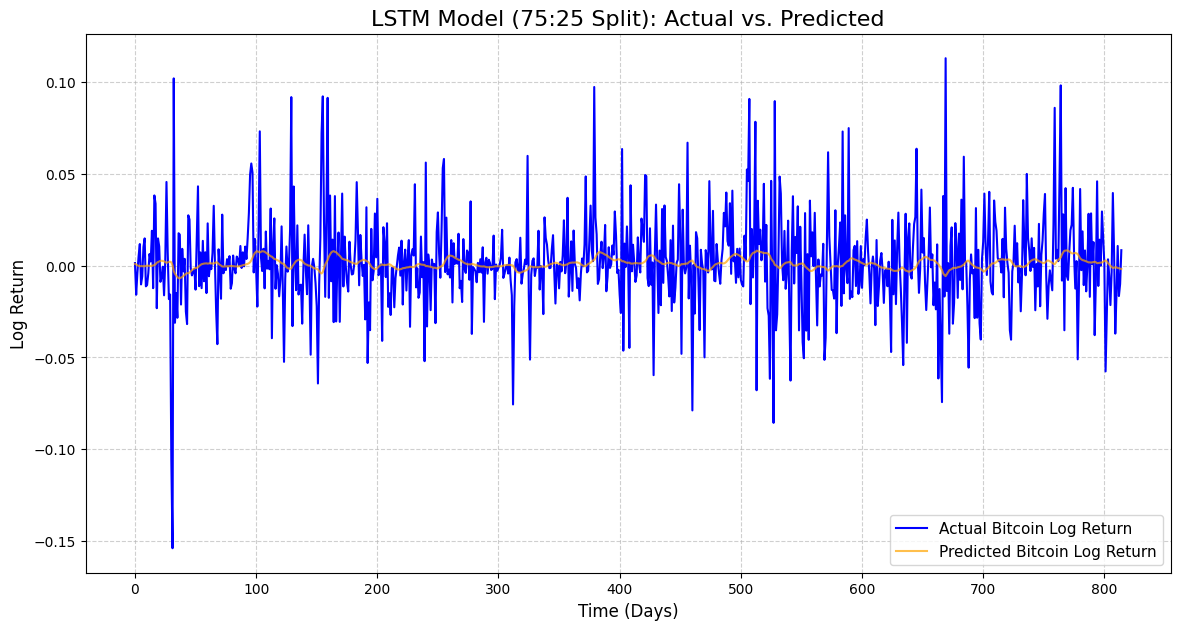

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# --- 1. MAKE PREDICTIONS ---
# ⭐ FIX: Use your new 75:25 model and test set
predicted_scaled = model75.predict(X75_test)

# --- 2. UN-SCALE THE DATA ---
# ⭐ FIX: Use your new scaler75 object

# Un-scale the predictions
predictions = scaler75.inverse_transform(predicted_scaled)

# Un-scale the *actual* values so we can compare
# ⭐ FIX: Use scaler75 and y75_test
actual_values = scaler75.inverse_transform(y75_test.reshape(-1, 1))

# --- 3. CALCULATE ERROR (RMSE) ---
rmse = np.sqrt(mean_squared_error(actual_values, predictions))
print(f'Test RMSE (75:25 Split): {rmse:.6f}')

# --- 4. PLOT THE RESULTS ---
plt.figure(figsize=(14, 7))
plt.plot(actual_values, color='blue', label='Actual Bitcoin Log Return')
plt.plot(predictions, color='orange', label='Predicted Bitcoin Log Return', alpha=0.7)
# ⭐ FIX: Updated title
plt.title('LSTM Model (75:25 Split): Actual vs. Predicted', fontsize=16)
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Log Return', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- Data Shapes (75:25 Split) ---
X_train: (2442, 30, 1)
X_test: (815, 30, 1)

--- Starting Model Training (75:25 Split) ---
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - loss: 0.0108 - val_loss: 0.0029
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0011 - val_loss: 0.0018
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 9.8944e-04 - val_loss: 0.0011
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 8.0214e-04 - val_loss: 0.0010
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 8.1402e-04 - val_loss: 7.2022e-04
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 7.3722e-04 - val_loss: 5.7901e-04
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 7.2406e-04 - val_loss: 7.5758e-04
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 6.4861e-04 - val_loss: 0.0010
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 6.0339e-04 - val_loss: 5.9371e-04
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 5.758

,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,1178.88,3393513.81,1842.15,24.32
1,Test,1821.08,6477655.40,2545.12,4.33


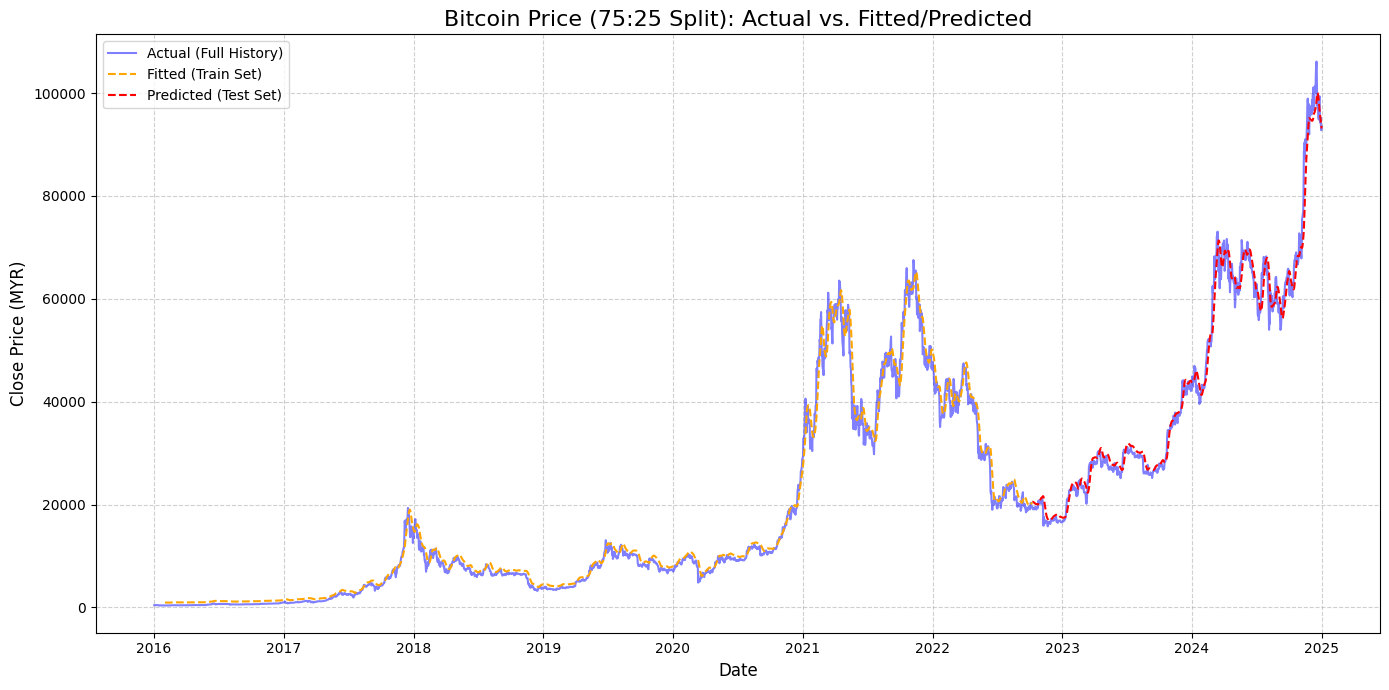

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. SET UP DATA & PARAMETERS ---
df = merged.copy()
close_col = 'Bitcoin' # <-- Changed to use the 'Bitcoin' price column
date_col = 'Date'
window_size = 30 # This is the 'adaptive_lookback'

# Ensure date column is datetime
df[date_col] = pd.to_datetime(df[date_col])

# --- 2. SCALING & DATA PREPARATION ---
data_to_use = df[close_col].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_to_use)

# --- 3. CREATE SEQUENCES ---
def make_sequences(data, window_size):
    X, y = [], []
    # ⭐ FIX: Corrected indentation on the loop
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = make_sequences(scaled_data, window_size)

# --- 4. TRAIN / TEST SPLIT (75% Train, 25% Test) ---
# ⭐ CHANGE: Updated to 75:25 split
train_split_idx = int(len(X) * 0.75)

X_tr, y_tr = X[:train_split_idx], y[:train_split_idx]
X_test, y_test = X[train_split_idx:], y[train_split_idx:]

# --- 5. RESHAPE FOR LSTM [samples, timesteps, features] ---
X_tr = np.reshape(X_tr, (X_tr.shape[0], X_tr.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# ⭐ CHANGE: Updated print statement
print("--- Data Shapes (75:25 Split) ---")
print(f"X_train: {X_tr.shape}")
print(f"X_test: {X_test.shape}")

# --- 6. BUILD & TRAIN MODEL (from your senior's code) ---
tf.random.set_seed(42)
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

# Use EarlyStopping, monitoring the test set loss
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("\n--- Starting Model Training (75:25 Split) ---")
history = model.fit(
    X_tr, y_tr,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test), # Use test set for validation
    callbacks=[es],
    verbose=1
)
print("--- Model Training Complete ---")

# --- 7. EVALUATION & METRICS ---
def inverse_and_metrics(y_true_scaled, y_pred_scaled, scaler_obj):
    y_true = scaler_obj.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler_obj.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

# Get predictions (scaled)
y_pred_tr_skala = model.predict(X_tr, verbose=0).flatten()
y_pred_test_skala = model.predict(X_test, verbose=0).flatten()

# Get metrics (un-scaled)
y_true_tr, y_pred_tr, mae_tr, mse_tr, rmse_tr, mape_tr = inverse_and_metrics(y_tr, y_pred_tr_skala, scaler)
y_true_test, y_pred_test, mae_te, mse_te, rmse_te, mape_te = inverse_and_metrics(y_test, y_pred_test_skala, scaler)

# Build metrics table (Train/Test only)
metrics_df = pd.DataFrame({
    "Set": ["Train", "Test"],
    "MAE": [mae_tr, mae_te],
    "MSE": [mse_tr, mse_te],
    "RMSE": [rmse_tr, rmse_te],
    "MAPE(%)": [mape_tr, mape_te]
})

print("\n=== Performance Metrics (75:25 Split) ===")
display(metrics_df.round(2))

# --- 8. PLOTTING (Full History Plot) ---

# Get the correct dates for each set
date_index = df[date_col].iloc[window_size:]
train_dates = date_index.iloc[:train_split_idx]
test_dates = date_index.iloc[train_split_idx:]

plt.figure(figsize=(14, 7))

# Plot 1: Full History
plt.plot(df[date_col], df[close_col], label="Actual (Full History)", color='blue', alpha=0.5)

# Plot 2: Fitted (Train Set)
plt.plot(train_dates, y_pred_tr, label="Fitted (Train Set)", color='orange', linestyle='--')

# Plot 3: Predicted (Test Set)
plt.plot(test_dates, y_pred_test, label="Predicted (Test Set)", color='red', linestyle='--')

plt.title(f"{close_col} Price (75:25 Split): Actual vs. Fitted/Predicted", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Close Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


--- Data Shapes (Multivariate 75:25 Split) ---
X_train: (2442, 30, 2)
X_test:  (815, 30, 2)

--- Starting Multivariate Model Training (75:25 Split) ---
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 57s 40ms/step - loss: 0.0104 - val_loss: 9.5323e-04
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0010 - val_loss: 9.1090e-04
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 9.0030e-04 - val_loss: 0.0011
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 7.5470e-04 - val_loss: 7.9077e-04
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 7.9068e-04 - val_loss: 0.0015
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 7.2507e-04 - val_loss: 7.4851e-04
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 6.9948e-04 - val_loss: 0.0010
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 6.1990e-04 - val_loss: 0.0025
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s

,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,1065.88,3417333.04,1848.60,9.14
1,Test,1766.38,5288643.15,2299.71,4.49


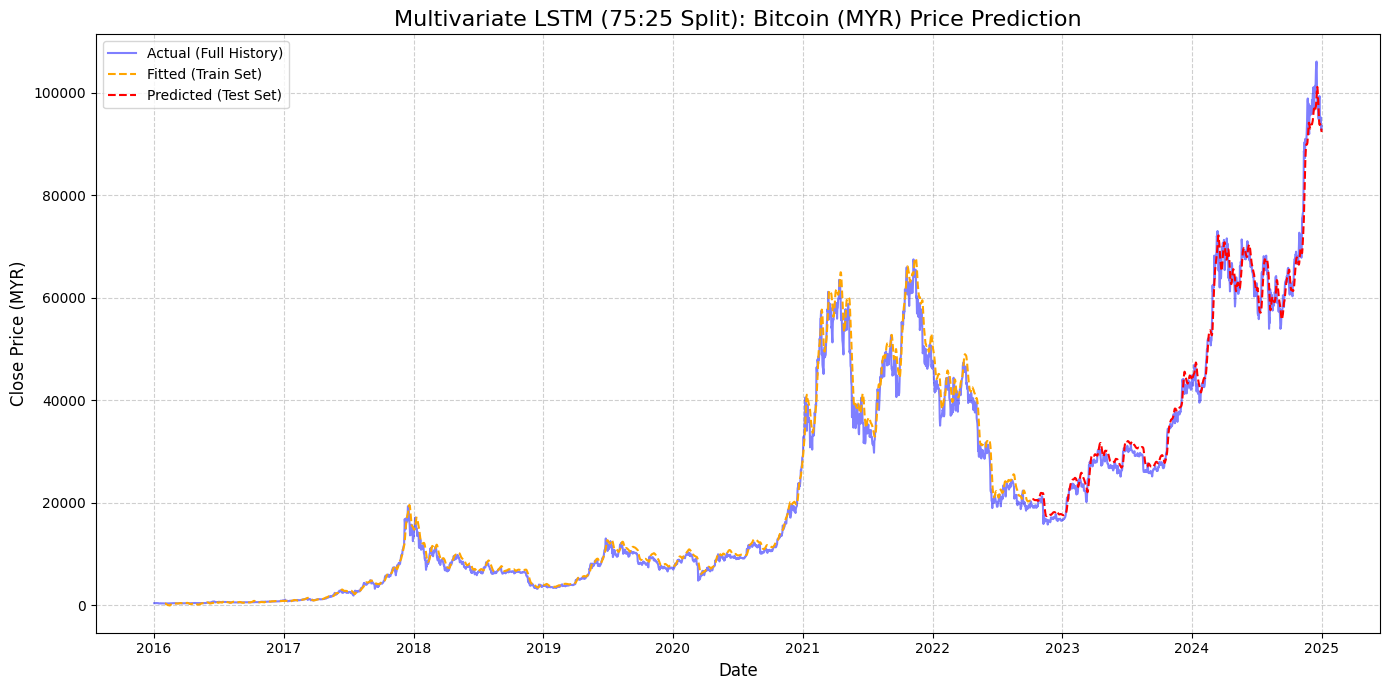

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# --- 3. SET UP FOR MULTIVARIATE LSTM ---
df_75 = merged.copy() # Use a new df variable
feature_cols_75 = ['Bitcoin', 'Gold']
target_col_75 = 'Bitcoin'
date_col_75 = 'Date'
window_size_75 = 30

# --- 4. SCALING ---
data_to_use_75 = df_75[feature_cols_75].values
scaler_75 = MinMaxScaler(feature_range=(0, 1)) # Renamed
scaled_data_75 = scaler_75.fit_transform(data_to_use_75) # Renamed

# --- 5. CREATE SEQUENCES (Multivariate) ---
def make_sequences_multi_75(data, window_size): # Renamed
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_75, y_75 = make_sequences_multi_75(scaled_data_75, window_size_75) # Renamed

# --- 6. TRAIN / TEST SPLIT (75% Train, 25% Test) ---
train_split_idx_75 = int(len(X_75) * 0.75) # Renamed
X_tr_75, y_tr_75 = X_75[:train_split_idx_75], y_75[:train_split_idx_75] # Renamed
X_test_75, y_test_75 = X_75[train_split_idx_75:], y_75[train_split_idx_75:] # Renamed

# --- 7. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features_75 = len(feature_cols_75) # Renamed
print("\n--- Data Shapes (Multivariate 75:25 Split) ---")
print(f"X_train: {X_tr_75.shape}") # Renamed
print(f"X_test:  {X_test_75.shape}") # Renamed

# --- 8. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model_75 = Sequential([ # Renamed
    LSTM(64, return_sequences=True, input_shape=(window_size_75, n_features_75)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model_75.compile(optimizer="adam", loss="mse") # Renamed
es_75 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True) # Renamed

print("\n--- Starting Multivariate Model Training (75:25 Split) ---")
history_75 = model_75.fit( # Renamed
    X_tr_75, y_tr_75, # Renamed
    epochs=50,
    batch_size=32,
    validation_data=(X_test_75, y_test_75), # Renamed
    callbacks=[es_75], # Renamed
    verbose=1
)
print("--- Model Training Complete ---")

# --- 9. EVALUATION & METRICS (Multivariate) ---
def inverse_and_metrics_multi_75(y_true_scaled, y_pred_scaled, scaler_obj_75): # Renamed
    n_features = scaler_obj_75.n_features_in_

    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 0] = y_pred_scaled.flatten()
    y_pred = scaler_obj_75.inverse_transform(pred_combined)[:, 0]

    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 0] = y_true_scaled.flatten()
    y_true = scaler_obj_75.inverse_transform(true_combined)[:, 0]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala_75 = model_75.predict(X_tr_75, verbose=0).flatten() # Renamed
y_pred_test_skala_75 = model_75.predict(X_test_75, verbose=0).flatten() # Renamed

y_true_tr_75, y_pred_tr_75, mae_tr_75, mse_tr_75, rmse_tr_75, mape_tr_75 = inverse_and_metrics_multi_75(y_tr_75, y_pred_tr_skala_75, scaler_75) # Renamed
y_true_test_75, y_pred_test_75, mae_te_75, mse_te_75, rmse_te_75, mape_te_75 = inverse_and_metrics_multi_75(y_test_75, y_pred_test_skala_75, scaler_75) # Renamed

metrics_df_75 = pd.DataFrame({ # Renamed
    "Set": ["Train", "Test"],
    "MAE": [mae_tr_75, mae_te_75], # Renamed
    "MSE": [mse_tr_75, mse_te_75], # Renamed
    "RMSE": [rmse_tr_75, rmse_te_75], # Renamed
    "MAPE(%)": [mape_tr_75, mape_te_75] # Renamed
})

print("\n=== Ringkasan Metrik (Multivariate 75:25 Split) ===")
display(metrics_df_75.round(2)) # Renamed

# --- 10. PLOTTING (Full History Plot) ---
date_index_75 = df_75[date_col_75].iloc[window_size_75:] # Renamed
train_dates_75 = date_index_75.iloc[:train_split_idx_75] # Renamed
test_dates_75 = date_index_75.iloc[train_split_idx_75:] # Renamed

plt.figure(figsize=(14, 7))
plt.plot(df_75[date_col_75], df_75[target_col_75], label="Actual (Full History)", color='blue', alpha=0.5) # Renamed
plt.plot(train_dates_75, y_pred_tr_75, label="Fitted (Train Set)", color='orange', linestyle='--') # Renamed
plt.plot(test_dates_75, y_pred_test_75, label="Predicted (Test Set)", color='red', linestyle='--') # Renamed
plt.title(f"Multivariate LSTM (75:25 Split): Bitcoin (MYR) Price Prediction", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Close Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


--- Data Shapes (Multivariate Gold 75:25 Split) ---
X_train: (2442, 30, 2)
X_test:  (815, 30, 2)

--- Starting Multivariate Model Training (Predicting Gold) ---
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.0136 - val_loss: 0.0065
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0013 - val_loss: 0.0063
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0011 - val_loss: 0.0055
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0010 - val_loss: 0.0082
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 9.5788e-04 - val_loss: 0.0036
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 8.0769e-04 - val_loss: 0.0047
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 8.7367e-04 - val_loss: 0.0037
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 7.0838e-04 - val_loss: 0.0059
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 6.4867e-04 - val_loss: 0.0070
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step 

,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,79.26,11517.91,107.32,1.24
1,Test,354.27,209071.24,457.24,3.38


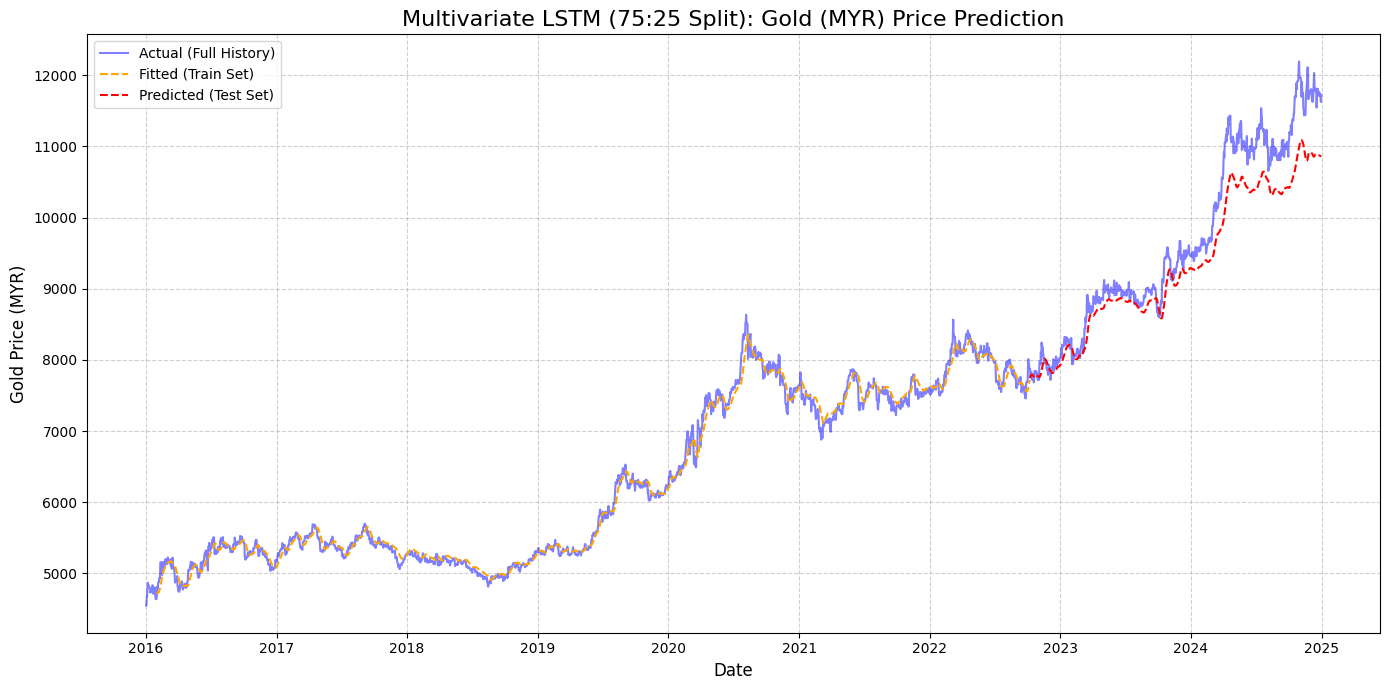

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# --- 3. SET UP FOR MULTIVARIATE LSTM (Predicting Gold) ---
df_gold_75 = merged.copy()
feature_cols_gold_75 = ['Bitcoin', 'Gold'] # <-- Inputs
target_col_gold_75 = 'Gold'               # <-- Output
date_col_gold_75 = 'Date'
window_size_gold_75 = 30

# --- 4. SCALING ---
data_to_use_gold_75 = df_gold_75[feature_cols_gold_75].values
scaler_gold_75 = MinMaxScaler(feature_range=(0, 1)) # New scaler
scaled_data_gold_75 = scaler_gold_75.fit_transform(data_to_use_gold_75)

# --- 5. CREATE SEQUENCES (Multivariate for Gold) ---
def make_sequences_multi_gold_75(data, window_size): # New function
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :]) # All features (BTC & Gold)
        y.append(data[i, 1])               # ⭐ CHANGE: Target is col 1 (Gold)
    return np.array(X), np.array(y)

X_gold_75, y_gold_75 = make_sequences_multi_gold_75(scaled_data_gold_75, window_size_gold_75)

# --- 6. TRAIN / TEST SPLIT (75% Train, 25% Test) ---
train_split_idx_gold_75 = int(len(X_gold_75) * 0.75)
X_tr_gold_75, y_tr_gold_75 = X_gold_75[:train_split_idx_gold_75], y_gold_75[:train_split_idx_gold_75]
X_test_gold_75, y_test_gold_75 = X_gold_75[train_split_idx_gold_75:], y_gold_75[train_split_idx_gold_75:]

# --- 7. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features_gold_75 = len(feature_cols_gold_75)
print("\n--- Data Shapes (Multivariate Gold 75:25 Split) ---")
print(f"X_train: {X_tr_gold_75.shape}")
print(f"X_test:  {X_test_gold_75.shape}")

# --- 8. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model_gold_75 = Sequential([ # New model
    LSTM(64, return_sequences=True, input_shape=(window_size_gold_75, n_features_gold_75)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model_gold_75.compile(optimizer="adam", loss="mse")
es_gold_75 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("\n--- Starting Multivariate Model Training (Predicting Gold) ---")
history_gold_75 = model_gold_75.fit(
    X_tr_gold_75, y_tr_gold_75,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_gold_75, y_test_gold_75),
    callbacks=[es_gold_75],
    verbose=1
)
print("--- Model Training Complete ---")

# --- 9. EVALUATION & METRICS (Multivariate for Gold) ---
def inverse_and_metrics_multi_gold_75(y_true_scaled, y_pred_scaled, scaler_obj_gold_75): # New function
    n_features = scaler_obj_gold_75.n_features_in_

    # ⭐ CHANGE: Put prediction in col 1 (Gold)
    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 1] = y_pred_scaled.flatten()
    y_pred = scaler_obj_gold_75.inverse_transform(pred_combined)[:, 1] # Get col 1

    # ⭐ CHANGE: Put actual in col 1 (Gold)
    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 1] = y_true_scaled.flatten()
    y_true = scaler_obj_gold_75.inverse_transform(true_combined)[:, 1] # Get col 1

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala_gold_75 = model_gold_75.predict(X_tr_gold_75, verbose=0).flatten()
y_pred_test_skala_gold_75 = model_gold_75.predict(X_test_gold_75, verbose=0).flatten()

y_true_tr_gold_75, y_pred_tr_gold_75, mae_tr_gold_75, mse_tr_gold_75, rmse_tr_gold_75, mape_tr_gold_75 = inverse_and_metrics_multi_gold_75(y_tr_gold_75, y_pred_tr_skala_gold_75, scaler_gold_75)
y_true_test_gold_75, y_pred_test_gold_75, mae_te_gold_75, mse_te_gold_75, rmse_te_gold_75, mape_te_gold_75 = inverse_and_metrics_multi_gold_75(y_test_gold_75, y_pred_test_skala_gold_75, scaler_gold_75)

metrics_df_gold_75 = pd.DataFrame({
    "Set": ["Train", "Test"],
    "MAE": [mae_tr_gold_75, mae_te_gold_75],
    "MSE": [mse_tr_gold_75, mse_te_gold_75],
    "RMSE": [rmse_tr_gold_75, rmse_te_gold_75],
    "MAPE(%)": [mape_tr_gold_75, mape_te_gold_75]
})

print("\n=== Ringkasan Metrik (Multivariate Gold 75:25 Split) ===")
display(metrics_df_gold_75.round(2))

# --- 10. PLOTTING (Full History Plot) ---
date_index_gold_75 = df_gold_75[date_col_gold_75].iloc[window_size_gold_75:]
train_dates_gold_75 = date_index_gold_75.iloc[:train_split_idx_gold_75]
test_dates_gold_75 = date_index_gold_75.iloc[train_split_idx_gold_75:]

plt.figure(figsize=(14, 7))
# ⭐ CHANGE: Plot the 'Gold' column as the actual
plt.plot(df_gold_75[date_col_gold_75], df_gold_75[target_col_gold_75], label="Actual (Full History)", color='blue', alpha=0.5)
plt.plot(train_dates_gold_75, y_pred_tr_gold_75, label="Fitted (Train Set)", color='orange', linestyle='--')
plt.plot(test_dates_gold_75, y_pred_test_gold_75, label="Predicted (Test Set)", color='red', linestyle='--')

# ⭐ CHANGE: Updated titles
plt.title(f"Multivariate LSTM (75:25 Split): Gold (MYR) Price Prediction", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Gold Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


--- Data Shapes (Multivariate Gold 75:25 Split) ---
X_train: (2443, 30, 2)
X_test:  (815, 30, 2)

--- Starting Multivariate Model Training (Predicting Gold) (75:25 Split) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0183 - val_loss: 0.0011
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 9.5072e-04 - val_loss: 0.0016
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 8.6128e-04 - val_loss: 0.0013
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 8.4551e-04 - val_loss: 0.0040
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 7.8155e-04 - val_loss: 0.0024
--- Model Training Complete ---

=== Ringkasan Metrik (Multivariate Gold 75:25 Split) ===


,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,90.30,14411.80,120.05,1.43
1,Test,181.96,64159.43,253.30,1.77


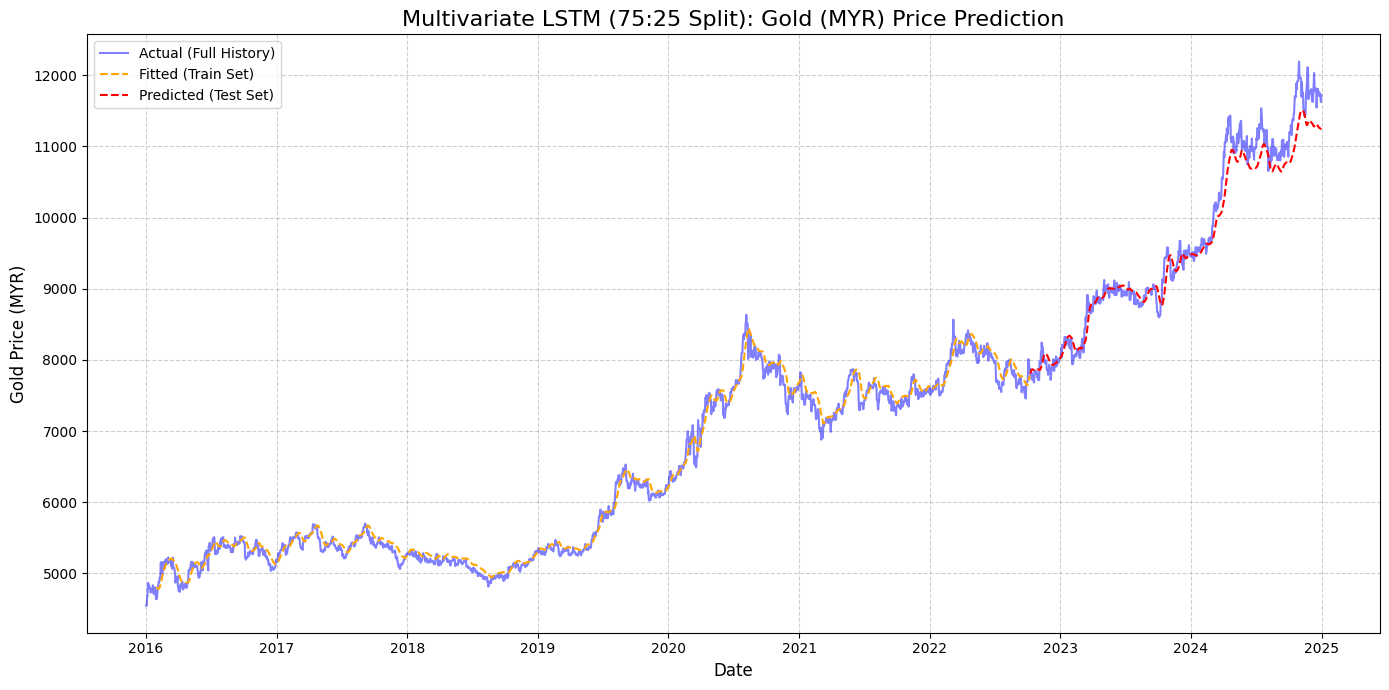

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- 3. SET UP FOR MULTIVARIATE LSTM (Predicting Gold) ---
df_gold_75 = merged.copy() # Renamed df (assuming merged_df is ready)
feature_cols_gold_75 = ['Bitcoin', 'Gold'] # <-- Inputs
target_col_gold_75 = 'Gold'               # <-- Output
date_col_gold_75 = 'Date'
window_size_gold_75 = 30

# --- 4. SCALING ---
data_to_use_gold_75 = df_gold_75[feature_cols_gold_75].values
scaler_gold_75 = MinMaxScaler(feature_range=(0, 1)) # Renamed scaler
scaled_data_gold_75 = scaler_gold_75.fit_transform(data_to_use_gold_75)

# --- 5. CREATE SEQUENCES (Multivariate for Gold) ---
def make_sequences_multi_gold_75(data, window_size): # New function
    X, y = [], []
    for i in range(window_size, len(data)):
        # ⭐ FIX: Corrected indentation
        X.append(data[i-window_size:i, :]) # All features (BTC & Gold)
        y.append(data[i, 1])               # Target is col 1 (Gold)
    return np.array(X), np.array(y)

X_gold_75, y_gold_75 = make_sequences_multi_gold_75(scaled_data_gold_75, window_size_gold_75) # Renamed

# --- 6. TRAIN / TEST SPLIT (75% Train, 25% Test) ---
# ⭐ CHANGE: Updated to 0.75 for 75:25 split
train_split_idx_gold_75 = int(len(X_gold_75) * 0.75)
X_tr_gold_75, y_tr_gold_75 = X_gold_75[:train_split_idx_gold_75], y_gold_75[:train_split_idx_gold_75] # Renamed
X_test_gold_75, y_test_gold_75 = X_gold_75[train_split_idx_gold_75:], y_gold_75[train_split_idx_gold_75:] # Renamed

# --- 7. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features_gold_75 = len(feature_cols_gold_75)
print("\n--- Data Shapes (Multivariate Gold 75:25 Split) ---") # Updated title
print(f"X_train: {X_tr_gold_75.shape}") # Renamed
print(f"X_test:  {X_test_gold_75.shape}") # Renamed

# --- 8. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model_gold_75 = Sequential([ # Renamed model
    LSTM(64, return_sequences=True, input_shape=(window_size_gold_75, n_features_gold_75)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model_gold_75.compile(optimizer="adam", loss="mse")
es_gold_75 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True) # Renamed

print("\n--- Starting Multivariate Model Training (Predicting Gold) (75:25 Split) ---") # Updated title
history_gold_75 = model_gold_75.fit( # Renamed
    X_tr_gold_75, y_tr_gold_75, # Renamed
    epochs=50,
    batch_size=32,
    validation_data=(X_test_gold_75, y_test_gold_75), # Renamed
    callbacks=[es_gold_75], # Renamed
    verbose=1
)
print("--- Model Training Complete ---")

# --- 9. EVALUATION & METRICS (Multivariate for Gold) ---
def inverse_and_metrics_multi_gold_75(y_true_scaled, y_pred_scaled, scaler_obj_gold_75): # New function
    n_features = scaler_obj_gold_75.n_features_in_

    # Put prediction in col 1 (Gold)
    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 1] = y_pred_scaled.flatten()
    y_pred = scaler_obj_gold_75.inverse_transform(pred_combined)[:, 1]

    # Put actual in col 1 (Gold)
    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 1] = y_true_scaled.flatten()
    y_true = scaler_obj_gold_75.inverse_transform(true_combined)[:, 1]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala_gold_75 = model_gold_75.predict(X_tr_gold_75, verbose=0).flatten() # Renamed
y_pred_test_skala_gold_75 = model_gold_75.predict(X_test_gold_75, verbose=0).flatten() # Renamed

y_true_tr_gold_75, y_pred_tr_gold_75, mae_tr_gold_75, mse_tr_gold_75, rmse_tr_gold_75, mape_tr_gold_75 = inverse_and_metrics_multi_gold_75(y_tr_gold_75, y_pred_tr_skala_gold_75, scaler_gold_75) # Renamed
y_true_test_gold_75, y_pred_test_gold_75, mae_te_gold_75, mse_te_gold_75, rmse_te_gold_75, mape_te_gold_75 = inverse_and_metrics_multi_gold_75(y_test_gold_75, y_pred_test_skala_gold_75, scaler_gold_75) # Renamed

metrics_df_gold_75 = pd.DataFrame({ # Renamed
    "Set": ["Train", "Test"],
    "MAE": [mae_tr_gold_75, mae_te_gold_75],
    "MSE": [mse_tr_gold_75, mse_te_gold_75],
    "RMSE": [rmse_tr_gold_75, rmse_te_gold_75],
    "MAPE(%)": [mape_tr_gold_75, mape_te_gold_75]
})

print("\n=== Ringkasan Metrik (Multivariate Gold 75:25 Split) ===") # Updated title
display(metrics_df_gold_75.round(2)) # Renamed

# --- 10. PLOTTING (Full History Plot) ---
date_index_gold_75 = df_gold_75[date_col_gold_75].iloc[window_size_gold_75:] # Renamed
train_dates_gold_75 = date_index_gold_75.iloc[:train_split_idx_gold_75] # Renamed
test_dates_gold_75 = date_index_gold_75.iloc[train_split_idx_gold_75:] # Renamed

plt.figure(figsize=(14, 7))
plt.plot(df_gold_75[date_col_gold_75], df_gold_75[target_col_gold_75], label="Actual (Full History)", color='blue', alpha=0.5) # Renamed
plt.plot(train_dates_gold_75, y_pred_tr_gold_75, label="Fitted (Train Set)", color='orange', linestyle='--') # Renamed
plt.plot(test_dates_gold_75, y_pred_test_gold_75, label="Predicted (Test Set)", color='red', linestyle='--') # Renamed

plt.title(f"Multivariate LSTM (75:25 Split): Gold (MYR) Price Prediction", fontsize=16) # Updated title
plt.xlabel("Date", fontsize=12)
plt.ylabel("Gold Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 80:20 Split

In [ ]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima

# --- 1. Split data (80:20 ratio) ---
# ⭐ CHANGE: Updated to 0.80 and renamed all variables
train_size_80 = int(len(merged) * 0.80)
train_data_80 = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[0:train_size_80]
test_data_80 = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[train_size_80:len(merged)]

print("--- 80:20 Split ---")
print("Training data size (80%):", len(train_data_80))
print("Testing data size (20%):", len(test_data_80))


--- 80:20 Split ---
Training data size (80%): 2629
Testing data size (20%): 658


In [ ]:
# --- 2. Fit auto_arima on Bitcoin (80% data) ---
# ⭐ CHANGE: Using train_data_80 and renamed model
model_bitcoin_80 = ARIMA(train_data_80['Bitcoin_logret']*100, order=(2, 0, 4), trend='c').fit()
print("Bitcoin ARIMA(2, 0, 4) Model Summary:")
print(model_bitcoin_80.summary())

# --- 3. Fit auto_arima on Gold (80% data) ---
# ⭐ CHANGE: Using train_data_80 and renamed model
model_gold_80 = ARIMA(train_data_80['Gold_logret']*100, order=(3, 0, 3), trend='c').fit()
print("\nGold ARIMA(3,0,3) Model Summary :")
print(model_gold_80.summary())

Bitcoin ARIMA(2, 0, 4) Model Summary:
                               SARIMAX Results                                
Dep. Variable:         Bitcoin_logret   No. Observations:                 2629
Model:                 ARIMA(2, 0, 4)   Log Likelihood               -7323.255
Date:                Thu, 20 Nov 2025   AIC                          14662.510
Time:                        02:01:22   BIC                          14709.505
Sample:                             0   HQIC                         14679.528
                               - 2629                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1468      0.079      1.849      0.064      -0.009       0.302
ar.L1          1.1782      0.006    189.845      0.000       1.166       1.190
ar.L2         

In [ ]:
# @title
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ==========================================
#    CONFIGURATION: AUTO GRID SEARCH
# ==========================================

# Define the maximum order you want to test
# You requested up to 5 (p=0..5, q=0..5)
max_p = 5
max_q = 5
d_value = 0  # Fixed at 0 for Log Returns

# --- AUTOMATICALLY GENERATE CANDIDATE LIST ---
# This creates [(0,0,0)... up to (5,0,5)] -> 36 combinations
grid_search_candidates = [
    (p, d_value, q)
    for p in range(0, max_p + 1)
    for q in range(0, max_q + 1)
]

print(f"Generated {len(grid_search_candidates)} models for grid search.")


# --- HELPER FUNCTION ---
def run_model_list(data, model_list, asset_name):
    results = []
    print(f"Running models for {asset_name}...")

    for param in model_list:
        try:
            # Fit ARIMA model (trend='c' adds intercept)
            model = ARIMA(data, order=param, trend='c')
            model_fit = model.fit()

            results.append({
                'Model': f"ARIMA{param}",
                'AIC': round(model_fit.aic, 2),
                'BIC': round(model_fit.bic, 2)
            })
        except:
            continue

    # Sort by AIC
    df = pd.DataFrame(results)
    df = df.sort_values(by='AIC', ascending=True)
    return df

# ==========================================
#        EXECUTION (SCALED DATA) - 80:20 SPLIT
# ==========================================
# IMPORTANT: Using 'train_data_80' from your image

# 1. Run Bitcoin List (Using train_data_80)
df_btc_80 = run_model_list(train_data_80['Bitcoin_logret'] * 100, grid_search_candidates, "Bitcoin (80:20)")

# 2. Run Gold List (Using train_data_80)
df_gold_80 = run_model_list(train_data_80['Gold_logret'] * 100, grid_search_candidates, "Gold (80:20)")


# --- PRINT RESULTS ---
print("\n" + "="*40)
print(" BITCOIN MODEL SELECTION (80:20 SPLIT)")
print("="*40)
print(df_btc_80) # Printing top 10 best models

print("\n" + "="*40)
print("   GOLD MODEL SELECTION (80:20 SPLIT)")
print("="*40)
print(df_gold_80) # Printing top 10 best models

Generated 36 models for grid search.
Running models for Bitcoin (80:20)...
Running models for Gold (80:20)...

 BITCOIN MODEL SELECTION (80:20 SPLIT)
             Model       AIC       BIC
16  ARIMA(2, 0, 4)  14662.51  14709.50
12  ARIMA(2, 0, 0)  14663.61  14687.10
2   ARIMA(0, 0, 2)  14663.63  14687.12
13  ARIMA(2, 0, 1)  14664.32  14693.70
19  ARIMA(3, 0, 1)  14664.44  14699.69
9   ARIMA(1, 0, 3)  14664.51  14699.76
14  ARIMA(2, 0, 2)  14664.63  14699.88
7   ARIMA(1, 0, 1)  14664.67  14688.17
8   ARIMA(1, 0, 2)  14664.70  14694.08
6   ARIMA(1, 0, 0)  14665.13  14682.75
1   ARIMA(0, 0, 1)  14665.46  14683.08
18  ARIMA(3, 0, 0)  14665.52  14694.89
3   ARIMA(0, 0, 3)  14665.62  14694.99
20  ARIMA(3, 0, 2)  14666.43  14707.55
25  ARIMA(4, 0, 1)  14666.43  14707.55
15  ARIMA(2, 0, 3)  14666.43  14707.55
10  ARIMA(1, 0, 4)  14666.44  14707.56
24  ARIMA(4, 0, 0)  14667.20  14702.44
4   ARIMA(0, 0, 4)  14667.21  14702.45
0   ARIMA(0, 0, 0)  14667.82  14679.57
5   ARIMA(0, 0, 5)  14668.17  1

In [ ]:
from arch import arch_model

# --- 1. Get residuals from your 80:20 auto_arima models ---
# ⭐ FIX: Use the _80 models
btc_residuals_80 = model_bitcoin_80.resid()
gold_residuals_80 = model_gold_80.resid()

# 2. Rescale the residuals
# (Note: You are not scaling here, just renaming.
# If you want to scale by 100, you'd do btc_residuals_80 * 100)
btc_resid_scaled_80 = btc_residuals_80
gold_resid_scaled_80 = gold_residuals_80

# --- 3. Fit GARCH(1,1) on Bitcoin's 80:20 Residuals ---
# ⭐ FIX: Use _80 variables
garch_btc_80 = arch_model(btc_resid_scaled_80,
                            mean='Zero',
                            vol='Garch', p=1, q=1,
                            dist='Normal') # You may want 't' dist later

res_garch_btc_80 = garch_btc_80.fit(disp='off')
# ⭐ FIX: Updated title
print("Bitcoin GARCH(1,1) on ARMA Residuals (80:20 Split):")
print(res_garch_btc_80.summary())

# --- 4. Fit GARCH(1,1) on Gold's 80:20 Residuals ---
# ⭐ FIX: Use _80 variables
garch_gold_80 = arch_model(gold_resid_scaled_80,
                             mean='Zero',
                             vol='Garch', p=1, q=1,
                             dist='Normal') # You may want 't' dist later

res_garch_gold_80 = garch_gold_80.fit(disp='off')
# ⭐ FIX: Updated title
print("\nGold GARCH(1,1) on MA Residuals (80:20 Split):")
print(res_garch_gold_80.summary())

ModuleNotFoundError: No module named 'arch'

In [ ]:
# --- 1. Get residuals from your 80:20 auto_arima models ---
# ⭐ FIX: Use the _80 models
btc_residuals_80 = model_bitcoin_80.resid()
gold_residuals_80 = model_gold_80.resid()

# 2. Rescale the residuals
# (Note: You are not scaling here, just renaming.
# If you want to scale by 100, you'd do btc_residuals_80 * 100)
btc_resid_scaled_80 = btc_residuals_80 * 100
gold_resid_scaled_80 = gold_residuals_80 * 100

# --- 3. Fit GARCH(1,1) on Bitcoin's 80:20 Residuals ---
# ⭐ FIX: Use _80 variables
garch_btc_80 = arch_model(btc_resid_scaled_80,
                            mean='Zero',
                            vol='Garch', p=1, q=1,
                            dist='Normal') # You may want 't' dist later

res_garch_btc_80 = garch_btc_80.fit(disp='off')
# ⭐ FIX: Updated title
print("Bitcoin GARCH(1,1) on ARMA Residuals (80:20 Split):")
print(res_garch_btc_80.summary())

# --- 4. Fit GARCH(1,1) on Gold's 80:20 Residuals ---
# ⭐ FIX: Use _80 variables
garch_gold_80 = arch_model(gold_resid_scaled_80,
                             mean='Zero',
                             vol='Garch', p=1, q=1,
                             dist='Normal') # You may want 't' dist later

res_garch_gold_80 = garch_gold_80.fit(disp='off')
# ⭐ FIX: Updated title
print("\nGold GARCH(1,1) on MA Residuals (80:20 Split):")
print(res_garch_gold_80.summary())

Bitcoin GARCH(1,1) on ARMA Residuals (80:20 Split):
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -7144.54
Distribution:                  Normal   AIC:                           14295.1
Method:            Maximum Likelihood   BIC:                           14312.7
                                        No. Observations:                 2629
Date:                Wed, Nov 05 2025   Df Residuals:                     2629
Time:                        12:32:13   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega       

In [ ]:
from arch import arch_model

# --- 1. Get residuals from your 80:20 auto_arima models ---
# ⭐ FIX: Use the _80 models
btc_residuals_80 = model_bitcoin_80.resid()
gold_residuals_80 = model_gold_80.resid()

# --- 2. Rescale the residuals ---
# ⭐ FIX: Renamed variables
btc_resid_scaled_80 = btc_residuals_80 * 100
gold_resid_scaled_80 = gold_residuals_80 * 100

# --- 3. Fit GARCH(1,1) on Bitcoin 80:20 Residuals ---
# ⭐ FIX: Renamed variables
garch_btc_80 = arch_model(btc_resid_scaled_80,
                            mean='Zero',
                            vol='Garch', p=1, q=1,
                            dist='t')

res_garch_btc_80 = garch_btc_80.fit(disp='off')
print("Bitcoin GARCH(1,1) on ARMA Residuals (80:20 Split, t-dist):")
print(res_garch_btc_80.summary())

# --- 4. Fit GARCH(1,1) on Gold 80:20 Residuals ---
# ⭐ FIX: Renamed variables
garch_gold_80 = arch_model(gold_resid_scaled_80,
                             mean='Zero',
                             vol='Garch', p=1, q=1,
                             dist='t')

res_garch_gold_80 = garch_gold_80.fit(disp='off')
print("\nGold GARCH(1,1) on MA Residuals (80:20 Split, t-dist):")
print(res_garch_gold_80.summary())

# --- 5. Fit EGARCH(1,1) on Gold 80:20 Residuals ---
# ⭐ FIX: Renamed variables
egarch_gold1_80 = arch_model(gold_resid_scaled_80,
                               mean='Zero',
                               vol='EGARCH', p=1, q=1,
                               dist='t')

res_egarch_gold1_80 = egarch_gold1_80.fit(disp='off')
print("\nGold EGARCH(1,1) on MA Residuals (80:20 Split, t-dist):")
print(res_egarch_gold1_80.summary())

# --- 6. Fit EGARCH(2,2) on Gold 80:20 Residuals ---
# ⭐ FIX: Renamed variables
egarch_gold2_80 = arch_model(gold_resid_scaled_80,
                               mean='Zero',
                               vol='EGARCH', p=2, q=2,
                               dist='t')

res_egarch_gold2_80 = egarch_gold2_80.fit(disp='off')
print("\nGold EGARCH(2,2) on MA Residuals (80:20 Split, t-dist):")
print(res_egarch_gold2_80.summary())

# --- 7. Fit GJR-GARCH(1,1) on Gold 80:20 Residuals ---
# ⭐ FIX: Renamed variables
gjr_garch_gold_80 = arch_model(gold_resid_scaled_80,
                                 mean='Zero',
                                 vol='GARCH', p=1, o=1, q=1, # o=1 for GJR-GARCH
                                 dist='t')

res_gjr_garch_gold_80 = gjr_garch_gold_80.fit(disp='off')
print("\nGold GJR-GARCH(1,1) on MA Residuals (80:20 Split, t-dist):")
print(res_gjr_garch_gold_80.summary())

Bitcoin GARCH(1,1) on ARMA Residuals (80:20 Split, t-dist):
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -6776.85
Distribution:      Standardized Student's t   AIC:                           13561.7
Method:                  Maximum Likelihood   BIC:                           13585.2
                                              No. Observations:                 2629
Date:                      Wed, Nov 05 2025   Df Residuals:                     2629
Time:                              12:57:13   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
-----------------------

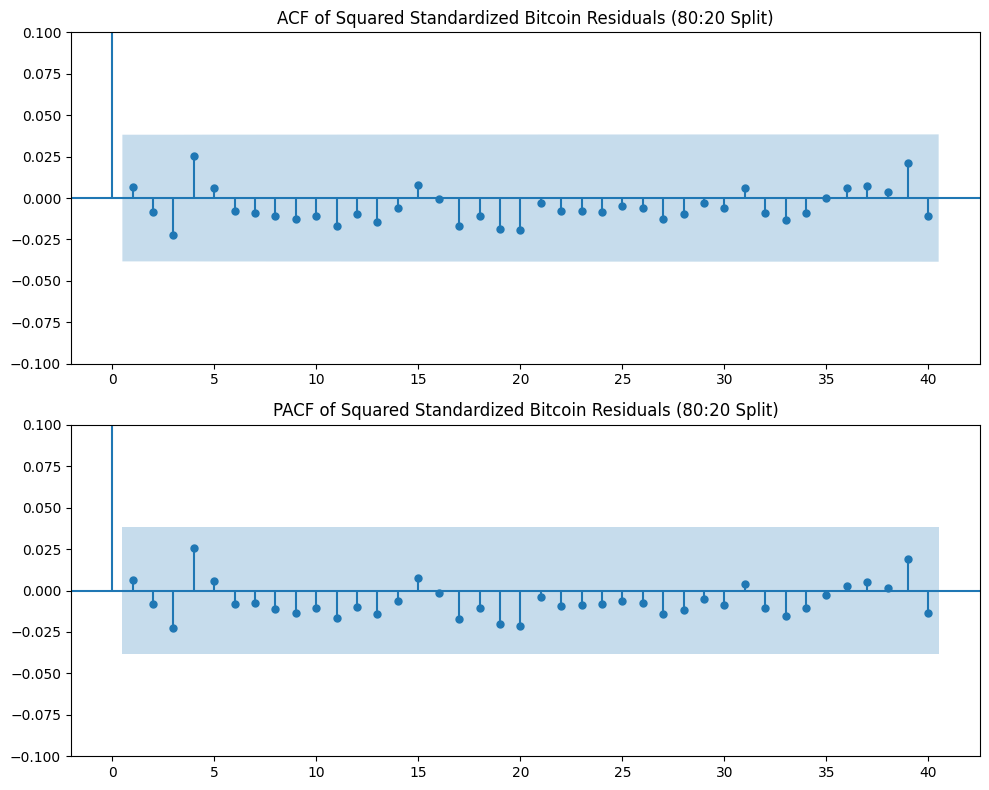

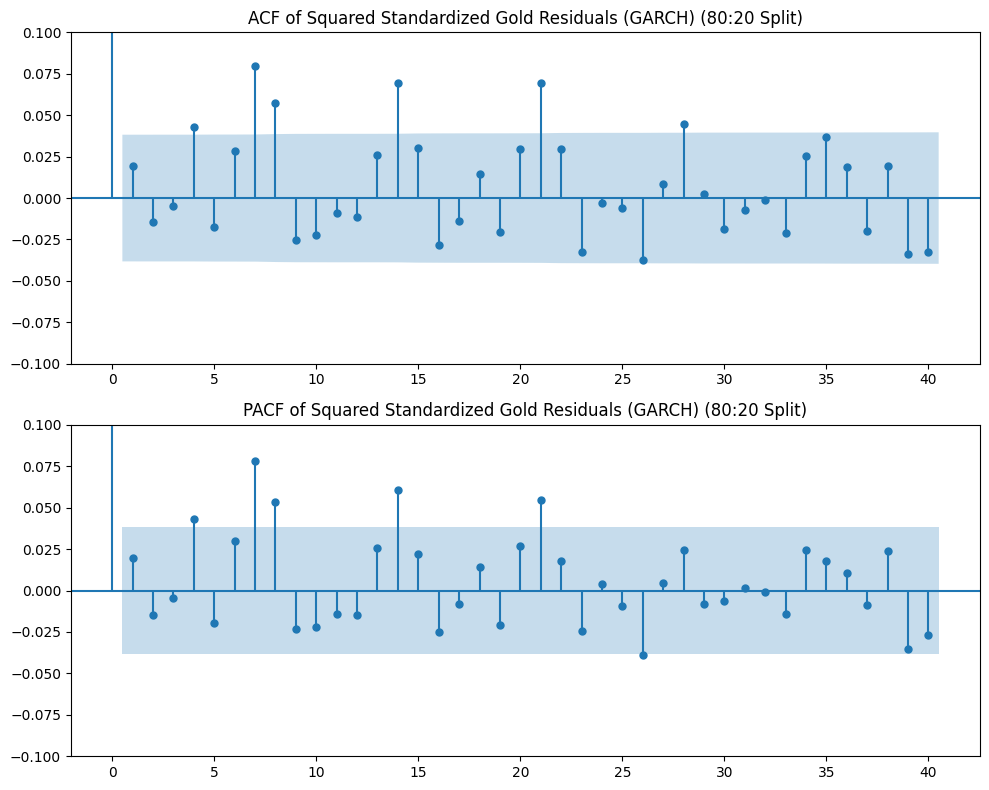

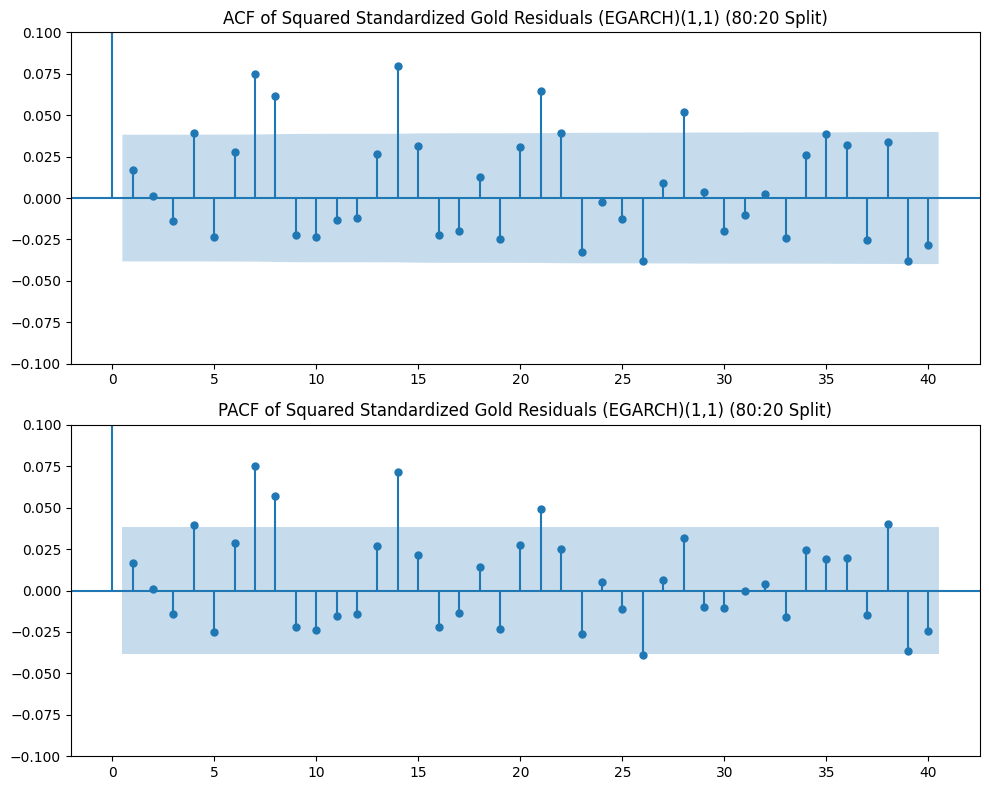

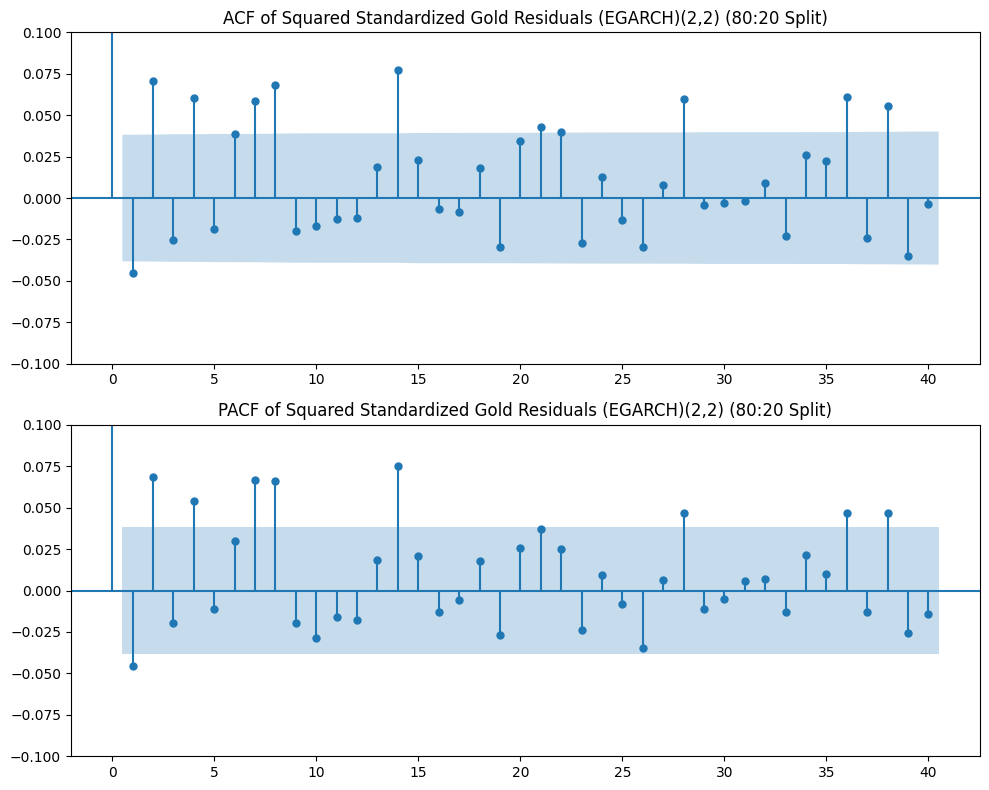

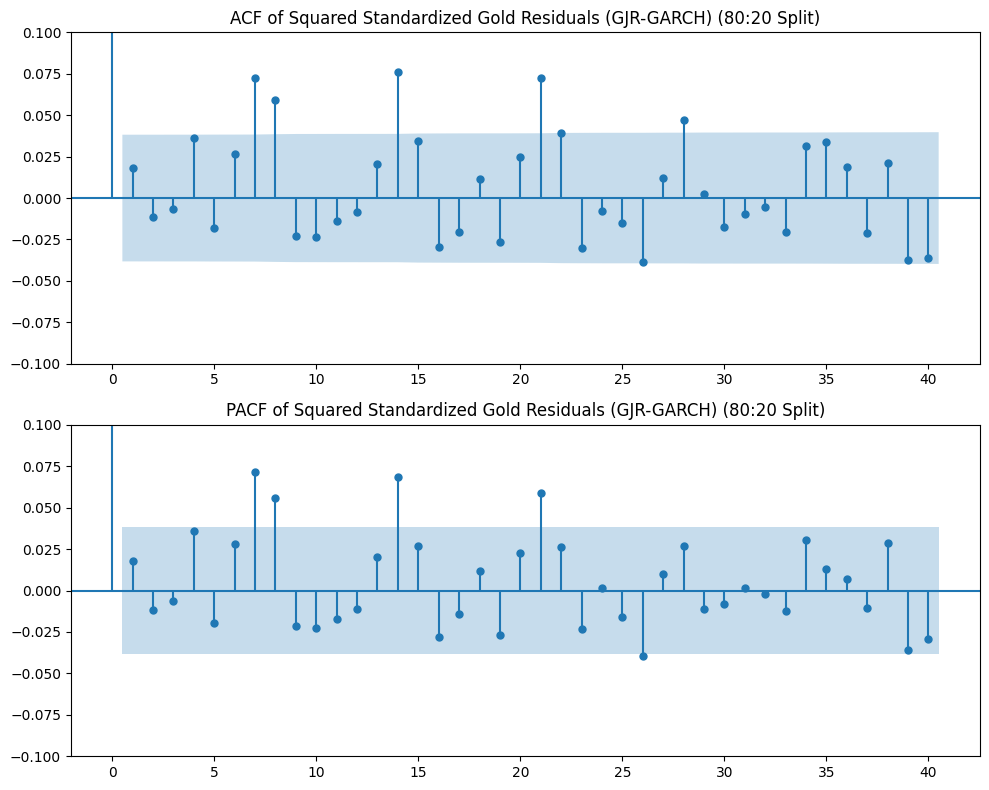

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

# --- 1. Get the standardized residuals (80:20) ---
# ⭐ FIX: Use the _80 model results
btc_std_resid_80 = res_garch_btc_80.std_resid
gold_std_resid_80 = res_garch_gold_80.std_resid

# --- 2. Square the standardized residuals ---
# ⭐ FIX: Renamed variables
btc_std_resid_sq_80 = btc_std_resid_80**2
gold_std_resid_sq_80 = gold_std_resid_80**2

# --- 3. Plot ACF and PACF for Bitcoin (80:20) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(btc_std_resid_sq_80.dropna(), ax=axes[0], lags=40)
plot_pacf(btc_std_resid_sq_80.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Bitcoin Residuals (80:20 Split)')
axes[1].set_title('PACF of Squared Standardized Bitcoin Residuals (80:20 Split)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()

# --- 4. Plot ACF and PACF for Gold residuals (GARCH) (80:20) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq_80.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq_80.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (GARCH) (80:20 Split)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (GARCH) (80:20 Split)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()

# --- 5. Get standardized residuals for other Gold models (80:20) ---
# ⭐ FIX: Use the _80 model results
gold_std_resid_egarch1_80 = res_egarch_gold1_80.std_resid
gold_std_resid_egarch2_80 = res_egarch_gold2_80.std_resid
gold_std_resid_gjr_garch_80 = res_gjr_garch_gold_80.std_resid

# --- 6. Square the standardized residuals ---
# ⭐ FIX: Renamed variables
gold_std_resid_sq_egarch1_80 = gold_std_resid_egarch1_80**2
gold_std_resid_sq_egarch2_80 = gold_std_resid_egarch2_80**2
gold_std_resid_sq_gjr_garch_80 = gold_std_resid_gjr_garch_80**2

# --- 7. Plot ACF and PACF for Gold residuals (EGARCH)(1,1) (80:20) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq_egarch1_80.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq_egarch1_80.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (EGARCH)(1,1) (80:20 Split)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (EGARCH)(1,1) (80:20 Split)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()

# --- 8. Plot ACF and PACF for Gold residuals (EGARCH)(2,2) (80:20) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq_egarch2_80.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq_egarch2_80.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (EGARCH)(2,2) (80:20 Split)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (EGARCH)(2,2) (80:20 Split)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()

# --- 9. Plot ACF and PACF for Gold residuals (GJR-GARCH) (80:20) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq_gjr_garch_80.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq_gjr_garch_80.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (GJR-GARCH) (80:20 Split)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (GJR-GARCH) (80:20 Split)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.stattools import jarque_bera

# --- Perform Jarque-Bera test on 80:20 standardized Bitcoin residuals ---
# ⭐ FIX: Use the _80 variable
jb_btc_80 = jarque_bera(btc_std_resid_80.dropna())

# ⭐ FIX: Updated title
print("--- Jarque-Bera Test: Standardized Bitcoin Residuals (80:20 Split) ---")
print(f"JB Statistic: {jb_btc_80[0]:.6f}")
print(f"p-value : {jb_btc_80[1]:.6f}")
print(f"Skewness : {jb_btc_80[2]:.6f}")
print(f"Kurtosis : {jb_btc_80[3]:.6f}")
print("→ Normal Distribution ✅" if jb_btc_80[1] > 0.05 else "→ Non-normal Distribution ❌")

# --- Perform Jarque-Bera test on 80:20 standardized Gold residuals ---
# ⭐ FIX: Use the _80 variable
jb_gold_80 = jarque_bera(gold_std_resid_80.dropna())

# ⭐ FIX: Updated title
print("\n--- Jarque-Bera Test: Standardized Gold Residuals (80:20 Split) ---")
print(f"JB Statistic: {jb_gold_80[0]:.6f}")
print(f"p-value : {jb_gold_80[1]:.6f}")
print(f"Skewness : {jb_gold_80[2]:.6f}")
print(f"Kurtosis : {jb_gold_80[3]:.6f}")
print("→ Normal Distribution ✅" if jb_gold_80[1] > 0.05 else "→ Non-normal Distribution ❌")

--- Jarque-Bera Test: Standardized Bitcoin Residuals (80:20 Split) ---
JB Statistic: 25901.318549
p-value : 0.000000
Skewness : -0.790129
Kurtosis : 18.295572
→ Non-normal Distribution ❌

--- Jarque-Bera Test: Standardized Gold Residuals (80:20 Split) ---
JB Statistic: 3349.292203
p-value : 0.000000
Skewness : -0.233861
Kurtosis : 8.509695
→ Non-normal Distribution ❌


In [ ]:
# --- 1. Set the forecast horizon (80:20) ---
# ⭐ FIX: Use the _80 test data length
horizon_len_80 = len(test_data_80)

# --- 2. Run the simulations for Bitcoin (80:20) ---
# ⭐ FIX: Use the _80 GARCH model
fc_btc_80 = res_garch_btc_80.forecast(horizon=horizon_len_80, method='simulation', simulations=1000)

# --- 3. Get the *average* variance across all 1000 simulations ---
# ⭐ CRITICAL FIX: Use axis=0 to average the simulations
btc_volatility_forecast_80 = fc_btc_80.variance.mean(axis=0)

# --- 4. Rescale ---
btc_volatility_forecast_80 = btc_volatility_forecast_80 * (1/100)**2

# ⭐ FIX: Updated title
print("Bitcoin Volatility Forecast (GARCH) (80:20 Split):")
display(btc_volatility_forecast_80)

Bitcoin Volatility Forecast (GARCH) (80:20 Split):


,0
h.001,0.001973
h.002,0.002008
h.003,0.002008
h.004,0.002024
h.005,0.001998
...,...
h.654,0.002484
h.655,0.002721
h.656,0.002617
h.657,0.002496


In [ ]:
# --- 1. Set the forecast horizon (80:20) ---
# (This variable should already exist from the block above)
# horizon_len_80 = len(test_data_80)

# --- 2. Run the simulations for Gold (80:20) ---
# ⭐ FIX: Use the _80 GJR-GARCH model
fc_gold_gjr_80 = res_gjr_garch_gold_80.forecast(horizon=horizon_len_80, method='simulation', simulations=1000)

# --- 3. Get the *average* variance across all 1000 simulations ---
# ⭐ CRITICAL FIX: Use axis=0 to average the simulations
gold_vol_forecast_gjr_80 = fc_gold_gjr_80.variance.mean(axis=0)

# --- 4. Rescale ---
gold_vol_forecast_gjr_80 = gold_vol_forecast_gjr_80 * (1/100)**2

# ⭐ FIX: Updated title
print("\nGold Volatility Forecast (GJR-GARCH) (80:20 Split):")
display(gold_vol_forecast_gjr_80)


Gold Volatility Forecast (GJR-GARCH) (80:20 Split):


,0
h.001,0.000131
h.002,0.000130
h.003,0.000130
h.004,0.000130
h.005,0.000130
...,...
h.654,0.000158
h.655,0.000159
h.656,0.000157
h.657,0.000158


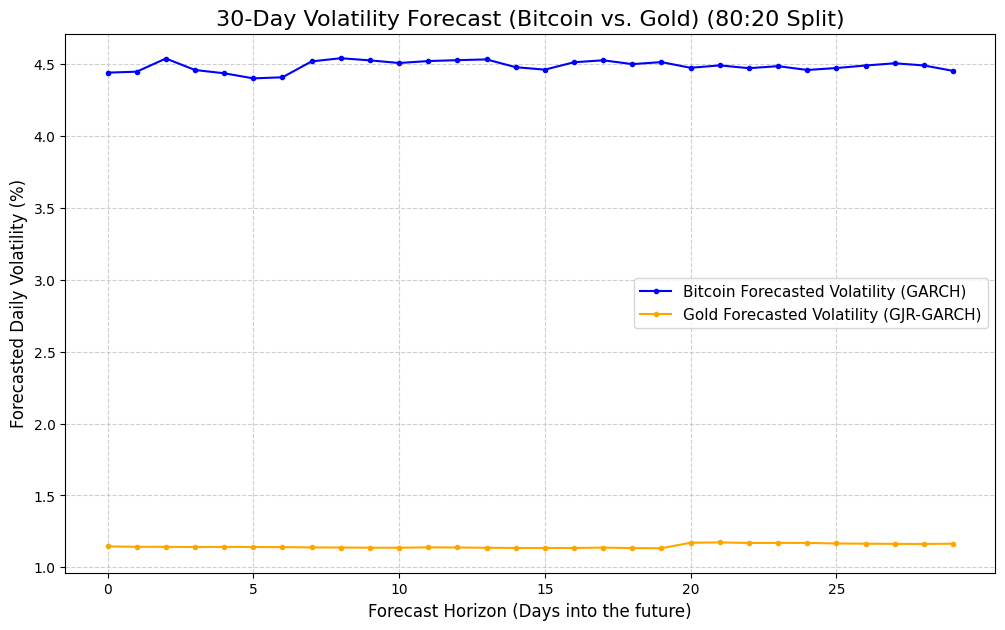

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SET FORECAST HORIZON (80:20) ---
# ⭐ FIX: Use the _80 test data
horizon_len_80 = len(test_data_80)

# --- 2. RUN BITCOIN FORECAST (GARCH 80:20) ---
# ⭐ FIX: Use the _80 GARCH model
fc_btc_80 = res_garch_btc_80.forecast(horizon=horizon_len_80, method='simulation', simulations=1000)
btc_vol_forecast_series_80 = fc_btc_80.variance.mean(axis=0)

# --- 3. RUN GOLD FORECAST (GJR-GARCH 80:20) ---
# ⭐ FIX: Use the _80 GJR-GARCH model
fc_gold_gjr_80 = res_gjr_garch_gold_80.forecast(horizon=horizon_len_80, method='simulation', simulations=1000)
gold_vol_forecast_series_80 = fc_gold_gjr_80.variance.mean(axis=0)

# --- 4. RESCALE AND CONVERT TO % VOLATILITY ---
# Rescale the variance from (return*100)^2 back to return^2
btc_variance_rescaled_80 = btc_vol_forecast_series_80 * (1/100)**2
gold_variance_rescaled_80 = gold_vol_forecast_series_80 * (1/100)**2

# Convert variance to % volatility (sqrt * 100)
btc_vol_pct_80 = np.sqrt(btc_variance_rescaled_80) * 100
gold_vol_pct_80 = np.sqrt(gold_variance_rescaled_80) * 100

# --- 5. CREATE THE FINAL 30-DAY PLOT (80:20) ---
days_to_plot = 30

plt.figure(figsize=(12, 7))

# Plot the first 30 days
# ⭐ FIX: Use the _80 volatility data
plt.plot(btc_vol_pct_80.values[:days_to_plot], label='Bitcoin Forecasted Volatility (GARCH)', color='blue', marker='.')
plt.plot(gold_vol_pct_80.values[:days_to_plot], label='Gold Forecasted Volatility (GJR-GARCH)', color='orange', marker='.')

# Add Labels and Title
# ⭐ FIX: Updated title
plt.title('30-Day Volatility Forecast (Bitcoin vs. Gold) (80:20 Split)', fontsize=16)
plt.xlabel('Forecast Horizon (Days into the future)', fontsize=12)
plt.ylabel('Forecasted Daily Volatility (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(0, days_to_plot, 5)) # Make the x-axis labels cleaner

plt.show()

In [ ]:
import pandas as pd

# Set the number of days you want to display
days_to_display = 30

# --- Display the first 30 data points (80:20 Split) ---

print("--- Bitcoin Forecasted Daily Volatility (%) [First 30 Days] (80:20 Split) ---")
# ⭐ FIX: Use the _80 variable
display(pd.DataFrame(btc_vol_pct_80.iloc[:days_to_display], columns=['Forecasted Volatility (%)']))

print("\n--- Gold Forecasted Daily Volatility (%) [First 30 Days] (80:20 Split) ---")
# ⭐ FIX: Use the _80 variable
display(pd.DataFrame(gold_vol_pct_80.iloc[:days_to_display], columns=['Forecasted Volatility (%)']))

--- Bitcoin Forecasted Daily Volatility (%) [First 30 Days] (80:20 Split) ---


,Forecasted Volatility (%)
h.001,4.441532
h.002,4.448196
h.003,4.539851
h.004,4.459818
h.005,4.437134
h.006,4.401626
h.007,4.409245
h.008,4.519798
h.009,4.541846
h.010,4.526882



--- Gold Forecasted Daily Volatility (%) [First 30 Days] (80:20 Split) ---


,Forecasted Volatility (%)
h.001,1.145811
h.002,1.142911
h.003,1.142840
h.004,1.141537
h.005,1.142251
h.006,1.141463
h.007,1.140940
h.008,1.138802
h.009,1.138050
h.010,1.136874


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# --- 1. SET PARAMETERS ---
# ⭐ FIX: Renamed variable
data_to_use_80 = merged['Bitcoin_logret'].values.reshape(-1, 1)
window_size = 30 # window_size can stay the same

# --- 2. SCALE THE DATA ---
# ⭐ FIX: Renamed variables
scaler_80 = MinMaxScaler(feature_range=(0, 1))
scaled_data_80 = scaler_80.fit_transform(data_to_use_80)

# --- 3. CREATE SEQUENCES (X, y) ---
X = []
y = []

# ⭐ FIX: Corrected indentation
for i in range(window_size, len(scaled_data_80)):
    X.append(scaled_data_80[i-window_size:i, 0])
    y.append(scaled_data_80[i, 0])

X, y = np.array(X), np.array(y)

# --- 4. SPLIT INTO TRAINING (80%) AND TESTING (20%) ---
# ⭐ FIX: Changed to 0.80 and renamed variables
train_size_80 = int(len(X) * 0.80)
test_size_80 = len(X) - train_size_80

X_tr_80, X_test_80 = X[0:train_size_80], X[train_size_80:len(X)]
y_tr_80, y_test_80 = y[0:train_size_80], y[train_size_80:len(y)]

# --- 5. RESHAPE FOR LSTM [samples, timesteps, features] ---
# ⭐ FIX: Renamed variables
X_tr_80 = np.reshape(X_tr_80, (X_tr_80.shape[0], window_size, 1))
X_test_80 = np.reshape(X_test_80, (X_test_80.shape[0], window_size, 1))

# --- 6. PRINT SHAPES TO CONFIRM ---
# ⭐ FIX: Updated print statements
print("--- Data Preparation Complete (80:20 Split) ---")
print(f"Window size (timesteps): {window_size}")
print(f"X_train shape: {X_tr_80.shape}")
print(f"y_train shape: {y_tr_80.shape}")
print(f"X_test shape: {X_test_80.shape}")
print(f"y_test shape: {y_test_80.shape}")

--- Data Preparation Complete (80:20 Split) ---
Window size (timesteps): 30
X_train shape: (2605, 30, 1)
y_train shape: (2605,)
X_test shape: (652, 30, 1)
y_test shape: (652,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping # Import EarlyStopping

# --- 1. BUILD THE LSTM MODEL (80:20) ---
# ⭐ FIX: Renamed model
model_80 = Sequential()

# Layer 1: LSTM layer
# ⭐ FIX: Use window_size (which was 30) for the input shape
model_80.add(LSTM(units=50, return_sequences=True, input_shape=(window_size, 1)))
model_80.add(Dropout(0.2)) # Dropout helps prevent overfitting

# Layer 2: Another LSTM layer
model_80.add(LSTM(units=50, return_sequences=False)) # False because it's the last LSTM layer
model_80.add(Dropout(0.2))

# Layer 3: The Output Layer
model_80.add(Dense(units=1))

# --- 2. COMPILE THE MODEL ---
model_80.compile(optimizer='adam', loss='mean_squared_error')

# --- 3. TRAIN THE MODEL ("fit" the data) ---
# ⭐ FIX: Add EarlyStopping for better training
es_80 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# ⭐ FIX: Updated title
print("\n--- Starting Model Training (80:20 Split) ---")

# ⭐ FIX: Use all _80 variables
history_80 = model_80.fit(
    X_tr_80,
    y_tr_80,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_80, y_test_80), # Use the 80:20 test set
    callbacks=[es_80], # Add the callback
    verbose=1
)

print("--- Model Training Complete ---")

# --- 4. DISPLAY THE MODEL STRUCTURE ---
model_80.summary()


--- Starting Model Training (80:20 Split) ---
Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - loss: 0.0715 - val_loss: 0.0012
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0078 - val_loss: 0.0014
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0069 - val_loss: 0.0025
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0069 - val_loss: 0.0012
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0067 - val_loss: 0.0015
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0063 - val_loss: 0.0013
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - loss: 0.0059 - val_loss: 0.0016
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0057 - val_loss: 0.0013
Epoch 9/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0057 - val_loss: 0.0015
--- Model Training Complete ---


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
Test RMSE (80:20 Split): 0.025061


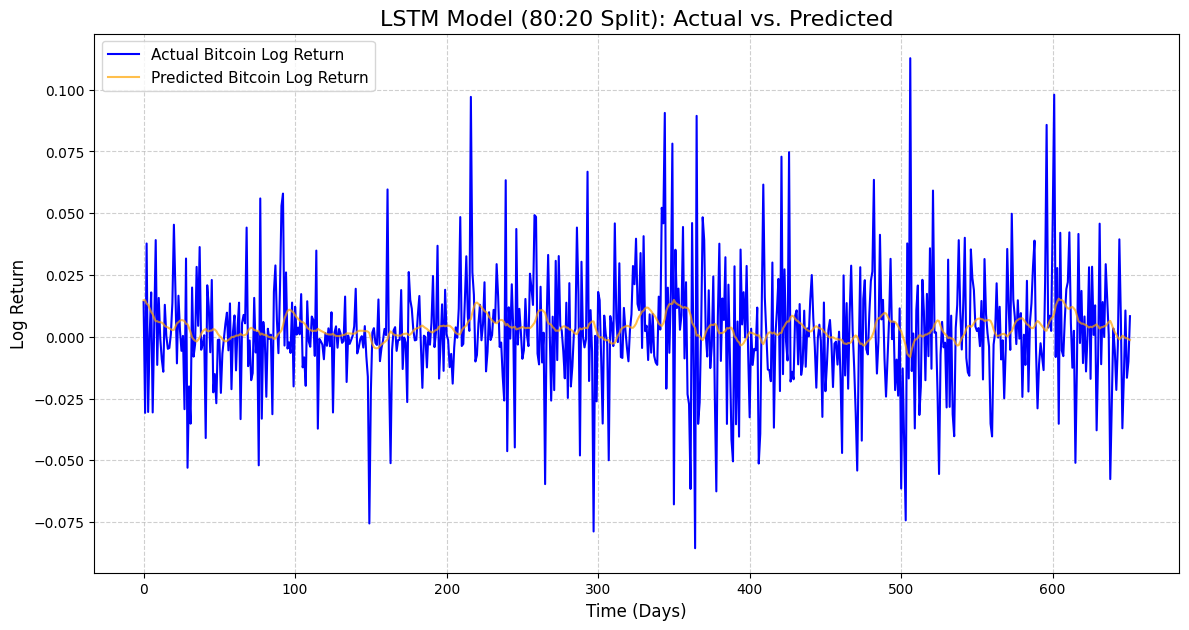

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# --- 1. MAKE PREDICTIONS ---
# ⭐ FIX: Use your new 80:20 model and test set
predicted_scaled_80 = model_80.predict(X_test_80)

# --- 2. UN-SCALE THE DATA ---
# ⭐ FIX: Use your new scaler_80 object

# Un-scale the predictions
predictions_80 = scaler_80.inverse_transform(predicted_scaled_80)

# Un-scale the *actual* values so we can compare
# ⭐ FIX: Use scaler_80 and y_test_80
actual_values_80 = scaler_80.inverse_transform(y_test_80.reshape(-1, 1))

# --- 3. CALCULATE ERROR (RMSE) ---
# ⭐ FIX: Use the new 80:20 variables
rmse_80 = np.sqrt(mean_squared_error(actual_values_80, predictions_80))
print(f'Test RMSE (80:20 Split): {rmse_80:.6f}')

# --- 4. PLOT THE RESULTS ---
# This is the most important visual.
plt.figure(figsize=(14, 7))
# ⭐ FIX: Use the new 80:20 variables
plt.plot(actual_values_80, color='blue', label='Actual Bitcoin Log Return')
plt.plot(predictions_80, color='orange', label='Predicted Bitcoin Log Return', alpha=0.7)
# ⭐ FIX: Updated title
plt.title('LSTM Model (80:20 Split): Actual vs. Predicted', fontsize=16)
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Log Return', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━

,Forecasted Log Return
Day,
1,-0.001186
2,-0.000982
3,-0.000740
4,-0.000479
5,-0.000197
6,0.000078
7,0.000357
8,0.000627
9,0.000897


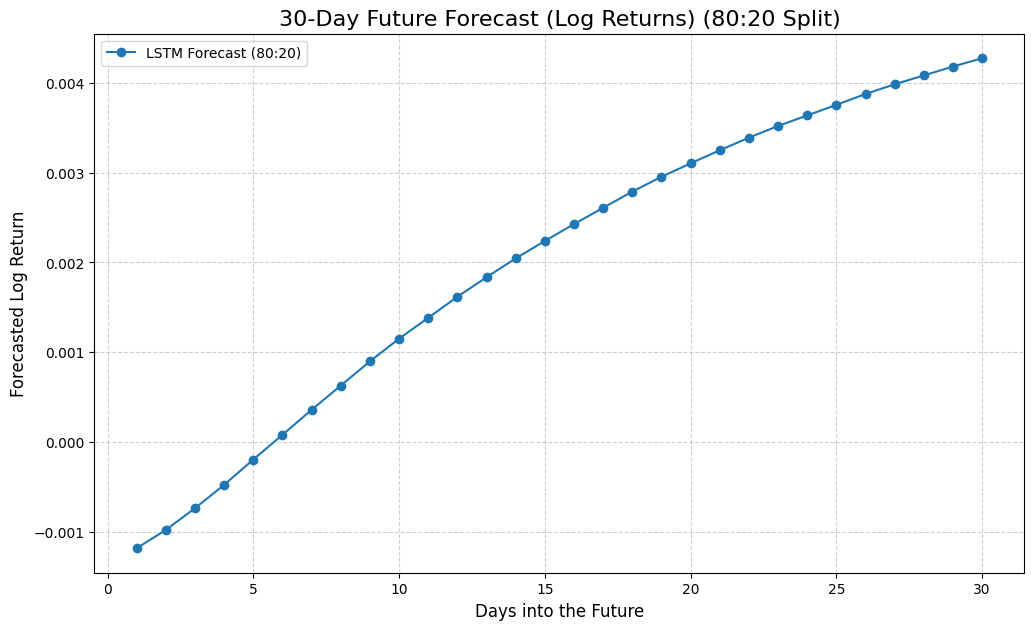

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. SET FORECAST PARAMETERS ---
n_future_days_80 = 30
# ⭐ FIX: Make sure window_size is defined (it was 30)
window_size_80 = 30

# --- 2. GET THE LAST WINDOW OF REAL DATA (from 80:20 scaled data) ---
# ⭐ FIX: Use scaled_data_80
last_real_window_80 = scaled_data_80[-window_size_80:]

# Reshape it to be the input for the model
current_window_80 = last_real_window_80.reshape(1, window_size_80, 1)

# --- 3. ITERATIVE FORECASTING (Predict 30 days) ---
future_predictions_scaled_80 = [] # Store the scaled predictions

for i in range(n_future_days_80):
    # 1. Predict the next day
    # ⭐ FIX: Use model_80
    next_pred_scaled_80 = model_80.predict(current_window_80)[0, 0]

    # 2. Store the prediction
    future_predictions_scaled_80.append(next_pred_scaled_80)

    # 3. Update the window for the next loop
    next_pred_reshaped_80 = np.array([[next_pred_scaled_80]])

    # Remove the *first* day and add the *new prediction* to the end
    current_window_80 = np.append(current_window_80[:, 1:, :], next_pred_reshaped_80.reshape(1, 1, 1), axis=1)

# --- 4. UN-SCALE THE FINAL FORECAST ---
# ⭐ FIX: Use scaler_80
future_predictions_80 = scaler_80.inverse_transform(np.array(future_predictions_scaled_80).reshape(-1, 1))

# --- 5. DISPLAY THE 30-DAY DATA (80:20 Split) ---
print(f"--- LSTM 30-Day Future Forecast (Log Returns) (80:20 Split) ---")

# Create a nice DataFrame to display
# ⭐ FIX: Renamed variables
forecast_df_80 = pd.DataFrame(future_predictions_80,
                           columns=['Forecasted Log Return'],
                           index=np.arange(1, n_future_days_80 + 1))
forecast_df_80.index.name = 'Day'
display(forecast_df_80)

# --- 6. PLOT THE 30-DAY FORECAST ---
plt.figure(figsize=(12, 7))
# ⭐ FIX: Use the _80 dataframe
plt.plot(forecast_df_80.index, forecast_df_80['Forecasted Log Return'], marker='o', label='LSTM Forecast (80:20)')
# ⭐ FIX: Updated title
plt.title('30-Day Future Forecast (Log Returns) (80:20 Split)', fontsize=16)
plt.xlabel('Days into the Future', fontsize=12)
plt.ylabel('Forecasted Log Return', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- Data Shapes (80:20 Split) ---
X_train: (2605, 30, 1)
X_test: (652, 30, 1)

--- Starting Model Training (80:20 Split) ---
Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - loss: 0.0058 - val_loss: 0.0017
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 8.8216e-04 - val_loss: 0.0034
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 8.3193e-04 - val_loss: 0.0018
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 7.3862e-04 - val_loss: 0.0015
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 7.0209e-04 - val_loss: 0.0013
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 6.1972e-04 - val_loss: 0.0011
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 5.7967e-04 - val_loss: 0.0024
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 5.5932e-04 - val_loss: 0.0030
Epoch 9/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 5.3006e-04 - val_loss: 8.9044e-04
Epoch 10/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 6.4133e-04 - 

,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,1009.35,2483850.21,1576.02,20.40
1,Test,2115.94,9961776.26,3156.23,3.72


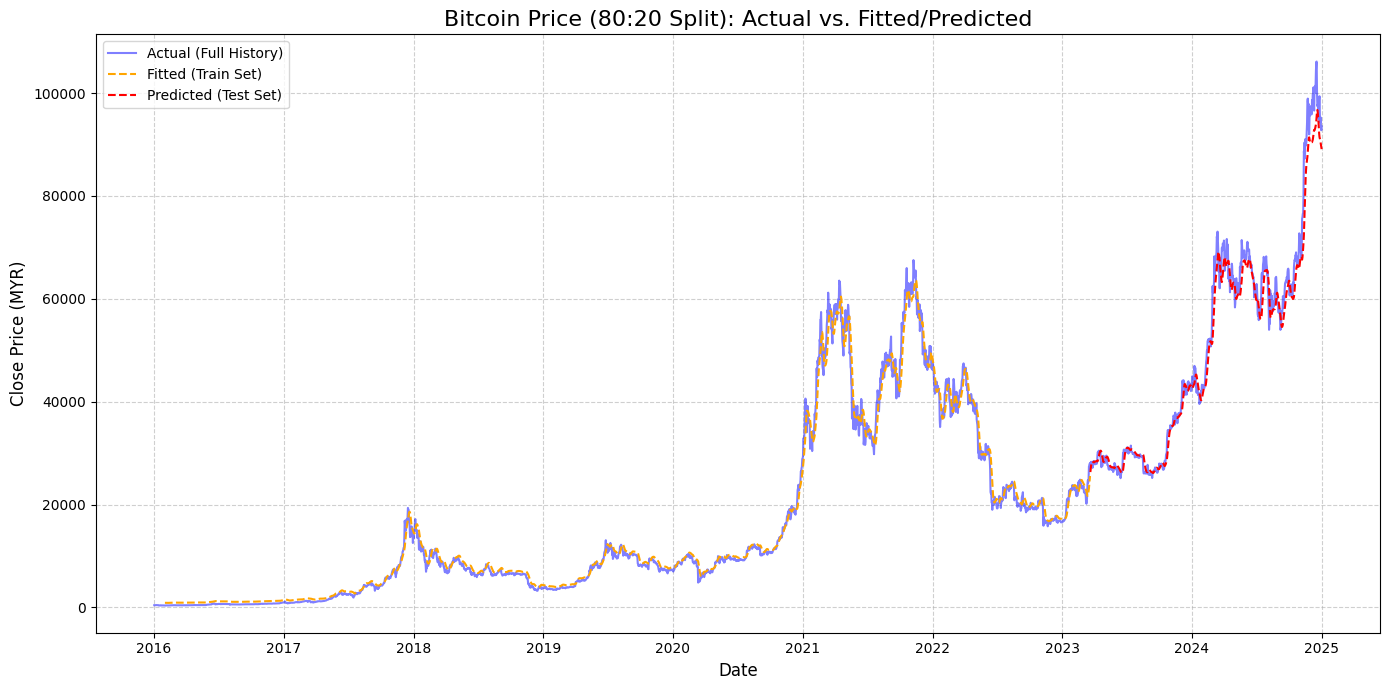

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. SET UP DATA & PARAMETERS ---
# Assuming 'merged_df' is loaded from your data prep step
df_80 = merged.copy() # Renamed
close_col_80 = 'Bitcoin' # Using raw 'Bitcoin' price
date_col_80 = 'Date'
window_size_80 = 30

# Ensure date column is datetime
df_80[date_col_80] = pd.to_datetime(df_80[date_col_80])

# --- 2. SCALING & DATA PREPARATION ---
data_to_use_80 = df_80[close_col_80].values.reshape(-1, 1) # Renamed

scaler_80 = MinMaxScaler(feature_range=(0, 1)) # Renamed
scaled_data_80 = scaler_80.fit_transform(data_to_use_80) # Renamed

# --- 3. CREATE SEQUENCES ---
def make_sequences_80(data, window_size): # Renamed
    X, y = [], []
    # ⭐ FIX: Corrected indentation
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_80, y_80 = make_sequences_80(scaled_data_80, window_size_80) # Renamed

# --- 4. TRAIN / TEST SPLIT (80% Train, 20% Test) ---
# ⭐ CHANGE: Updated to 80:20 split
train_split_idx_80 = int(len(X_80) * 0.80)

X_tr_80, y_tr_80 = X_80[:train_split_idx_80], y_80[:train_split_idx_80] # Renamed
X_test_80, y_test_80 = X_80[train_split_idx_80:], y_80[train_split_idx_80:] # Renamed

# --- 5. RESHAPE FOR LSTM [samples, timesteps, features] ---
X_tr_80 = np.reshape(X_tr_80, (X_tr_80.shape[0], X_tr_80.shape[1], 1)) # Renamed
X_test_80 = np.reshape(X_test_80, (X_test_80.shape[0], X_test_80.shape[1], 1)) # Renamed

print("--- Data Shapes (80:20 Split) ---") # Updated title
print(f"X_train: {X_tr_80.shape}") # Renamed
print(f"X_test: {X_test_80.shape}") # Renamed

# --- 6. BUILD & TRAIN MODEL (from your senior's code) ---
tf.random.set_seed(42)
model_80 = Sequential([ # Renamed
    LSTM(64, return_sequences=True, input_shape=(window_size_80, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model_80.compile(optimizer="adam", loss="mse") # Renamed

# Use EarlyStopping, monitoring the test set loss
es_80 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True) # Renamed

print("\n--- Starting Model Training (80:20 Split) ---") # Updated title
history_80 = model_80.fit( # Renamed
    X_tr_80, y_tr_80, # Renamed
    epochs=50,
    batch_size=32,
    validation_data=(X_test_80, y_test_80), # Renamed
    callbacks=[es_80], # Renamed
    verbose=1
)
print("--- Model Training Complete ---")

# --- 7. EVALUATION & METRICS ---
def inverse_and_metrics_80(y_true_scaled, y_pred_scaled, scaler_obj): # Renamed
    y_true = scaler_obj.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler_obj.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

# Get predictions (scaled)
y_pred_tr_skala_80 = model_80.predict(X_tr_80, verbose=0).flatten() # Renamed
y_pred_test_skala_80 = model_80.predict(X_test_80, verbose=0).flatten() # Renamed

# Get metrics (un-scaled)
y_true_tr_80, y_pred_tr_80, mae_tr_80, mse_tr_80, rmse_tr_80, mape_tr_80 = inverse_and_metrics_80(y_tr_80, y_pred_tr_skala_80, scaler_80) # Renamed
y_true_test_80, y_pred_test_80, mae_te_80, mse_te_80, rmse_te_80, mape_te_80 = inverse_and_metrics_80(y_test_80, y_pred_test_skala_80, scaler_80) # Renamed

# Build metrics table (Train/Test only)
metrics_df_80 = pd.DataFrame({ # Renamed
    "Set": ["Train", "Test"],
    "MAE": [mae_tr_80, mae_te_80], # Renamed
    "MSE": [mse_tr_80, mse_te_80], # Renamed
    "RMSE": [rmse_tr_80, rmse_te_80], # Renamed
    "MAPE(%)": [mape_tr_80, mape_te_80] # Renamed
})

print("\n=== Performance Metrics (80:20 Split) ===") # Updated title
display(metrics_df_80.round(2)) # Renamed

# --- 8. PLOTTING (Full History Plot) ---

# Get the correct dates for each set
date_index_80 = df_80[date_col_80].iloc[window_size_80:] # Renamed
train_dates_80 = date_index_80.iloc[:train_split_idx_80] # Renamed
test_dates_80 = date_index_80.iloc[train_split_idx_80:] # Renamed

plt.figure(figsize=(14, 7))

# Plot 1: Full History
plt.plot(df_80[date_col_80], df_80[close_col_80], label="Actual (Full History)", color='blue', alpha=0.5) # Renamed

# Plot 2: Fitted (Train Set)
plt.plot(train_dates_80, y_pred_tr_80, label="Fitted (Train Set)", color='orange', linestyle='--') # Renamed

# Plot 3: Predicted (Test Set)
plt.plot(test_dates_80, y_pred_test_80, label="Predicted (Test Set)", color='red', linestyle='--') # Renamed

plt.title(f"{close_col_80} Price (80:20 Split): Actual vs. Fitted/Predicted", fontsize=16) # Updated title
plt.xlabel("Date", fontsize=12)
plt.ylabel("Close Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


--- Data Shapes (Multivariate 80:20 Split) ---
X_train: (2605, 30, 2)
X_test: (652, 30, 2)

--- Starting Multivariate Model Training (80:20 Split) ---
Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - loss: 0.0111 - val_loss: 0.0033
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 9.4145e-04 - val_loss: 0.0020
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 9.2936e-04 - val_loss: 0.0056
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 8.1162e-04 - val_loss: 0.0022
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 7.5178e-04 - val_loss: 0.0036
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 6.7100e-04 - val_loss: 0.0026
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 7.2046e-04 - val_loss: 9.3772e-04
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 5.9271e-04 - val_loss: 0.0042
Epoch 9/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 5.9387e-04 - val_loss: 0.0050
Epoch 10/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms

,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,1274.94,3609543.02,1899.88,23.44
1,Test,2285.74,10490673.63,3238.93,4.35


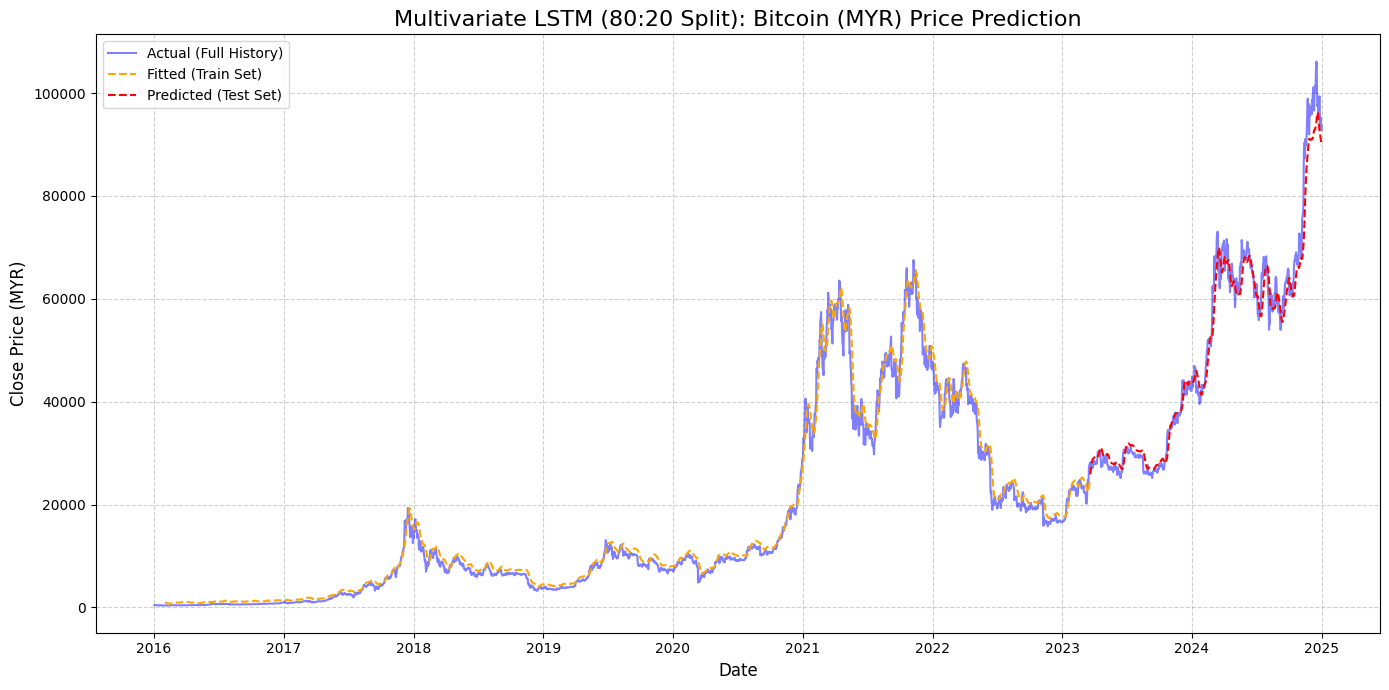

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. SET UP FOR MULTIVARIATE LSTM ---
df_80 = merged.copy() # Renamed df
feature_cols_80 = ['Bitcoin', 'Gold'] # Renamed
target_col_80 = 'Bitcoin'
date_col_80 = 'Date'
window_size_80 = 30 # Renamed

# --- 2. SCALING ---
data_to_use_80 = df_80[feature_cols_80].values # Renamed
scaler_80 = MinMaxScaler(feature_range=(0, 1)) # Renamed
scaled_data_80 = scaler_80.fit_transform(data_to_use_80) # Renamed

# --- 3. CREATE SEQUENCES (Multivariate) ---
def make_sequences_multi_80(data, window_size): # Renamed function
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :]) # All features for the window
        y.append(data[i, 0])               # Only the 1st col (Bitcoin) as target
    return np.array(X), np.array(y)

X_80, y_80 = make_sequences_multi_80(scaled_data_80, window_size_80) # Renamed

# --- 4. TRAIN / TEST SPLIT (80% Train, 20% Test) ---
# ⭐ CHANGE: Updated to 0.80 for 80:20 split
train_split_idx_80 = int(len(X_80) * 0.80)
X_tr_80, y_tr_80 = X_80[:train_split_idx_80], y_80[:train_split_idx_80] # Renamed
X_test_80, y_test_80 = X_80[train_split_idx_80:], y_80[train_split_idx_80:] # Renamed

# --- 5. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features_80 = len(feature_cols_80) # Renamed
# X_tr and X_test are already (samples, 30, 2)
print("\n--- Data Shapes (Multivariate 80:20 Split) ---") # Updated title
print(f"X_train: {X_tr_80.shape}") # Renamed
print(f"X_test: {X_test_80.shape}") # Renamed

# --- 7. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model_80 = Sequential([ # Renamed model
    LSTM(64, return_sequences=True, input_shape=(window_size_80, n_features_80)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model_80.compile(optimizer="adam", loss="mse")
es_80 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True) # Renamed

print("\n--- Starting Multivariate Model Training (80:20 Split) ---") # Updated title
history_80 = model_80.fit( # Renamed
    X_tr_80, y_tr_80, # Renamed
    epochs=50,
    batch_size=32,
    validation_data=(X_test_80, y_test_80), # Renamed
    callbacks=[es_80], # Renamed
    verbose=1
)
print("--- Model Training Complete ---")

# --- 8. EVALUATION & METRICS (Multivariate) ---
def inverse_and_metrics_multi_80(y_true_scaled, y_pred_scaled, scaler_obj): # Renamed function
    n_features = scaler_obj.n_features_in_

    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 0] = y_pred_scaled.flatten()
    y_pred = scaler_obj.inverse_transform(pred_combined)[:, 0]

    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 0] = y_true_scaled.flatten()
    y_true = scaler_obj.inverse_transform(true_combined)[:, 0]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala_80 = model_80.predict(X_tr_80, verbose=0).flatten() # Renamed
y_pred_test_skala_80 = model_80.predict(X_test_80, verbose=0).flatten() # Renamed

y_true_tr_80, y_pred_tr_80, mae_tr_80, mse_tr_80, rmse_tr_80, mape_tr_80 = inverse_and_metrics_multi_80(y_tr_80, y_pred_tr_skala_80, scaler_80) # Renamed
y_true_test_80, y_pred_test_80, mae_te_80, mse_te_80, rmse_te_80, mape_te_80 = inverse_and_metrics_multi_80(y_test_80, y_pred_test_skala_80, scaler_80) # Renamed

metrics_df_80 = pd.DataFrame({ # Renamed
    "Set": ["Train", "Test"],
    "MAE": [mae_tr_80, mae_te_80],
    "MSE": [mse_tr_80, mse_te_80],
    "RMSE": [rmse_tr_80, rmse_te_80],
    "MAPE(%)": [mape_tr_80, mape_te_80]
})

print("\n=== Ringkasan Metrik (Multivariate 80:20 Split) ===") # Updated title
display(metrics_df_80.round(2))

# --- 9. PLOTTING (Full History Plot) ---
date_index_80 = df_80[date_col_80].iloc[window_size_80:] # Renamed
train_dates_80 = date_index_80.iloc[:train_split_idx_80] # Renamed
test_dates_80 = date_index_80.iloc[train_split_idx_80:] # Renamed

plt.figure(figsize=(14, 7))
plt.plot(df_80[date_col_80], df_80[target_col_80], label="Actual (Full History)", color='blue', alpha=0.5) # Renamed
plt.plot(train_dates_80, y_pred_tr_80, label="Fitted (Train Set)", color='orange', linestyle='--') # Renamed
plt.plot(test_dates_80, y_pred_test_80, label="Predicted (Test Set)", color='red', linestyle='--') # Renamed
plt.title(f"Multivariate LSTM (80:20 Split): Bitcoin (MYR) Price Prediction", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Close Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


--- Data Shapes (Multivariate Gold 80:20 Split) ---
X_train: (2606, 30, 2)
X_test:  (652, 30, 2)

--- Starting Multivariate Model Training (Predicting Gold) (80:20 Split) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 0.0125 - val_loss: 0.0065
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0012 - val_loss: 0.0031
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0011 - val_loss: 0.0020
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 9.1630e-04 - val_loss: 0.0040
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 9.6022e-04 - val_loss: 0.0023
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 8.9015e-04 - val_loss: 0.0077
--- Model Training Complete ---

=== Ringkasan Metrik (Multivariate Gold 80:20 Split) ===


,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,118.66,22438.24,149.79,1.84
1,Test,207.47,73466.88,271.05,1.98


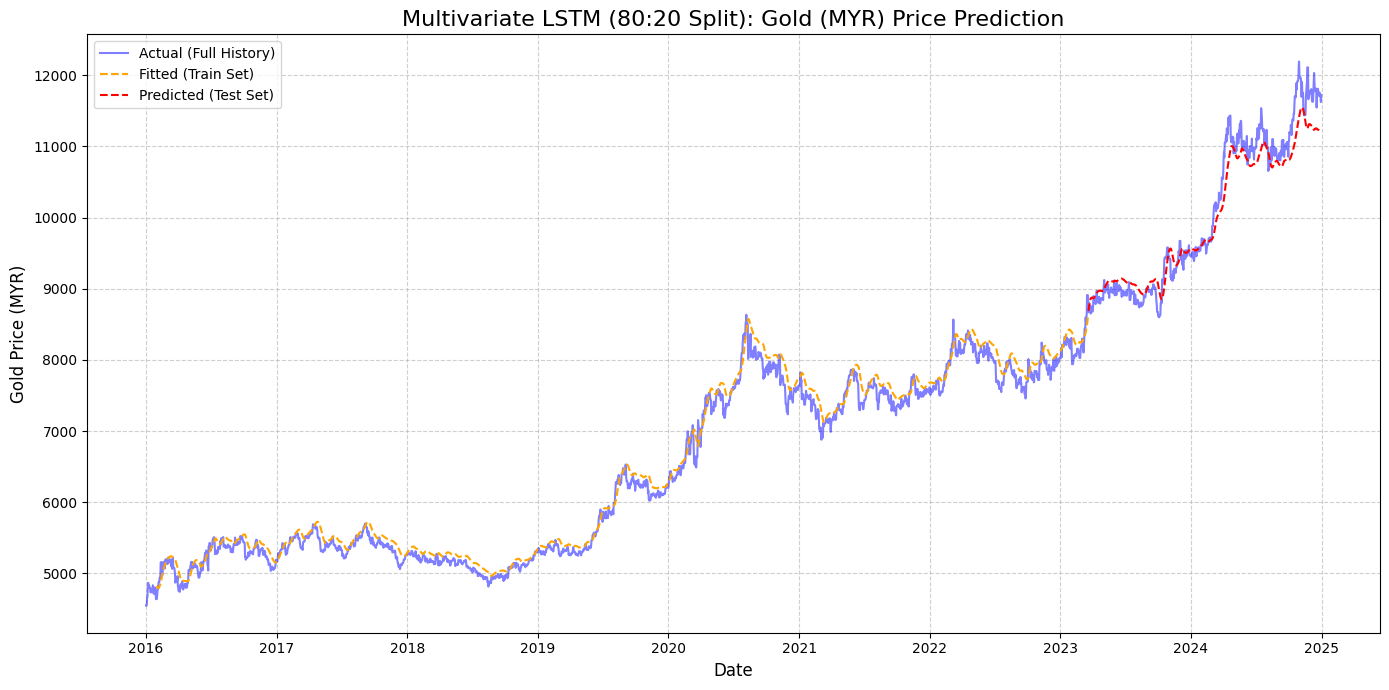

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# --- 3. SET UP FOR MULTIVARIATE LSTM (Predicting Gold) ---
df_gold_80 = merged.copy() # Renamed df
feature_cols_gold_80 = ['Bitcoin', 'Gold']
target_col_gold_80 = 'Gold'
date_col_gold_80 = 'Date'
window_size_gold_80 = 30

# --- 4. SCALING ---
data_to_use_gold_80 = df_gold_80[feature_cols_gold_80].values
scaler_gold_80 = MinMaxScaler(feature_range=(0, 1)) # Renamed scaler
scaled_data_gold_80 = scaler_gold_80.fit_transform(data_to_use_gold_80)

# --- 5. CREATE SEQUENCES (Multivariate for Gold) ---
def make_sequences_multi_gold_80(data, window_size): # Renamed function
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :]) # All features (BTC & Gold)
        y.append(data[i, 1])               # Target is col 1 (Gold)
    return np.array(X), np.array(y)

X_gold_80, y_gold_80 = make_sequences_multi_gold_80(scaled_data_gold_80, window_size_gold_80) # Renamed

# --- 6. TRAIN / TEST SPLIT (80% Train, 20% Test) ---
# ⭐ CHANGE: Updated to 0.80 for 80:20 split
train_split_idx_gold_80 = int(len(X_gold_80) * 0.80)
X_tr_gold_80, y_tr_gold_80 = X_gold_80[:train_split_idx_gold_80], y_gold_80[:train_split_idx_gold_80] # Renamed
X_test_gold_80, y_test_gold_80 = X_gold_80[train_split_idx_gold_80:], y_gold_80[train_split_idx_gold_80:] # Renamed

# --- 7. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features_gold_80 = len(feature_cols_gold_80)
print("\n--- Data Shapes (Multivariate Gold 80:20 Split) ---") # Updated title
print(f"X_train: {X_tr_gold_80.shape}") # Renamed
print(f"X_test:  {X_test_gold_80.shape}") # Renamed

# --- 8. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model_gold_80 = Sequential([ # Renamed model
    LSTM(64, return_sequences=True, input_shape=(window_size_gold_80, n_features_gold_80)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model_gold_80.compile(optimizer="adam", loss="mse")
es_gold_80 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True) # Renamed

print("\n--- Starting Multivariate Model Training (Predicting Gold) (80:20 Split) ---") # Updated title
history_gold_80 = model_gold_80.fit( # Renamed
    X_tr_gold_80, y_tr_gold_80, # Renamed
    epochs=50,
    batch_size=32,
    validation_data=(X_test_gold_80, y_test_gold_80), # Renamed
    callbacks=[es_gold_80], # Renamed
    verbose=1
)
print("--- Model Training Complete ---")

# --- 9. EVALUATION & METRICS (Multivariate for Gold) ---
def inverse_and_metrics_multi_gold_80(y_true_scaled, y_pred_scaled, scaler_obj_gold_80): # Renamed function
    n_features = scaler_obj_gold_80.n_features_in_

    # Put prediction in col 1 (Gold)
    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 1] = y_pred_scaled.flatten()
    y_pred = scaler_obj_gold_80.inverse_transform(pred_combined)[:, 1]

    # Put actual in col 1 (Gold)
    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 1] = y_true_scaled.flatten()
    y_true = scaler_obj_gold_80.inverse_transform(true_combined)[:, 1]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala_gold_80 = model_gold_80.predict(X_tr_gold_80, verbose=0).flatten() # Renamed
y_pred_test_skala_gold_80 = model_gold_80.predict(X_test_gold_80, verbose=0).flatten() # Renamed

y_true_tr_gold_80, y_pred_tr_gold_80, mae_tr_gold_80, mse_tr_gold_80, rmse_tr_gold_80, mape_tr_gold_80 = inverse_and_metrics_multi_gold_80(y_tr_gold_80, y_pred_tr_skala_gold_80, scaler_gold_80) # Renamed
y_true_test_gold_80, y_pred_test_gold_80, mae_te_gold_80, mse_te_gold_80, rmse_te_gold_80, mape_te_gold_80 = inverse_and_metrics_multi_gold_80(y_test_gold_80, y_pred_test_skala_gold_80, scaler_gold_80) # Renamed

metrics_df_gold_80 = pd.DataFrame({ # Renamed
    "Set": ["Train", "Test"],
    "MAE": [mae_tr_gold_80, mae_te_gold_80],
    "MSE": [mse_tr_gold_80, mse_te_gold_80],
    "RMSE": [rmse_tr_gold_80, rmse_te_gold_80],
    "MAPE(%)": [mape_tr_gold_80, mape_te_gold_80]
})

print("\n=== Ringkasan Metrik (Multivariate Gold 80:20 Split) ===") # Updated title
display(metrics_df_gold_80.round(2)) # Renamed

# --- 10. PLOTTING (Full History Plot) ---
date_index_gold_80 = df_gold_80[date_col_gold_80].iloc[window_size_gold_80:] # Renamed
train_dates_gold_80 = date_index_gold_80.iloc[:train_split_idx_gold_80] # Renamed
test_dates_gold_80 = date_index_gold_80.iloc[train_split_idx_gold_80:] # Renamed

plt.figure(figsize=(14, 7))
plt.plot(df_gold_80[date_col_gold_80], df_gold_80[target_col_gold_80], label="Actual (Full History)", color='blue', alpha=0.5) # Renamed
plt.plot(train_dates_gold_80, y_pred_tr_gold_80, label="Fitted (Train Set)", color='orange', linestyle='--') # Renamed
plt.plot(test_dates_gold_80, y_pred_test_gold_80, label="Predicted (Test Set)", color='red', linestyle='--') # Renamed

plt.title(f"Multivariate LSTM (80:20 Split): Gold (MYR) Price Prediction", fontsize=16) # Updated title
plt.xlabel("Date", fontsize=12)
plt.ylabel("Gold Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()